# Avance 1 — Análisis exploratorio de datos

**Equipo 39 · Proyecto Integrador MNA**

Este notebook reúne en un solo documento el análisis de los **tres conjuntos de datos** del proyecto, uno por sección: los datos sintéticos que fabricamos (sección 1) y los dos conjuntos de datos reales del NIST, las frecuencias del Brazo 1 (sección 2) y las trazas de forma del Brazo 2 (sección 3). Al final hay una conclusión general. Está escrito para alguien que no conoce el proyecto y se puede ejecutar completo de principio a fin (*Run All*) desde el repositorio; tarda alrededor de un minuto.

**En tres frases:**
1. Queremos medir qué tan rígido es el material de una viga microscópica (su **módulo de Young, E**) a partir de cómo vibra o cómo se deforma.
2. Las fórmulas estándar suponen una viga perfecta; las reales no lo son, y los datos reales del NIST muestran el error que eso produce.
3. Para estudiar ese error combinamos datos reales, donde no conocemos el E verdadero, con datos sintéticos, donde sí lo conocemos y podemos medir cuánto se equivoca cada método.

### Contenido
- **[1. Datos sintéticos: qué son, cómo se crean y para qué sirven](#1.-Datos-sintéticos:-qué-son,-cómo-se-crean-y-para-qué-sirven)**
  - [1.1 Nombres y términos](#1.1-Nombres-y-términos)
  - [1.2 El problema](#1.2-El-problema)
  - [1.3 Qué se mide en una viga que vibra](#1.3-Qué-se-mide-en-una-viga-que-vibra)
  - [1.4 Cómo calculamos la vibración y cómo sabemos que el cálculo es correcto](#1.4-Cómo-calculamos-la-vibración-y-cómo-sabemos-que-el-cálculo-es-correcto)
  - [1.5 Los cuatro generadores: vigas perfectas e imperfectas](#1.5-Los-cuatro-generadores:-vigas-perfectas-e-imperfectas)
  - [1.6 Qué tan imperfectas: la severidad](#1.6-Qué-tan-imperfectas:-la-severidad)
  - [1.7 Un conjunto de datos, paso a paso](#1.7-Un-conjunto-de-datos,-paso-a-paso)
  - [1.8 Cómo se usarán los datos](#1.8-Cómo-se-usarán-los-datos)
  - [1.9 Conclusiones](#1.9-Conclusiones)
- **[2. Brazo 1 — Frecuencia y módulo de Young: ajuste de la curva de anclaje](#2.-Brazo-1-—-Frecuencia-y-módulo-de-Young:-ajuste-de-la-curva-de-anclaje)**
  - [2.1 Estructura y comprensión de los datos](#2.1-Estructura-y-comprensión-de-los-datos)
  - [2.2 Preparación de los datos de repetibilidad y reproducibilidad](#2.2-Preparación-de-los-datos-de-repetibilidad-y-reproducibilidad)
  - [2.3 Ajuste de la curva de anclaje](#2.3-Ajuste-de-la-curva-de-anclaje)
  - [2.4 Diagnóstico de residuos](#2.4-Diagnóstico-de-residuos)
  - [2.5 Análisis de sensibilidad: ponderación con SE vs. SD](#2.5-Análisis-de-sensibilidad:-ponderación-con-SE-vs.-SD)
  - [2.6 Grados de libertad e identificabilidad](#2.6-Grados-de-libertad-e-identificabilidad)
  - [2.7 Utilidad posterior: reconstrucción de frecuencia a partir de E](#2.7-Utilidad-posterior:-reconstrucción-de-frecuencia-a-partir-de-E)
  - [2.8 Comparación exploratoria de escala con NIST SP 260-177](#2.8-Comparación-exploratoria-de-escala-con-NIST-SP-260-177)
  - [2.9 Aspectos que no aplican o no son identificables con estas tablas](#2.9-Aspectos-que-no-aplican-o-no-son-identificables-con-estas-tablas)
  - [2.10 Veredicto para la bitácora de decisiones](#2.10-Veredicto-para-la-bitácora-de-decisiones)
  - [2.11 Conclusiones](#2.11-Conclusiones)
- **[3. Brazo 2 — Forma: trazas de deformación del NIST](#3.-Brazo-2-—-Forma:-trazas-de-deformación-del-NIST)**
  - [3.1 Estructura y comprensión de los datos](#3.1-Estructura-y-comprensión-de-los-datos)
  - [3.2 Análisis univariante](#3.2-Análisis-univariante)
  - [3.3 Análisis bi/multivariante](#3.3-Análisis-bi/multivariante)
  - [3.4 Aspectos del EDA que no aplican al conjunto de datos](#3.4-Aspectos-del-EDA-que-no-aplican-al-conjunto-de-datos)
  - [3.5 Análisis por perfil para el Brazo 2](#3.5-Análisis-por-perfil-para-el-Brazo-2)
  - [3.6 Conclusiones](#3.6-Conclusiones)
- **[4. Conclusión general](#4.-Conclusión-general)**

# 1. Datos sintéticos: qué son, cómo se crean y para qué sirven

Esta parte explica, para alguien que no conoce el proyecto, los **datos sintéticos** que usamos. **En tres frases:**
1. Queremos medir qué tan rígido es el material de una viga microscópica (su **módulo de Young, E**) a partir de cómo vibra.
2. Las fórmulas que se usan para eso suponen una viga "perfecta", y las vigas reales no lo son; eso produce errores en E.
3. Para estudiar esos errores fabricamos datos de vigas "imperfectas" por computadora, donde **sí conocemos el E verdadero**, y así podemos medir cuánto se equivoca cada método.

## 1.1 Nombres y términos

A lo largo del notebook usamos algunos nombres cortos. Aquí están todos; cada sección los vuelve a explicar con más detalle.

**Física y dispositivos**

| Término | Significado |
|---|---|
| **MEMS** | Sistemas microelectromecánicos: piezas mecánicas del tamaño de micras fabricadas como chips |
| **Viga en voladizo** | Viga sujeta de un solo extremo, como un trampolín |
| **Viga biempotrada** | Viga sujeta de ambos extremos, como un puente |
| **Módulo de Young, E** | Qué tan rígido es un material. Es el número que queremos medir |
| **Tensión residual, σ₀** | Esfuerzo interno que queda en la viga después de fabricarla, sin que nadie se lo aplique, porque la película del material y la oblea se contraen de forma distinta al enfriarse. Si la deja estirada (tensión) la viga vibra más rápido; si la deja comprimida, más lento, y con demasiada compresión se pandea. Importa sobre todo en vigas biempotradas, porque en un voladizo el extremo libre deja que el material se relaje |
| **Modo de vibración** | Cada una de las maneras naturales en que puede vibrar una viga. El modo 1 es el más simple y lento; los modos 2, 3, … son patrones más complejos, con puntos intermedios que no se mueven (nodos), y cada uno vibra más rápido que el anterior. Cada modo tiene su propia frecuencia natural ω |
| **Forma modal** | El perfil que toma la viga cuando vibra en un modo, como si se congelara en el instante de máxima deformación: indica cuánto se mueve cada punto a lo largo de la viga. Se mide en N puntos (por ejemplo, con un vibrómetro láser). Solo importa la forma, no el tamaño, porque la amplitud depende de qué tan fuerte se excite la viga; por eso se normaliza a un máximo de 1 |
| **ξ** (xi) | Posición a lo largo de la viga, de 0 (soporte) a 1 (punta) |
| **Euler–Bernoulli** | La ecuación estándar de vibración de una viga delgada: el "modelo simple" |
| **Timoshenko** | Una versión más completa que agrega la deformación por cortante; importa en vigas cortas y gruesas |



**Los generadores de datos (M0–M3).** Cada uno es una forma distinta de fabricar datos de una viga; M0 es perfecta y M1–M3 tienen una imperfección que el modelo simple ignora:

| Nombre | Viga que simula |
|---|---|
| **M0** | Viga perfecta: lo que supone el modelo simple. Sirve de control |
| **M1** | El soporte gira un poco, como un resorte |
| **M2** | Viga corta y gruesa, donde importa el cortante (Timoshenko) |
| **M3** | El espesor cambia a lo largo de la viga |

**Niveles de severidad (s1–s6).** Solo para M1: seis grados de flexibilidad del soporte, de casi rígido (s1) a muy flexible (s6). Cada nivel corresponde a un error en E de 1, 2.5, 5, 10, 15 y 25% si se usa la fórmula ideal. La flexibilidad se describe con el número **κ_θ** (kappa theta): grande = soporte rígido, pequeño = soporte flexible.

**Niveles de método (L0–L3).** Agrupan los métodos que se van a comparar según cuánto desconfían del modelo simple:

| Nombre | Idea |
|---|---|
| **L0** | Confía totalmente en el modelo simple |
| **L1** | Permite que los datos se aparten un poco de la física |
| **L2** | Agrega un término genérico de corrección |
| **L3** | Agrega la física que le falta al modelo simple |

**Datos y experimento**

| Término | Significado |
|---|---|
| **Datos sintéticos** | Datos fabricados por computadora con un modelo físico, donde conocemos la respuesta correcta |
| **Mala especificación** | La diferencia entre el modelo que genera los datos y el modelo simple que usan los métodos |
| **Severidad** | Qué tan grande es la mala especificación, medida como el error en E que produce |
| **Ruido** | Error aleatorio que se suma a las mediciones simuladas: 2% en las formas modales y 0.03% en las frecuencias |
| **Semilla** | Número que fija el ruido aleatorio: misma semilla, mismos datos |
| **N** | Número de puntos donde se mide la forma modal |
| **PINN** | Red neuronal informada por la física: una red que se entrena respetando una ecuación física |
| **λ, κ_θ, W** | Versiones sin unidades de la frecuencia, la rigidez del soporte y el desplazamiento (sección 1.8) |

**Fuentes que se mencionan**

| Nombre | Qué es |
|---|---|
| **NIST** | Instituto Nacional de Estándares y Tecnología de EE. UU. |
| **RM 8096** | Material de referencia del NIST: un chip con vigas de óxido de silicio cuya geometría usamos |
| **M-TEST** | Método de medición de propiedades de MEMS (Osterberg y Senturia, 1997); de ahí sale el error típico de 5% por el soporte |
| **Kobrinsky et al. (2000)** | Artículo con valores medidos de la rigidez de soportes de vigas MEMS |

### Preparación

Esta celda localiza el código del proyecto (`src/pinn_mems`) y carga las librerías. Funciona aunque el paquete no esté instalado, siempre que el notebook se abra desde el repositorio. Requiere `numpy`, `scipy`, `pyyaml`, `matplotlib` y `pandas`.

In [1]:
import sys
from pathlib import Path

# Busca la raíz del repositorio subiendo desde la carpeta actual
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "pinn_mems").is_dir())
sys.path.insert(0, str(RAIZ / "src"))

import math
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems import Conjunto, Soporte, Viga, cargar_config, generar, resolver_modos
from pinn_mems.adimensional import Escalas
from pinn_mems.eigensolver import Timoshenko
from pinn_mems.severidad import severidad

CONFIGS = RAIZ / "datos" / "sinteticos" / "configs"
CALIBRACION = pd.read_csv(RAIZ / "datos" / "sinteticos" / "calibracion.csv")

# Paleta fija para todas las gráficas (azul, naranja, verde)
COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "figure.dpi": 110, "axes.axisbelow": True,
})
pd.set_option("display.precision", 2)
print("Repositorio:", RAIZ)

Repositorio: /home/mnlvzqz/code/Integrador/team39-datos-sinteticos


## 1.2 El problema

Los fabricantes de chips MEMS necesitan conocer el módulo de Young E de sus materiales, porque de él depende cómo se comportan sus dispositivos. Una forma estándar de medirlo es **hacer vibrar una viga microscópica** y medir su frecuencia: una viga más rígida vibra más rápido. Con una fórmula se despeja E a partir de la frecuencia.

El problema es que esa fórmula supone una viga **ideal**: espesor perfectamente uniforme y un soporte que no se mueve nada. En la realidad el soporte cede un poco, el espesor varía, etc. La fórmula no sabe nada de eso y atribuye cualquier diferencia a E, así que **el E calculado sale sesgado**. Por ejemplo, el Instituto Nacional de Estándares de EE. UU. (NIST) midió vigas de 200, 300 y 400 µm del mismo material y obtuvo un E distinto según la longitud, un síntoma típico de este problema.

**La pregunta del proyecto:** ¿qué métodos (clásicos o con redes neuronales PINN) extraen mejor E cuando el modelo físico está un poco equivocado?

**Por qué datos sintéticos:** con datos reales nunca sabemos cuál es el E verdadero, así que no podemos medir el error de un método. Con datos sintéticos sí:

```
  1. GENERAR             2. INVERTIR                    3. COMPARAR
  Viga "imperfecta"  →   Cada método estima E con   →   E estimado vs. E verdadero
  con E conocido         el modelo ideal (simple)       = error del método
```

La diferencia entre el modelo que genera los datos y el modelo simple que usan los métodos se llama **mala especificación**. Es exactamente lo que queremos estudiar.

## 1.3 Qué se mide en una viga que vibra

Usamos como referencia la geometría de un material de referencia real del NIST (**RM 8096**): vigas de óxido de silicio, del tamaño de un cabello de ancho y unas 30 veces más delgadas.

In [2]:
viga = Viga(E=70e9, L=300e-6, b=28e-6, h=2.743e-6, rho=2200.0)

pd.DataFrame({
    "valor": ["300 µm", "28 µm", "2.743 µm", "2200 kg/m³", "70 GPa"],
    "significado": ["longitud", "ancho", "espesor", "densidad del óxido de silicio",
                    "módulo de Young (valor verdadero)"],
}, index=["L", "b", "h", "ρ", "E"])

,valor,significado
L,300 µm,longitud
b,28 µm,ancho
h,2.743 µm,espesor
ρ,2200 kg/m³,densidad del óxido de silicio
E,70 GPa,módulo de Young (valor verdadero)


De cada viga se pueden medir dos cosas:

- **Frecuencias** de los primeros modos (ω₁, ω₂, ω₃): qué tan rápido vibra en cada forma.
- **Formas modales**: el perfil de la viga en cada modo, medido en N puntos a lo largo de ella (con un vibrómetro láser, por ejemplo).

Usamos la posición adimensional **ξ = x/L**, que va de 0 (soporte) a 1 (punta). Así todas las vigas se describen en la misma escala.

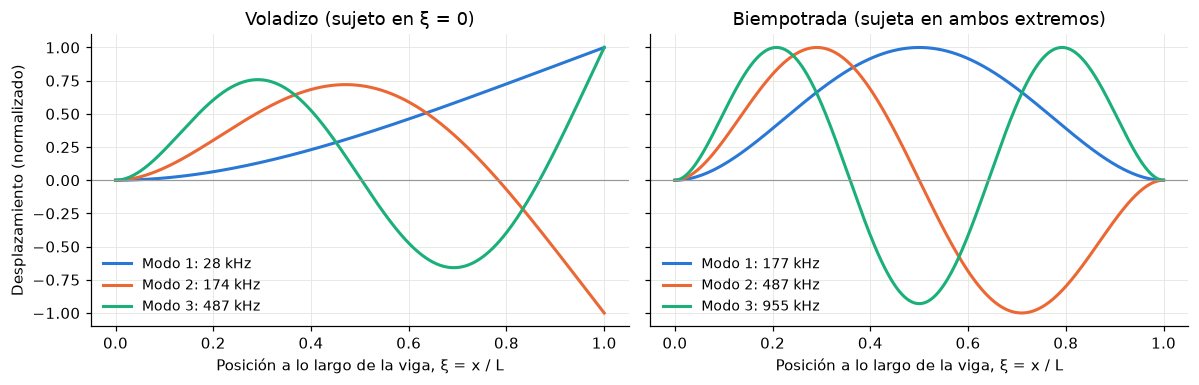

In [3]:
voladizo = resolver_modos(viga, "voladizo")
biempotrada = resolver_modos(viga, "biempotrada")

xi = np.linspace(0, 1, 400)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for eje, (nombre, modos) in zip(ejes, [("Voladizo (sujeto en ξ = 0)", voladizo),
                                        ("Biempotrada (sujeta en ambos extremos)", biempotrada)]):
    w = modos.forma(xi)
    for m in range(3):
        eje.plot(xi, w[m], color=COLORES[m],
                 label=f"Modo {m + 1}: {modos.frecuencias_hz[m] / 1e3:.0f} kHz")
    eje.axhline(0, color="#999", linewidth=0.8)
    eje.set_title(nombre)
    eje.set_xlabel("Posición a lo largo de la viga, ξ = x / L")
    eje.legend(frameon=False, fontsize=9)
ejes[0].set_ylabel("Desplazamiento (normalizado)")
fig.tight_layout()

Las formas tienen **amplitud arbitraria** (depende de qué tan fuerte se excite la viga), así que las normalizamos para que su valor máximo sea 1. Lo que importa es su forma y su frecuencia.

## 1.4 Cómo calculamos la vibración y cómo sabemos que el cálculo es correcto

La vibración de una viga delgada se describe con la **ecuación de Euler–Bernoulli**:

  E·I·w⁗ − N·w″ − ω²·ρA·w = 0

donde w es el desplazamiento, I y A dependen de la sección (b, h), N es la tensión axial y ω la frecuencia. El código la resuelve con **elementos finitos**: divide la viga en 200 tramos, resuelve un problema de álgebra lineal y obtiene frecuencias y formas en milisegundos.

Antes de confiar en el código, lo comparamos con **soluciones exactas de libro de texto**. Para vigas ideales, ω = (βL)²·√(EI / ρAL⁴), con valores βL conocidos. El proyecto exige un error menor a 0.1%; obtenemos errores un millón de veces menores. Hay muchas más pruebas automáticas en `tests/` (con tensión, pandeo, soportes flexibles, cortante y conicidad).

In [4]:
raices = {"voladizo": [1.8751040687, 4.6940911330, 7.8547574382],
          "biempotrada": [4.7300407449, 7.8532046241, 10.9956078380]}
escala = math.sqrt(viga.EI / (viga.rho * viga.A * viga.L**4))
filas = []
for nombre, modos in [("voladizo", voladizo), ("biempotrada", biempotrada)]:
    for m in range(3):
        exacta = raices[nombre][m] ** 2 * escala
        filas.append({"estructura": nombre, "modo": m + 1,
                      "exacta (kHz)": exacta / (2 * np.pi * 1e3),
                      "calculada (kHz)": modos.frecuencias_hz[m] / 1e3,
                      "error relativo": f"{abs(modos.omega[m] / exacta - 1):.1e}"})
pd.DataFrame(filas).set_index(["estructura", "modo"])

exacta (kHz)  calculada (kHz) error relativo
estructura  modo                                              
voladizo    1            27.77            27.77        2.5e-08
            2           174.04           174.04        1.3e-09
            3           487.32           487.32        1.5e-09
biempotrada 1           176.72           176.72        1.5e-09
            2           487.13           487.13        1.5e-09
            3           954.97           954.97        6.3e-09

## 1.5 Los cuatro generadores: vigas perfectas e imperfectas

Los datos se generan con cuatro modelos, de M0 (perfecto) a M3. Los métodos que evaluaremos **siempre** usan el modelo simple (M0). Cada generador agrega una imperfección real que el modelo simple ignora:

| Generador | Qué agrega | Situación real | Cuántos niveles |
|---|---|---|---|
| **M0** | Nada: viga ideal | Control: todos los métodos deberían acertar | 1 |
| **M1** | El soporte **gira y/o se desplaza un poco**, como un resorte, la viga se comporta como si fuera un poco más larga y vibra más lento | El anclaje de una viga real nunca es perfectamente rígido | **6** (eje principal) |
| **M2** | **Cortante** e inercia de rotación (teoría de Timoshenko) | Vigas cortas y gruesas | 1 |
| **M3** | El espesor **varía linealmente** a lo largo de la viga | El grabado químico no es uniforme en el chip | 1 |

M1 es el caso principal porque es la explicación más probable del efecto que vio el NIST. M2 y M3 son una prueba de control: *¿el método que funciona bien con M1 sigue funcionando cuando el error tiene otra causa?*

A simple vista las formas de M1–M3 son casi idénticas a las de M0. Por eso graficamos la **diferencia** con M0: es la "huella" de cada imperfección, lo que un buen método tendría que detectar.

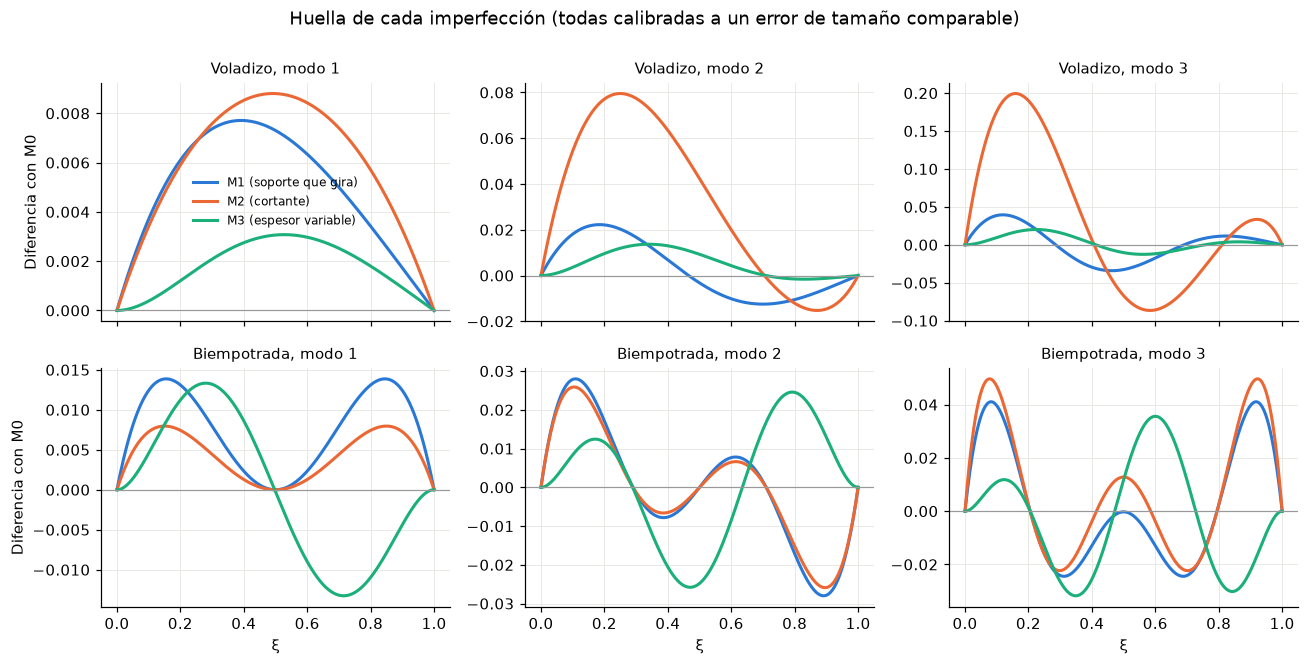

In [5]:
def fila_cal(nombre):
    return CALIBRACION.query("nombre == @nombre").iloc[0]

fig, ejes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for fila_ejes, est in zip(ejes, ["voladizo", "biempotrada"]):
    m0 = resolver_modos(viga, est).forma(xi)
    corta = Viga(**{**viga.__dict__, "L": float(fila_cal(f"m2_{est}").L)})
    huellas = {
        "M1 (soporte que gira)":
            resolver_modos(viga, est, Soporte(kappa_theta=float(fila_cal(f"m1_{est}_s3").kappa_theta))).forma(xi) - m0,
        "M2 (cortante)":
            resolver_modos(corta, est, timoshenko=Timoshenko()).forma(xi) - resolver_modos(corta, est).forma(xi),
        "M3 (espesor variable)":
            resolver_modos(viga, est, alpha=float(fila_cal(f"m3_{est}").alpha)).forma(xi) - m0,
    }
    for m, eje in enumerate(fila_ejes):
        for c, (nombre, d) in enumerate(huellas.items()):
            eje.plot(xi, d[m], color=COLORES[c], label=nombre)
        eje.axhline(0, color="#999", linewidth=0.8)
        eje.set_title(f"{est.capitalize()}, modo {m + 1}", fontsize=10)
    fila_ejes[0].set_ylabel("Diferencia con M0")
for eje in ejes[-1]:
    eje.set_xlabel("ξ")
ejes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Huella de cada imperfección (todas calibradas a un error de tamaño comparable)", y=1.0)
fig.tight_layout()

**Qué se ve:**
- **M1** cambia la forma sobre todo cerca del soporte, que ahora puede girar.
- **M2** casi no afecta al modo 1, pero deforma mucho los modos 2 y 3.
- **M3** en la biempotrada rompe la simetría de la viga: cambia la forma, pero casi no la frecuencia.
- En la biempotrada, **M1 y M2 dejan huellas muy parecidas**. Un método podría confundir una causa con la otra; M2 sirve justamente para comprobarlo.

## 1.6 Qué tan imperfectas: la severidad

Para M1 necesitamos decidir **qué tan flexible** es el soporte. Lo medimos con la **severidad**: el error que comete quien calcula E con la fórmula ideal. Como la frecuencia al cuadrado es proporcional a E:

  error en E = (ω₁ de la viga imperfecta / ω₁ de la viga ideal)² − 1

La flexibilidad del soporte se describe con un número adimensional, **κ_θ** (kappa): grande = soporte casi rígido, pequeño = soporte muy flexible. Elegimos **6 niveles** (s1 a s6) con errores en E de 1, 2.5, 5, 10, 15 y 25%:

- **s3 = 5%**: el error típico por el soporte que reporta la literatura (M-TEST).
- **s5 = 15%**: equivale a que la viga se comporte como si fuera **12.4 µm más larga**, el mismo orden que sale de los datos reales del NIST (12–13 µm). Es decir, el nivel "realista".

,κ_θ,error en E (%),cambio de forma (%),alargamiento equivalente (µm)
config,,,,
m1_voladizo_s1,396.12,-1.00,0.62,0.75
m1_voladizo_s2,156.12,-2.50,1.53,1.90
m1_voladizo_s3,76.12,-5.00,2.96,3.87
m1_voladizo_s4,36.11,-10.00,5.56,8.01
m1_voladizo_s5,22.77,-15.00,7.87,12.44
m1_voladizo_s6,12.09,-25.00,11.79,22.37
m1_voladizo_s5_ku_anillo,22.77,-17.97,58.92,15.23
m1_voladizo_s5_ku_pilares_apilados,22.77,-15.86,35.28,13.23
m1_voladizo_s5_ku_pilares_laterales,22.77,-15.43,22.31,12.84


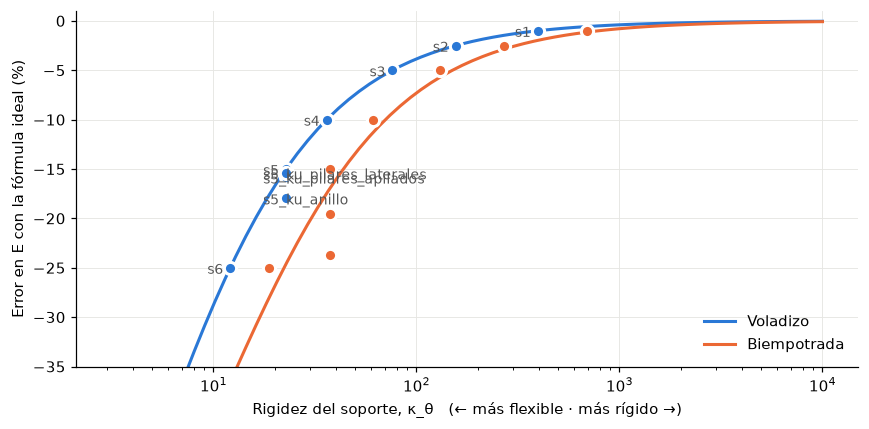

In [6]:
m1 = CALIBRACION.query("generador == 'M1'")
kappas = np.logspace(0.5, 4, 70)
fig, eje = plt.subplots(figsize=(8, 4))
for i, est in enumerate(["voladizo", "biempotrada"]):
    curva = [severidad(viga, est, Soporte(kappa_theta=k)).sesgo_E for k in kappas]
    eje.semilogx(kappas, 100 * np.array(curva), color=COLORES[i], label=est.capitalize())
    p = m1[m1.estructura == est]
    eje.plot(p.kappa_theta, 100 * p.sesgo_E, "o", color=COLORES[i], markersize=8,
             markeredgecolor="white", markeredgewidth=2)
for _, f in m1[m1.estructura == "voladizo"].iterrows():
    eje.annotate(f.nivel, (f.kappa_theta, 100 * f.sesgo_E), textcoords="offset points",
                 xytext=(-15, -4), color="#555", fontsize=9)
eje.set_xlabel("Rigidez del soporte, κ_θ   (← más flexible · más rígido →)")
eje.set_ylabel("Error en E con la fórmula ideal (%)")
eje.set_ylim(-35, 1)
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

tabla = m1.assign(error_E=100 * m1.sesgo_E, forma=100 * m1.diferencia_forma, dL=1e6 * m1.delta_L)
tabla = tabla[["nombre", "kappa_theta", "error_E", "forma", "dL"]]
tabla.columns = ["config", "κ_θ", "error en E (%)", "cambio de forma (%)", "alargamiento equivalente (µm)"]
tabla.set_index("config")

Dos observaciones:

- **La forma cambia mucho menos que la frecuencia.** En s1 y s2 el cambio de forma (≈1%) es menor que el ruido de medición que simulamos (2%). Un método que solo mire la forma casi no puede distinguir esos niveles de una viga perfecta.
- **M1 reproduce lo que vio el NIST.** Si el *mismo* soporte sostiene vigas de distinta longitud, las cortas sienten más su flexibilidad. La siguiente gráfica fija el soporte del nivel s5 y calcula el E que daría la fórmula ideal para vigas de 150 a 450 µm: E aparente sube con la longitud, igual que en las mediciones del NIST.

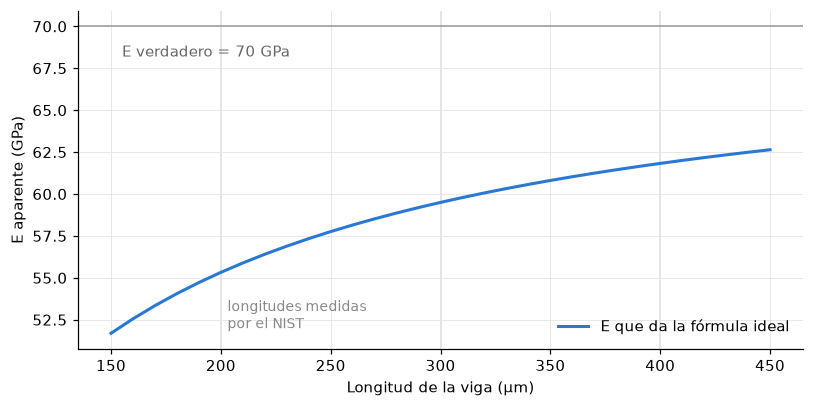

In [7]:
esc = Escalas.desde_viga(viga)
s5 = Soporte(kappa_theta=float(fila_cal("m1_voladizo_s5").kappa_theta))
k_theta_fisico, _ = esc.desde_soporte(s5)  # rigidez física del soporte, N·m/rad

longitudes = np.linspace(150e-6, 450e-6, 31)
E_aparente = []
for L in longitudes:
    v = Viga(**{**viga.__dict__, "L": L})
    E_aparente.append(viga.E * (1 + severidad(v, "voladizo", Soporte.desde_rigideces(v, k_theta_fisico, math.inf)).sesgo_E))

fig, eje = plt.subplots(figsize=(7.5, 3.8))
eje.plot(1e6 * longitudes, np.array(E_aparente) / 1e9, color=COLORES[0], label="E que da la fórmula ideal")
eje.axhline(viga.E / 1e9, color="#999", linewidth=1)
eje.text(155, viga.E / 1e9 - 1.8, "E verdadero = 70 GPa", color="#666")
for L in (200, 300, 400):
    eje.axvline(L, color="#ddd", linewidth=1, zorder=0)
eje.text(203, 52, "longitudes medidas\npor el NIST", color="#888", fontsize=9)
eje.set_xlabel("Longitud de la viga (µm)")
eje.set_ylabel("E aparente (GPa)")
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

**Severidad de M2 y M3.** Se usa un solo nivel, igualado a s3 (5% de error en E):

- **M2:** en la viga del NIST el cortante es despreciable (0.01% en E). Para que importe hay que usar una viga **más corta** con el mismo espesor: 42 µm en la biempotrada y 14 µm en el voladizo.
- **M3:** en el voladizo, la variación de espesor que da 5% de error en E (±2%). En la biempotrada la frecuencia casi no reacciona, así que se iguala el **cambio de forma** de s3.

In [8]:
ref = CALIBRACION[CALIBRACION.nombre.str.match(r"m1_.*_s3|m2_|m3_")]
pd.DataFrame({
    "config": ref.nombre,
    "error en E (%)": 100 * ref.sesgo_E,
    "cambio en ω₃ (%)": 100 * ref.corrimiento_omega3,
    "cambio de forma (%)": 100 * ref.diferencia_forma,
}).set_index("config")

,error en E (%),cambio en ω₃ (%),cambio de forma (%)
config,,,
m1_voladizo_s3,-5.00,-2.34,2.96
m2_voladizo,-5.00,-26.05,12.51
m3_voladizo,-5.00,-0.28,1.47
m1_biempotrada_s3,-5.00,-2.88,2.50
m2_biempotrada,-5.00,-9.26,2.56
m3_biempotrada,-0.04,-0.02,2.50


**¿Y si el soporte también se desplaza?** En M1 hay dos resortes: uno de giro (κ_θ) y uno de desplazamiento vertical (κ_u). El eje principal solo usa el de giro (κ_u = ∞), porque su nivel s5 coincide con la rigidez de giro estimada para el chip real del NIST. Pero esos mismos datos reales se explican igual de bien con un soporte que se desplaza, así que no permiten fijar κ_u.

Para ver cuánto importaría, hay 6 conjuntos de **sensibilidad**: el nivel s5 más un resorte de desplazamiento tomado de tres tipos de soporte de la tesis de Deutsch (2002), llevados a la geometría del NIST. Son soportes de polisilicio distintos del anclaje del NIST y probablemente más blandos, así que marcan una cota de lo que podría pasar.

In [9]:
sens = CALIBRACION[CALIBRACION.nombre.str.contains(r"_s5(?:$|_ku_)")]
pd.DataFrame({
    "config": sens.nombre,
    "κ_u": sens.kappa_u,
    "error en E (%)": 100 * sens.sesgo_E,
    "cambio en ω₃ (%)": 100 * sens.corrimiento_omega3,
    "cambio de forma (%)": 100 * sens.diferencia_forma,
}).set_index("config")

,κ_u,error en E (%),cambio en ω₃ (%),cambio de forma (%)
config,,,,
m1_voladizo_s5,inf,-15.00,-6.15,7.87
m1_voladizo_s5_ku_anillo,188.23,-17.97,-39.53,58.92
m1_voladizo_s5_ku_pilares_apilados,658.79,-15.86,-21.69,35.28
m1_voladizo_s5_ku_pilares_laterales,1317.59,-15.43,-14.21,22.31
m1_biempotrada_s5,inf,-15.00,-8.08,7.03
m1_biempotrada_s5_ku_anillo,188.23,-38.53,-61.84,65.16
m1_biempotrada_s5_ku_pilares_apilados,658.79,-23.69,-44.46,49.80
m1_biempotrada_s5_ku_pilares_laterales,1317.59,-19.57,-32.12,38.23


Un soporte que se desplaza casi no cambia la frecuencia del modo 1 del voladizo (de −15 a −18 % de error en E), que es lo único que mide el Brazo 1 con datos reales. En cambio, transforma los **modos altos**: con el soporte más blando, el modo 3 del voladizo se vuelve casi un movimiento del propio soporte. En la viga biempotrada el efecto es mucho mayor, incluso en el modo 1. Por eso medir varias formas modales o varios modos ayudaría a distinguir el giro del desplazamiento del soporte.

## 1.7 Un conjunto de datos, paso a paso

Cada conjunto de datos se describe con un pequeño archivo de configuración (YAML) en `datos/sinteticos/configs/`. Hay 24: los 18 del eje principal (M0, M1 en 6 niveles, M2 y M3, cada uno para voladizo y biempotrada) y 6 de sensibilidad al desplazamiento del soporte (sección 1.6). Así se ve uno:

In [10]:
print((CONFIGS / "m1_voladizo_s3.yaml").read_text())

# M1, severidad s3 de 6: sesgo en E = -5.0%, ΔL = 3.87 µm.
# Generado por scripts/calibrar_severidad.py; no editar a mano.
nombre: m1_voladizo_s3
generador: M1
estructura: voladizo
params:
  E: 70000000000.0
  L: 0.0003
  b: 2.8e-05
  h: 2.743e-06
  rho: 2200.0
  sigma0: 0.0
soporte:
  kappa_theta: 76.1171
  kappa_u: .inf
muestreo:
  n_puntos: 100
  n_modos: 3
ruido:
  nivel: 0.02
  nivel_omega: 0.0003
  semilla: 0
malla:
  n_elem: 200



| Campo | Qué indica |
|---|---|
| `generador`, `estructura` | Qué viga simular: M0–M3, voladizo o biempotrada |
| `params` | Material y geometría en unidades SI (E en Pa, longitudes en m, densidad en kg/m³) y la tensión residual σ₀ (−5 MPa, una compresión leve, en la viga biempotrada; 0 en los voladizos, cuyo extremo libre no conserva tensión) |
| `soporte` | Solo M1: rigidez del soporte al giro (`kappa_theta`) y al desplazamiento (`kappa_u`); `.inf` significa perfectamente rígido |
| `muestreo` | Cuántos puntos y cuántos modos se miden |
| `ruido` | Nivel de ruido en las formas (`nivel`, 0.02 = 2%), en las frecuencias (`nivel_omega`, 0.0003 = 0.03%) y semilla |
| `malla` | En cuántos tramos divide el cálculo a la viga |

Con esa configuración, `generar()`:

1. Construye la viga y el generador indicados (aquí M1 con κ_θ = 76).
2. Calcula frecuencias y formas modales.
3. Muestrea las formas en N = 100 puntos.
4. Agrega **ruido de medición** gaussiano: 2% de la amplitud máxima de cada modo en las formas y 0.03% en cada frecuencia (la dispersión entre mediciones repetidas que reporta Marshall). La **semilla** fija los números aleatorios: con la misma semilla se obtienen exactamente los mismos datos.

Los datos no se guardan en git: cualquiera los puede regenerar idénticos con `python scripts/generar_sinteticos.py`.

Frecuencias (kHz): [ 27.08 169.85 476.02]


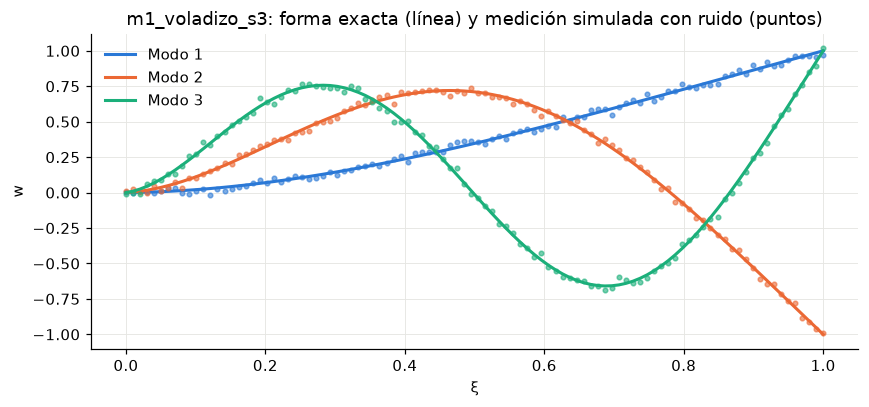

In [11]:
conjunto = generar(cargar_config(CONFIGS / "m1_voladizo_s3.yaml"))

fig, eje = plt.subplots(figsize=(8, 3.8))
for m in range(3):
    eje.plot(conjunto.xi, conjunto.w_limpia[m], color=COLORES[m], label=f"Modo {m + 1}")
    eje.plot(conjunto.xi, conjunto.w[m], "o", color=COLORES[m], markersize=3, alpha=0.6)
eje.set_title("m1_voladizo_s3: forma exacta (línea) y medición simulada con ruido (puntos)")
eje.set_xlabel("ξ")
eje.set_ylabel("w")
eje.legend(frameon=False)
fig.tight_layout()
print("Frecuencias (kHz):", np.round(conjunto.omega / (2 * np.pi * 1e3), 2))

### Estructura de los datos sintéticos

**Organización en el repositorio.** Lo que se guarda en git son las *recetas* (configuraciones) y la tabla de calibración; los datos se fabrican a partir de ellas:

```
datos/sinteticos/
├── configs/                 ← una receta YAML por conjunto de datos (24 archivos)
│   ├── m0_voladizo.yaml
│   ├── m1_voladizo_s1.yaml … m1_voladizo_s6.yaml
│   ├── m1_voladizo_s5_ku_anillo.yaml … (sensibilidad a κ_u)
│   ├── m2_voladizo.yaml
│   ├── m3_voladizo.yaml
│   └── … (lo mismo para biempotrada)
├── calibracion.csv          ← severidad de cada receta (error en E, cambio de forma, …)
└── generados/               ← archivos .npz producidos (no se guardan en git)
    └── m1_voladizo_s3.npz …
```

**Nombres.** Cada conjunto se llama `m<generador>_<estructura>[_s<nivel>]`; los de sensibilidad agregan `_ku_<soporte>`. Por ejemplo, `m1_biempotrada_s5` es una viga biempotrada con soporte flexible (M1) en el nivel de severidad 5, y `m3_voladizo` es un voladizo con espesor variable (M3).

**Catálogo.** El eje principal tiene 9 casos (M0, M1 en 6 niveles, M2 y M3) para cada una de las 2 estructuras, es decir, 18 conjuntos; además hay 6 de sensibilidad a κ_u:

In [12]:
catalogo = []
for ruta in sorted(CONFIGS.glob("*.yaml")):
    cfg = cargar_config(ruta)
    p = cfg["params"]
    detalle = {
        "M0": "viga perfecta",
        "M1": f"soporte flexible, κ_θ = {cfg.get('soporte', {}).get('kappa_theta', 0):.1f}"
              + (f", κ_u = {cfg['soporte']['kappa_u']:.0f}" if math.isfinite(float(cfg.get('soporte', {}).get('kappa_u', math.inf))) else ""),
        "M2": f"cortante, viga de {float(p['L']) * 1e6:.1f} µm",
        "M3": f"espesor variable, α = {cfg.get('conicidad', {}).get('alpha', 0):.3f}",
    }[cfg["generador"]]
    catalogo.append({"conjunto": cfg["nombre"], "generador": cfg["generador"],
                     "estructura": cfg["estructura"], "qué simula": detalle,
                     "puntos N": cfg["muestreo"]["n_puntos"], "modos": cfg["muestreo"]["n_modos"],
                     "ruido": f"{100 * cfg['ruido']['nivel']:.0f}%", "semilla": cfg["ruido"]["semilla"]})
pd.DataFrame(catalogo).set_index("conjunto")

,generador,estructura,qué simula,puntos N,modos,ruido,semilla
conjunto,,,,,,,
m0_biempotrada,M0,biempotrada,viga perfecta,100,3,2%,0
m0_voladizo,M0,voladizo,viga perfecta,100,3,2%,0
m1_biempotrada_s1,M1,biempotrada,"soporte flexible, κ_θ = 689.0",100,3,2%,0
m1_biempotrada_s2,M1,biempotrada,"soporte flexible, κ_θ = 270.2",100,3,2%,0
m1_biempotrada_s3,M1,biempotrada,"soporte flexible, κ_θ = 130.6",100,3,2%,0
m1_biempotrada_s4,M1,biempotrada,"soporte flexible, κ_θ = 60.8",100,3,2%,0
m1_biempotrada_s5,M1,biempotrada,"soporte flexible, κ_θ = 37.5",100,3,2%,0
m1_biempotrada_s5_ku_anillo,M1,biempotrada,"soporte flexible, κ_θ = 37.5, κ_u = 188",100,3,2%,0
m1_biempotrada_s5_ku_pilares_apilados,M1,biempotrada,"soporte flexible, κ_θ = 37.5, κ_u = 659",100,3,2%,0


**Contenido de cada conjunto.** Cada archivo `.npz` (formato estándar de NumPy) tiene los mismos campos, así que todos los métodos del proyecto lo leen igual. Con N puntos de medición y 3 modos:

| Campo | Forma | Unidades | Contenido |
|---|---|---|---|
| `xi` | (N,) | sin unidades | Posiciones de medición, de 0 (soporte) a 1 (punta), igualmente espaciadas |
| `w` | (3, N) | sin unidades | Formas modales **con ruido**: lo que "mide" el método. Fila i = modo i + 1 |
| `w_limpia` | (3, N) | sin unidades | Las mismas formas sin ruido; solo para analizar resultados, nunca como entrada de un método |
| `omega` | (3,) | rad/s | Frecuencias naturales de los modos 1–3 **con ruido** (0.03%): lo que "mide" el método |
| `omega_limpia` | (3,) | rad/s | Las mismas frecuencias sin ruido; solo para analizar resultados |
| `nombre` | texto | — | Nombre del conjunto, p. ej. `m1_voladizo_s3` |
| `estructura` | texto | — | `voladizo` o `biempotrada` |
| `generador` | texto | — | `M0`, `M1`, `M2` o `M3` |
| `params` | texto JSON | SI | Parámetros físicos: E (la respuesta correcta), L, b, h, ρ, σ₀ y los del generador (κ_θ, κ_u, ν, α…) |
| `ruido` | texto JSON | — | Niveles de ruido (formas y frecuencias) y semilla usados |
| `config` | texto JSON | — | La receta YAML completa con la que se generó |
| `version` | texto | — | Versión del código (commit de git) que lo generó |

La siguiente celda guarda el conjunto del ejemplo, lo vuelve a leer directamente con NumPy y muestra lo que contiene:

In [13]:
with tempfile.TemporaryDirectory() as carpeta:
    ruta = conjunto.guardar(Path(carpeta) / "m1_voladizo_s3.npz")
    with np.load(ruta) as archivo:
        contenido = pd.DataFrame(
            [{"campo": k, "forma": str(archivo[k].shape) if archivo[k].ndim else "texto",
              "tipo": str(archivo[k].dtype)} for k in archivo.files]
        ).set_index("campo")
    copia = Conjunto.cargar(ruta)

print("Se guarda y se lee sin cambios:", np.array_equal(copia.w, conjunto.w) and copia.params == conjunto.params)
print("E verdadero guardado en el archivo:", copia.params["E"] / 1e9, "GPa")
contenido

Se guarda y se lee sin cambios: True
E verdadero guardado en el archivo: 70.0 GPa


,forma,tipo
campo,,
xi,"(100,)",float64
w,"(3, 100)",float64
w_limpia,"(3, 100)",float64
omega,"(3,)",float64
omega_limpia,"(3,)",float64
nombre,texto,<U14
estructura,texto,<U8
generador,texto,<U2
params,texto,<U138


### Distribución del ruido y de las frecuencias

En los datos sintéticos, el análisis univariante sirve para comprobar que cada variable tiene el rango y el ruido pedidos: ruido gaussiano de 2 % de la amplitud en las formas y de 0.03 % en las frecuencias.

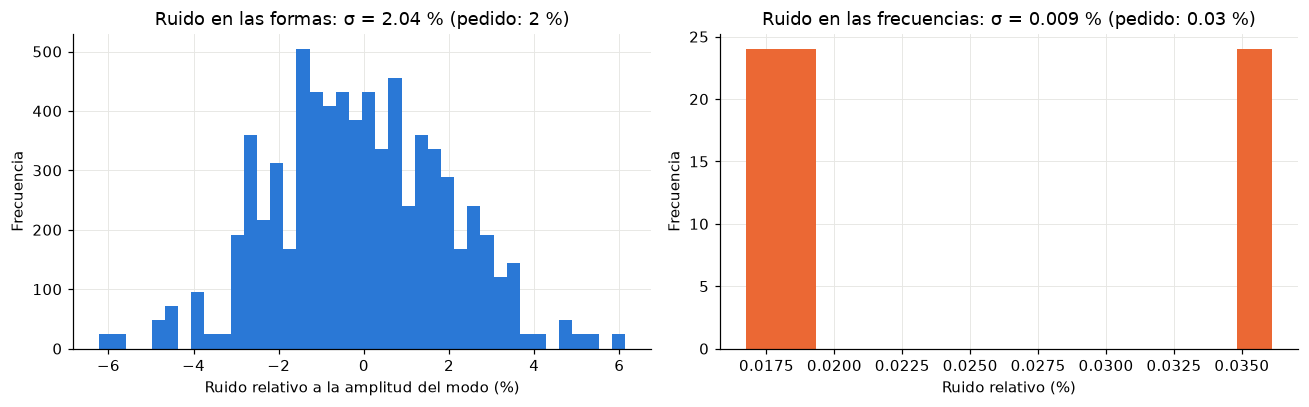

estructura      biempotrada  voladizo
f1 (kHz) count         12.0      12.0
         mean         853.8    1003.6
         std         2478.5    3385.6
         min          106.1      24.1
         25%          129.9      25.5
         50%          144.8      26.7
         75%          151.9      27.5
         max         8724.0   11754.3
f2 (kHz) count         12.0      12.0
         mean        2306.3    5537.5
         std         6617.1   18620.4
         min          201.7     130.2
         25%          381.1     156.7
         50%          435.2     167.9
         75%          453.8     172.8
         max        23317.2   64665.2
f3 (kHz) count         12.0      12.0
         mean        4378.0   13444.4
         std        12467.7   45036.9
         min          351.6     294.8
         25%          760.3     436.9
         50%          882.5     471.1
         75%          917.3     485.3
         max        43964.0  156455.7

In [14]:
ruido_formas, ruido_frec, frecuencias = [], [], []
for ruta in sorted(CONFIGS.glob("*.yaml")):
    cj = generar(cargar_config(ruta))
    ruido_formas.append(((cj.w - cj.w_limpia) / np.abs(cj.w_limpia).max(axis=1, keepdims=True)).ravel())
    ruido_frec.append(cj.omega / cj.omega_limpia - 1)
    frecuencias.append({"estructura": cj.estructura, **{f"f{i + 1} (kHz)": w / (2e3 * np.pi) for i, w in enumerate(cj.omega)}})
ruido_formas, ruido_frec = np.concatenate(ruido_formas), np.concatenate(ruido_frec)

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.8))
ejes[0].hist(100 * ruido_formas, bins=40, color=COLORES[0])
ejes[0].set_title(f"Ruido en las formas: σ = {100 * ruido_formas.std():.2f} % (pedido: 2 %)")
ejes[0].set_xlabel("Ruido relativo a la amplitud del modo (%)")
ejes[1].hist(100 * ruido_frec, bins=15, color=COLORES[1])
ejes[1].set_title(f"Ruido en las frecuencias: σ = {100 * ruido_frec.std():.3f} % (pedido: 0.03 %)")
ejes[1].set_xlabel("Ruido relativo (%)")
for e in ejes:
    e.set_ylabel("Frecuencia")
fig.tight_layout()
plt.show()
display(pd.DataFrame(frecuencias).groupby("estructura").describe().T.round(1))

El ruido realizado coincide con el pedido y es simétrico y centrado en cero. Las frecuencias abarcan dos regímenes: las vigas de 300 µm vibran en decenas a cientos de kHz y las vigas cortas de M2, en MHz; por eso se analizan por caso y no todas juntas.

## 1.8 Cómo se usarán los datos

Cada método recibe las mediciones (`w`, `omega`) y la geometría, y estima E **usando el modelo simple**. Como sabemos el E verdadero, medimos su error. Los métodos se organizan en cuatro niveles según cuánto "desconfían" del modelo simple:

| Nivel | Idea | Ejemplos |
|---|---|---|
| **L0** | Confía totalmente en el modelo simple | Fórmula estándar de la industria, ajuste clásico, PINN con la física fija |
| **L1** | Permite que los datos se aparten un poco de la física | PINN con la física "relajada" |
| **L2** | Agrega un término genérico de corrección | PINN o ajuste clásico con un término de discrepancia |
| **L3** | Agrega la física que falta | Ajuste o PINN que también estiman la flexibilidad del soporte |

### Un primer vistazo: el método más simple

Antes de los métodos sofisticados, apliquemos a cada conjunto la fórmula ideal (un método L0): despejar E de la primera frecuencia. Es lo que se hace hoy en la industria. **En M0 acierta; en las vigas imperfectas se equivoca**, y el error crece con la severidad. Los métodos del proyecto deben reducir ese error.

estructura,biempotrada,voladizo
caso,,
m0,-0.00,0.0
m1_s1,-1.00,-1.0
m1_s2,-2.50,-2.5
m1_s3,-5.00,-5.0
m1_s4,-10.00,-10.0
m1_s5,-15.00,-15.0
m1_s6,-25.00,-25.0
m2,-5.00,-5.0
m3,-0.04,-5.0


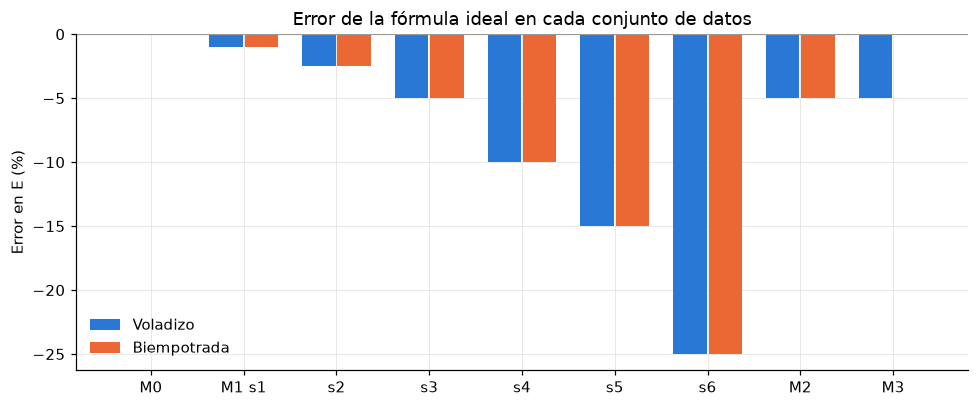

In [15]:
from pinn_mems.severidad import E_aparente

filas = []
for ruta in sorted(CONFIGS.glob("*.yaml")):
    c = generar(cargar_config(ruta))
    v = Viga(**{k: c.params[k] for k in ("E", "L", "b", "h", "rho", "sigma0")})
    # E con el que el modelo ideal da la frecuencia (sin ruido) de este conjunto;
    # con tensión (biempotrada) la frecuencia no es ∝ √E y se invierte el modelo
    E_estimado = E_aparente(v, c.estructura, c.omega_limpia[0])
    filas.append({"config": c.nombre, "estructura": c.estructura,
                  "error en E (%)": 100 * (E_estimado / c.params["E"] - 1)})
resultados = pd.DataFrame(filas)

orden = ["m0", *[f"m1_s{i}" for i in range(1, 7)], "m2", "m3"]
resultados["caso"] = resultados.config.str.replace(r"_(voladizo|biempotrada)", "", regex=True)
pivote = resultados.pivot(index="caso", columns="estructura", values="error en E (%)").loc[orden]

fig, eje = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(orden))
for i, est in enumerate(["voladizo", "biempotrada"]):
    eje.bar(x + (i - 0.5) * 0.38, pivote[est], width=0.36, color=COLORES[i], label=est.capitalize())
eje.axhline(0, color="#999", linewidth=0.8)
eje.set_xticks(x, ["M0", "M1 s1", "s2", "s3", "s4", "s5", "s6", "M2", "M3"])
eje.set_ylabel("Error en E (%)")
eje.set_title("Error de la fórmula ideal en cada conjunto de datos")
eje.legend(frameon=False, loc="lower left")
fig.tight_layout()
pivote.round(2)

Fíjate en **M3 de la biempotrada**: la fórmula ideal da casi 0% de error, porque la frecuencia no cambia. Pero la forma sí cambió. Un método que use las formas debería notar que algo no cuadra; uno que use solo la frecuencia, no. Este tipo de contraste es lo que el proyecto quiere medir.

### El experimento completo

Cada método se evaluará en esta matriz (plan del proyecto, con las decisiones del equipo registradas en `contexto/bitacora-decisiones.md`):

| Eje | Valores |
|---|---|
| Generador y severidad | M0, M1 (s1–s6), M2, M3 → **9 casos** |
| Puntos medidos por viga, N | 5, 15, 40 |
| Estructuras medidas, k | 1 (voladizo de 300 µm) o 3 (voladizo de 300 µm + viga biempotrada de 300 µm con σ₀ = −5 MPa + voladizo de 200 µm, **con el mismo anclaje**) |
| Modos usados | 1 o 3 (cada conjunto guarda 3; el método elige) |
| Semillas de ruido | 10 (para separar el error sistemático del aleatorio) |
| Ruido | 2% en las formas y 0.03% en las frecuencias, fijo |

M2 usa vigas cortas que no forman un grupo realista, así que solo se evalúa con k = 1. En total son **510 corridas de datos** (8 casos × 3 N × 2 k × 10 semillas, más M2 con 3 N × 10 semillas); con los dos niveles de modos, 1020 corridas por método. Todas se generan con:

```bash
python scripts/generar_matriz.py   # 990 archivos .npz y un manifiesto en datos/sinteticos/generados/matriz/
```

El mismo comando genera también dos complementos del plan:

- **Longitudes reservadas:** las frecuencias verdaderas de voladizos de 248 y 348 µm, con el mismo anclaje, que ningún método ve al ajustar. Sirven para medir qué tan bien predice cada método vigas nuevas.
- **Colocación de los puntos (pregunta RQ4):** 60 corridas con los puntos repartidos de tres maneras (uniforme, concentrados cerca del anclaje o cerca de la punta). Un análisis de información de Fisher anticipa que, si se miden 3 modos, la colocación casi no importa, y que con 1 modo la distribución uniforme es la mejor.

### Preparación para la PINN: adimensionalización

Una red neuronal entrena mal cuando sus números tienen escalas muy distintas, y en una viga MEMS conviven valores de 10⁻²³ (momento de inercia, en m⁴) y de 10¹⁰ (E, en Pa). Por eso todo se reescribe con cantidades **sin unidades**, de tamaño parecido. El código (`pinn_mems.adimensional`) hace la conversión de ida y vuelta, y el solver usa internamente las mismas cantidades.

In [16]:
modos = resolver_modos(viga, "voladizo", s5)
w_tipico = 50e-9  # amplitud típica de vibración: 50 nm
M_tipico = viga.EI * w_tipico / viga.L**2
con_unidades = {"I (m⁴)": viga.I, "E (Pa)": viga.E, "ρA (kg/m)": viga.rho * viga.A,
                "ω₁ (rad/s)": modos.omega[0], "w (m)": w_tipico, "momento (N·m)": M_tipico}
sin_unidades = {"λ₁": esc.a_lambda(modos.omega[0]), "κ_θ": s5.kappa_theta,
                "W = w/h": esc.a_W(w_tipico), "momento adim.": esc.a_M(M_tipico), "θ = E/E_ref": 1.0}

def rango(d):
    return np.log10(max(d.values()) / min(d.values()))

print("Con unidades:", ", ".join(f"{k} = {v:.0e}" for k, v in con_unidades.items()))
print(f"  → abarcan {rango(con_unidades):.0f} órdenes de magnitud\n")
print("Sin unidades:", ", ".join(f"{k} = {v:.3g}" for k, v in sin_unidades.items()))
print(f"  → abarcan {rango(sin_unidades):.0f} órdenes de magnitud")

Con unidades: I (m⁴) = 5e-23, E (Pa) = 7e+10, ρA (kg/m) = 2e-07, ω₁ (rad/s) = 2e+05, w (m) = 5e-08, momento (N·m) = 2e-12
  → abarcan 33 órdenes de magnitud

Sin unidades: λ₁ = 10.5, κ_θ = 22.8, W = w/h = 0.0182, momento adim. = 0.0182, θ = E/E_ref = 1
  → abarcan 3 órdenes de magnitud


## 1.9 Conclusiones

**Qué son los datos.** Son mediciones simuladas de vigas microscópicas que vibran, frecuencias y formas modales, fabricadas por computadora con un E verdadero conocido (70 GPa). Como conocemos la respuesta correcta, podemos medir exactamente cuánto se equivoca cada método al estimar E.

**Cómo se construyeron.** Un modelo de elementos finitos calcula la vibración de la viga y reproduce las soluciones exactas de libro de texto con un error un millón de veces menor que el 0.1 % exigido. Sobre ese modelo, cuatro generadores fabrican vigas perfectas (M0) e imperfectas: con un soporte que gira (M1, en seis niveles de severidad), con cortante (M2) y con espesor variable (M3). Cada conjunto se describe con una receta y una semilla, así que cualquiera puede regenerarlo idéntico.

**Qué tan realistas son.** La geometría es la de un chip de referencia del NIST, y el nivel s5 de M1 corresponde a la rigidez de anclaje que estimamos con las mediciones reales del NIST: el mismo soporte reproduce la forma en que el E medido crece con la longitud de la viga. El ruido simulado (2 % en las formas y 0.03 % en las frecuencias) y la tensión residual de la viga biempotrada (una compresión leve, como en los chips reales) también se eligieron con base en los datos publicados.

**Qué mostraron antes de probar cualquier método:**
- La fórmula estándar se equivoca de forma sistemática: el error en E crece con la imperfección del soporte, de 1 % a 25 %.
- Las imperfecciones dejan huellas distintas: el soporte flexible cambia sobre todo la frecuencia, el cortante afecta a los modos altos y el espesor variable puede cambiar la forma sin mover la frecuencia.
- La forma modal cambia mucho menos que la frecuencia; en los niveles más suaves el cambio queda por debajo del ruido.
- Un soporte que se desplaza casi no altera la primera frecuencia, pero transforma los modos altos. Medir varios modos ayuda a distinguir qué está fallando en el modelo.

**Cómo se usarán.** Los datos forman la matriz completa del experimento: 9 casos, 3 cantidades de puntos de medición, 1 o 3 estructuras y 10 semillas, más dos complementos (longitudes reservadas para validar predicciones y un estudio de colocación de los puntos). Sobre ellos se compararán los cuatro niveles de métodos, de L0 a L3, para responder la pregunta del proyecto: qué forma de tratar un modelo imperfecto extrae mejor el módulo de Young.

**Para reproducir todo:**
```bash
pip install -e ".[dev]"
pytest                                   # todas las pruebas
python scripts/calibrar_severidad.py     # recalcula los niveles de severidad
python scripts/generar_sinteticos.py     # genera los 24 conjuntos en datos/sinteticos/generados/
python scripts/generar_matriz.py         # genera la matriz completa del experimento
```

# 2. Brazo 1 — Frecuencia y módulo de Young: ajuste de la curva de anclaje

Esta parte analiza el primero de los dos conjuntos de **datos reales** del proyecto: el módulo de Young E medido por el NIST en voladizos de óxido, a partir de su frecuencia de resonancia (Marshall et al., 2010). Lee las tablas de `datos/nist/tablas/` y usa las funciones de `src/pinn_mems/nist/brazo1.py`.

**En tres frases:**
1. El NIST midió E en voladizos de óxido de 200, 300 y 400 µm, con un participante (repetibilidad) y con ocho participantes de cinco laboratorios (reproducibilidad).
2. El E medido **crece con la longitud** del voladizo: la fórmula estándar supone un anclaje perfecto y se equivoca más en las vigas cortas.
3. Aquí traducimos ese efecto en un alargamiento equivalente del anclaje, **ΔL**, estimamos el E real del material y discutimos qué tanto permiten concluir estos datos.

### Objetivos del análisis

Los objetivos principales son:

- cargar y validar las Tablas 1, 2, 3, 5 y 6 transcritas del artículo;
- describir la geometría, frecuencias de diseño e incertidumbres reportadas;
- reconstruir la desviación estándar a partir de los límites del 95 % de las Tablas 5 y 6;
- ajustar la curva de anclaje

$$
E(L) = E_{\mathrm{real}} \left(\frac{L}{L+\Delta L}\right)^4
$$

- estimar $E_{\mathrm{real}}$ y $\Delta L$ para repetibilidad y reproducibilidad;
- reportar intervalos de confianza del 95 %, residuos y gráficas del ajuste;
- documentar la limitación estadística del ajuste: tres longitudes y dos parámetros implican un solo grado de libertad.

> **Fuente primaria:** Marshall et al., *MEMS Young's Modulus and Step Height Measurements With Round Robin Results*, Journal of Research of NIST, 115(5), 303–342 (2010).

## Preparación (Brazo 1)

El notebook lee las transcripciones de las tablas desde la carpeta `datos/nist/tablas/` del propio repositorio (un CSV por tabla, con su fuente en la primera línea), así que debe abrirse desde el repositorio. Las funciones de carga, preparación y ajuste están en `src/pinn_mems/nist/brazo1.py`, con pruebas en `tests/test_brazo1.py`.

In [17]:
import sys
from pathlib import Path

# Busca la raíz del repositorio subiendo desde la carpeta actual
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "pinn_mems").is_dir())
sys.path.insert(0, str(RAIZ / "src"))

### Librerías

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t

from pinn_mems.nist.brazo1 import (
    DATA_DIR,
    MARSHALL_FILES,
    SP260_FILES,
    add_uncertainties,
    anchoring_model,
    equivalent_frequency_correction,
    fit_anchoring_curve,
    fit_anchoring_curve_with_chip,
    load_fig6_reproducibility,
    frequency_from_young_modulus,
    load_marshall_table,
    load_sp260_table,
    prepare_young_modulus_data,
    print_fit_summary,
)

### Estandarización de formatos

In [19]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

FIGSIZE = (10, 6)


### Extracción de archivos

In [20]:
for table_name, filename in MARSHALL_FILES.items():
    path = DATA_DIR / filename
    print(f"{table_name}: {path.relative_to(RAIZ)} | existe={path.exists()}")

for table_name, filename in SP260_FILES.items():
    path = DATA_DIR / filename
    print(f"SP 260-177 {table_name}: {path.relative_to(RAIZ)} | existe={path.exists()}")

table1: datos/nist/tablas/marshall_T1_geometria.csv | existe=True
table2: datos/nist/tablas/marshall_T2_diseno_f_Q.csv | existe=True
table3: datos/nist/tablas/marshall_T3_incertidumbre.csv | existe=True
table5: datos/nist/tablas/marshall_T5_repetibilidad.csv | existe=True
table6: datos/nist/tablas/marshall_T6_reproducibilidad.csv | existe=True
SP 260-177 table3: datos/nist/tablas/sp260_T3_T4_f_correction.csv | existe=True
SP 260-177 table4: datos/nist/tablas/sp260_T3_T4_f_correction.csv | existe=True


### Funciones para cargar y preparar las tablas

Las funciones están en `src/pinn_mems/nist/brazo1.py`:

- `load_marshall_table` y `load_sp260_table` cargan los CSV de `datos/nist/tablas/`; la segunda separa la Tabla 3 (RM 8096) de la Tabla 4 (RM 8097) del SP 260-177.
- `prepare_young_modulus_data` toma de las Tablas 5 y 6 las tres longitudes individuales (200, 300 y 400 µm).
- `add_uncertainties` reconstruye la desviación estándar y el error estándar a partir de los límites del 95 %.

### Carga de las tablas

In [21]:
table1 = load_marshall_table("table1")
table2 = load_marshall_table("table2")
table3 = load_marshall_table("table3")
table5 = load_marshall_table("table5")
table6 = load_marshall_table("table6")

sp260_table3 = load_sp260_table("table3")
fig6 = load_fig6_reproducibility()  # 24 valores individuales digitalizados de la Fig. 6

### Validación de la carga de datos

In [22]:
for name, table in {
    "Tabla 1": table1,
    "Tabla 2": table2,
    "Tabla 3": table3,
    "Tabla 5": table5,
    "Tabla 6": table6,
}.items():
    print("\n" + "=" * 80)
    print(name)
    print("Shape:", table.shape)
    print("Columnas:", list(table.columns))
    display(table)



Tabla 1
Shape: (5, 5)
Columnas: ['L_um', 'W_um', 'orientation_deg', 'material', 'n_cantilevers']


,L_um,W_um,orientation_deg,material,n_cantilevers
0,200,28,0,oxide,5
1,248,28,0,oxide,5
2,300,28,0,oxide,5
3,348,28,0,oxide,5
4,400,28,0,oxide,5



Tabla 2
Shape: (5, 4)
Columnas: ['L µm', 'f inicial kHz', 'Q', 'pdiff %']


,L µm,f inicial kHz,Q,pdiff %
0,200,62.5000,148.0000,0.0006
1,248,40.6000,96.3000,0.0013
2,300,27.8000,65.8000,0.0029
3,348,20.6000,48.9000,0.0052
4,400,15.6000,37.0000,0.0091



Tabla 3
Shape: (8, 4)
Columnas: ['componente', 'tipo', 'GPa', 'condiciones']


,componente,tipo,GPa,condiciones
0,u_thick,Type B,2.8000,t = 2.743 µm y σ_thick = 0.058 µm
1,u_rho,Type B,1.5000,ρ = 2.2 g/cm³ y σ_ρ = 0.05 g/cm³
2,u_L,Type B,0.1700,L_can = 300 µm y σ_L = 0.2 µm
3,u_freq,Type B,0.0270,f_meas1 = 26.82625 kHz; f_meas2 = 26.8351 kHz;...
4,u_fresol,Type B,0.0018,f_resol = 1.25 Hz
5,u_damp,Type B,0.0004,W_can = 28 µm y σ_W = 0.1 µm; μ = 1.84e-5 N·s/...
6,u_cE,NaN,3.2000,NaN
7,3u_cE,NaN,9.5000,graficada en la Fig. 6 con el primer voladizo ...



Tabla 5
Shape: (5, 5)
Columnas: ['Variable', '200 µm length', '300 µm length', '400 µm length', '200 µm to 400 µm lengths']


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,16,16,16,48
1,E_ave (GPa),59.8,65.4,67.5,64.2
2,95% limits for E,± 1.4%,± 0.5%,± 1.1%,± 10.3%
3,u_cave (GPa),2.9 (4.9%),3.2 (4.8%),3.3 (4.8%),3.1 (4.8%)
4,95% limits for u_cE,± 1.4%,± 0.5%,± 1.1%,± 10.1%



Tabla 6
Shape: (5, 5)
Columnas: ['Variable', '200 µm length', '300 µm length', '400 µm length', '200 µm to 400 µm lengths']


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,8,8,8,24
1,E_ave (GPa),58.7,63.7,66.0,62.8
2,95% limits for E,± 4.4%,± 5.5%,± 4.4%,± 11.0%
3,u_cave (GPa),2.8 (4.9%),3.1 (4.8%),3.2 (4.9%),3.0 (4.9%)
4,95% limits for u_cE,± 4.4%,± 5.5%,± 4.5%,± 11.0%


### NIST SP 260-177 — Tabla 3 (RM 8096)

La Tabla 3 se conserva como **fuente externa de comparación**. Corresponde al mismo sistema RM 8096 asociado con los cantilevers de óxido analizados en Marshall. Sus columnas relevantes son `f_correction`, `sigma_support` y `sigma_cantilever`.

**Importante:** `f_correction` no se aplica a los datos de Marshall. Se utiliza únicamente para comparar, después del ajuste, si la dependencia con la longitud inferida mediante $\Delta L$ tiene una magnitud y un patrón compatibles con la corrección reportada por NIST.

In [23]:
display(sp260_table3)

assert set(sp260_table3["L (µm)"].astype(float)) == {200.0, 300.0, 400.0}
for col in ["f_correction (kHz)", "sigma_support (kHz)", "sigma_cantilever (kHz)"]:
    sp260_table3[col] = pd.to_numeric(sp260_table3[col], errors="raise")

# Verificación de la relación indicada en la tabla: sigma = |f_correction|/(3*sqrt(2)).
sp260_check = sp260_table3.copy()
sp260_check["sigma_from_f_correction_kHz"] = (
    sp260_check["f_correction (kHz)"].abs() / (3 * np.sqrt(2))
)
sp260_check["difference_support_kHz"] = (
    sp260_check["sigma_support (kHz)"]
    - sp260_check["sigma_from_f_correction_kHz"]
)
display(sp260_check)

,L (µm),f_correction (kHz),sigma_support (kHz),sigma_cantilever (kHz)
0,200,2.6700,0.6300,0.6300
1,300,0.0000,0.0000,0.0000
2,400,-0.2400,0.0570,0.0570


,L (µm),f_correction (kHz),sigma_support (kHz),sigma_cantilever (kHz),sigma_from_f_correction_kHz,difference_support_kHz
0,200,2.6700,0.6300,0.6300,0.6293,0.0007
1,300,0.0000,0.0000,0.0000,0.0000,0.0000
2,400,-0.2400,0.0570,0.0570,0.0566,0.0004


### Tipos de variables y valores faltantes

Las tablas de Marshall mezclan números y texto ("± 1.4%" o "2.9 (4.9%)"), porque se copiaron tal como aparecen en el artículo; más adelante se convierten a números. La siguiente celda revisa tipos y faltantes de cada tabla y de los 24 valores individuales de la Fig. 6.

In [24]:
resumen = []
for nombre, tabla in {"Tabla 1": table1, "Tabla 2": table2, "Tabla 3": table3, "Tabla 5": table5,
                      "Tabla 6": table6, "SP 260-177 Tabla 3": sp260_table3, "Fig. 6 (24 puntos)": fig6}.items():
    resumen.append({"tabla": nombre, "filas": tabla.shape[0], "columnas": tabla.shape[1],
                    "numéricas": int(tabla.select_dtypes("number").shape[1]),
                    "de texto": int(tabla.select_dtypes(exclude="number").shape[1]),
                    "valores faltantes": int(tabla.isna().sum().sum())})
display(pd.DataFrame(resumen).set_index("tabla"))

,filas,columnas,numéricas,de texto,valores faltantes
tabla,,,,,
Tabla 1,5,5,4,1,0
Tabla 2,5,4,4,0,0
Tabla 3,8,4,1,3,3
Tabla 5,5,5,0,5,0
Tabla 6,5,5,0,5,0
SP 260-177 Tabla 3,3,4,4,0,0
Fig. 6 (24 puntos),24,7,5,2,6


Las únicas celdas vacías son las de la Tabla 3 de Marshall sin tipo o condiciones (los totales u_cE y 3u_cE) y el instrumento de los participantes 7 y 8 en la Fig. 6, que el artículo no especifica. No falta ninguna medición.

## 2.1 Estructura y comprensión de los datos

Las cinco tablas cumplen funciones diferentes dentro del Brazo 1:

- **Tabla 1:** geometría nominal de los cantilevers. Incluye cinco longitudes de diseño, ancho, orientación, material y cantidad de cantilevers.
- **Tabla 2:** frecuencia fundamental de diseño, factor de calidad $Q$ y diferencia porcentual asociada al amortiguamiento para cada longitud.
- **Tabla 3:** ejemplo del presupuesto de incertidumbre del módulo de Young.
- **Tabla 5:** resultados de **repetibilidad**, con 16 valores de $E$ para cada una de las longitudes 200, 300 y 400 µm.
- **Tabla 6:** resultados de **reproducibilidad**, con 8 valores de $E$ para cada una de esas tres longitudes.

Las tablas se mantienen completas en `datos/nist/tablas/`, copiadas sin modificar y revisadas contra los PDF. En el ajuste solo se seleccionan las tres longitudes individuales de las Tablas 5 y 6. La columna agregada `200 µm to 400 µm lengths` se conserva como información de la fuente, pero **no representa una cuarta longitud experimental** y no se utiliza como observación independiente.

### Geometría — Tabla 1

In [25]:
display(table1)


,L_um,W_um,orientation_deg,material,n_cantilevers
0,200,28,0,oxide,5
1,248,28,0,oxide,5
2,300,28,0,oxide,5
3,348,28,0,oxide,5
4,400,28,0,oxide,5


### Frecuencia de diseño y factor Q — Tabla 2

In [26]:
display(table2.describe(include="all").T)


,count,mean,std,min,25%,50%,75%,max
L µm,5.0000,299.2000,79.0645,200.0000,248.0000,300.0000,348.0000,400.0000
f inicial kHz,5.0000,33.4200,18.7796,15.6000,20.6000,27.8000,40.6000,62.5000
Q,5.0000,79.2000,44.4532,37.0000,48.9000,65.8000,96.3000,148.0000
pdiff %,5.0000,0.0038,0.0034,0.0006,0.0013,0.0029,0.0052,0.0091


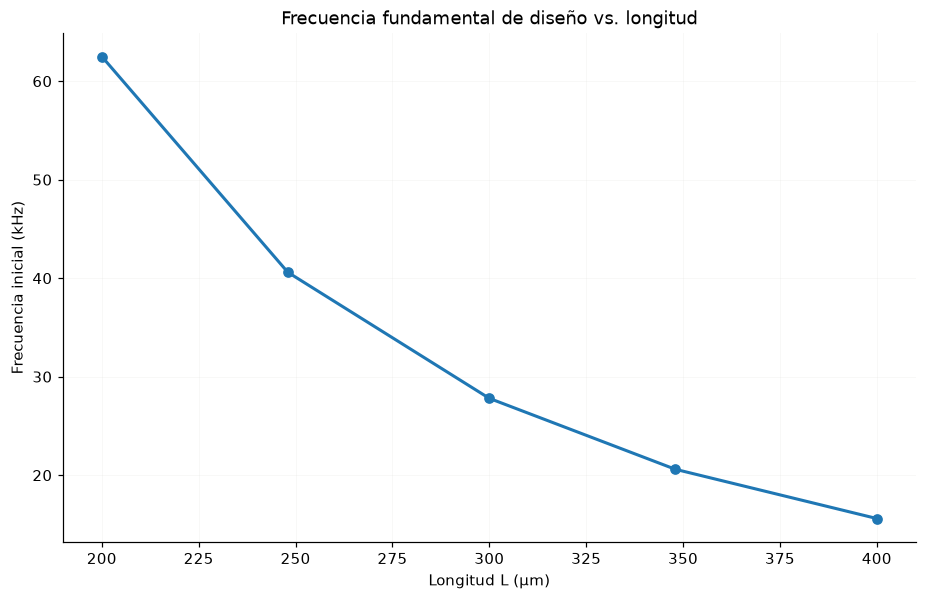

In [27]:
plt.figure(figsize=FIGSIZE)
plt.plot(table2["L µm"], table2["f inicial kHz"], marker="o")
plt.title("Frecuencia fundamental de diseño vs. longitud")
plt.xlabel("Longitud L (µm)")
plt.ylabel("Frecuencia inicial (kHz)")
plt.grid(alpha=0.3)
plt.show()


La frecuencia de diseño disminuye al aumentar la longitud del cantilever. Esta relación es coherente con la ecuación de resonancia utilizada por Marshall, en la que, manteniendo constantes las demás propiedades, la frecuencia fundamental depende inversamente de $L^2$.

### Presupuesto de incertidumbre — Tabla 3

,componente,tipo,GPa,condiciones
0,u_thick,Type B,2.8000,t = 2.743 µm y σ_thick = 0.058 µm
1,u_rho,Type B,1.5000,ρ = 2.2 g/cm³ y σ_ρ = 0.05 g/cm³
2,u_L,Type B,0.1700,L_can = 300 µm y σ_L = 0.2 µm
3,u_freq,Type B,0.0270,f_meas1 = 26.82625 kHz; f_meas2 = 26.8351 kHz;...
4,u_fresol,Type B,0.0018,f_resol = 1.25 Hz
5,u_damp,Type B,0.0004,W_can = 28 µm y σ_W = 0.1 µm; μ = 1.84e-5 N·s/...
6,u_cE,NaN,3.2000,NaN
7,3u_cE,NaN,9.5000,graficada en la Fig. 6 con el primer voladizo ...


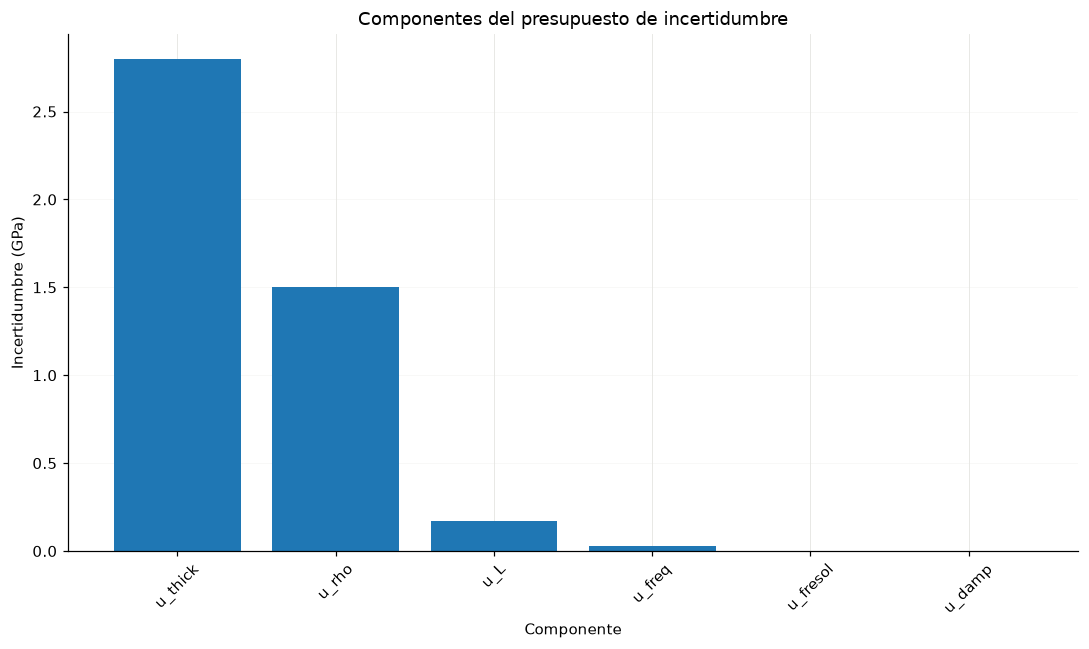

In [28]:
uncertainty_components = table3.loc[
    ~table3["componente"].isin(["u_cE", "3u_cE"])
].copy()

display(table3)

plt.figure(figsize=FIGSIZE)
plt.bar(uncertainty_components["componente"], uncertainty_components["GPa"])
plt.title("Componentes del presupuesto de incertidumbre")
plt.xlabel("Componente")
plt.ylabel("Incertidumbre (GPa)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


La Tabla 3 muestra que, en el ejemplo de Marshall, la incertidumbre asociada al espesor y a la densidad domina el presupuesto frente a las contribuciones de longitud, frecuencia, resolución y amortiguamiento. Estos componentes ya forman parte de la incertidumbre combinada $u_{cE}$; por ello, el parámetro $\Delta L$ del ajuste no debe interpretarse simplemente como otra forma de esas incertidumbres instrumentales.

## 2.2 Preparación de los datos de repetibilidad y reproducibilidad

### Tabla 5 — Repetibilidad

In [29]:
display(table5)


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,16,16,16,48
1,E_ave (GPa),59.8,65.4,67.5,64.2
2,95% limits for E,± 1.4%,± 0.5%,± 1.1%,± 10.3%
3,u_cave (GPa),2.9 (4.9%),3.2 (4.8%),3.3 (4.8%),3.1 (4.8%)
4,95% limits for u_cE,± 1.4%,± 0.5%,± 1.1%,± 10.1%


### Tabla 6 — Reproducibilidad

In [30]:
display(table6)


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,8,8,8,24
1,E_ave (GPa),58.7,63.7,66.0,62.8
2,95% limits for E,± 4.4%,± 5.5%,± 4.4%,± 11.0%
3,u_cave (GPa),2.8 (4.9%),3.1 (4.8%),3.2 (4.9%),3.0 (4.9%)
4,95% limits for u_cE,± 4.4%,± 5.5%,± 4.5%,± 11.0%


### Selección de las longitudes utilizadas en el ajuste

In [31]:
repeatability = prepare_young_modulus_data(table5)
reproducibility = prepare_young_modulus_data(table6)

display(repeatability)
display(reproducibility)


,L_um,n,E_mean_GPa,limits_95_pct
0,200.0000,16,59.8000,1.4000
1,300.0000,16,65.4000,0.5000
2,400.0000,16,67.5000,1.1000


,L_um,n,E_mean_GPa,limits_95_pct
0,200.0000,8,58.7000,4.4000
1,300.0000,8,63.7000,5.5000
2,400.0000,8,66.0000,4.4000


### Reconstrucción de la desviación estándar y del error estándar

Marshall reporta los límites del 95 % de $E$ como dos veces la desviación estándar, expresada como porcentaje del promedio:

$$
p_{95}=100\frac{2s}{\bar E}.
$$

Por tanto,

$$
s=\frac{p_{95}}{100}\frac{\bar E}{2}.
$$

Como el ajuste solicitado utiliza los **promedios** por longitud, el análisis principal pondera cada punto con el error estándar:

$$
SE=\frac{s}{\sqrt{n}}.
$$

Esta transformación se realiza de forma programática a partir de las tablas transcritas; no se introducen manualmente los valores derivados.

> **Nota metodológica.** En la Tabla 5, $n=16$ en las tres longitudes, y en la Tabla 6, $n=8$ en las tres longitudes. Por tanto, pasar de $s$ a $SE$ multiplica todas las incertidumbres de un mismo ajuste por una constante. Esto no cambia los valores óptimos de $E_{\mathrm{real}}$ ni $\Delta L$, pero sí cambia la escala de los residuos ponderados y, por tanto, la interpretación del goodness-of-fit. Más adelante se incluye un análisis de sensibilidad `SE` vs. `SD`.

In [32]:
repeatability = add_uncertainties(repeatability)
reproducibility = add_uncertainties(reproducibility)

print("Repetibilidad")
display(repeatability)

print("Reproducibilidad")
display(reproducibility)


Repetibilidad


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa
0,200.0000,16,59.8000,1.4000,0.4186,0.1046
1,300.0000,16,65.4000,0.5000,0.1635,0.0409
2,400.0000,16,67.5000,1.1000,0.3713,0.0928


Reproducibilidad


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa
0,200.0000,8,58.7000,4.4000,1.2914,0.4566
1,300.0000,8,63.7000,5.5000,1.7518,0.6193
2,400.0000,8,66.0000,4.4000,1.4520,0.5134


### Comparación descriptiva de E por longitud

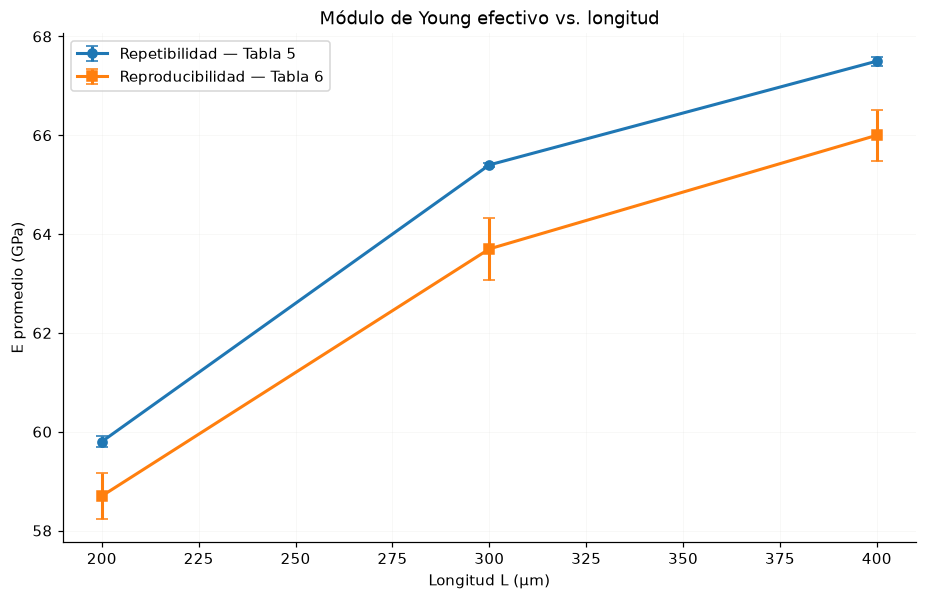

In [33]:
plt.figure(figsize=FIGSIZE)

plt.errorbar(
    repeatability["L_um"],
    repeatability["E_mean_GPa"],
    yerr=repeatability["se_GPa"],
    marker="o",
    capsize=4,
    label="Repetibilidad — Tabla 5",
)

plt.errorbar(
    reproducibility["L_um"],
    reproducibility["E_mean_GPa"],
    yerr=reproducibility["se_GPa"],
    marker="s",
    capsize=4,
    label="Reproducibilidad — Tabla 6",
)

plt.title("Módulo de Young efectivo vs. longitud")
plt.xlabel("Longitud L (µm)")
plt.ylabel("E promedio (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


En ambos conjuntos se observa la misma tendencia descriptiva: el módulo de Young efectivo aumenta con la longitud nominal del cantilever. El ajuste siguiente evalúa si esa tendencia es compatible con una corrección efectiva de longitud.

### Distribución de E por voladizo (24 puntos de la Fig. 6)

Los promedios de las Tablas 5 y 6 ocultan la dispersión entre voladizos. Con los 24 valores individuales de reproducibilidad (8 participantes × 3 longitudes), digitalizados de la Fig. 6 con un script reproducible, se puede ver la distribución de E en cada longitud.

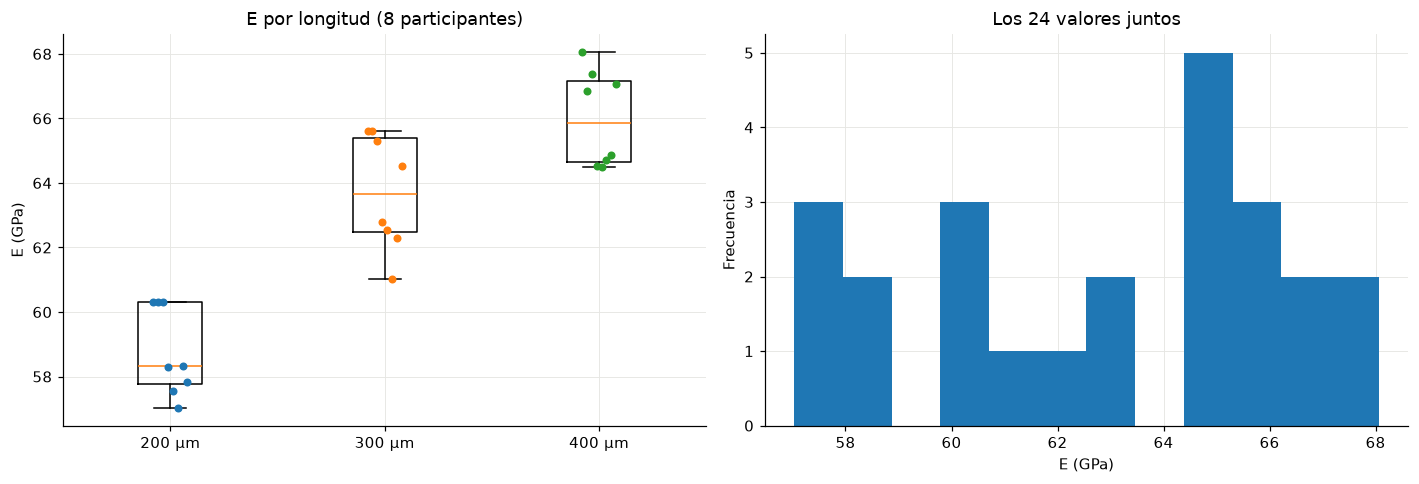

,n,media,desviacion,minimo,maximo,asimetría,media Tabla 6,desviación Tabla 6
L_um,,,,,,,,
200,8,58.7490,1.3620,57.0300,60.3200,0.2870,58.7000,1.2910
300,8,63.7160,1.7690,61.0200,65.6200,-0.2250,63.7000,1.7520
400,8,65.9960,1.4790,64.5100,68.0600,0.1920,66.0000,1.4520


Posibles atípicos por IQR dentro de cada longitud: 0


In [34]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
grupos = [fig6.loc[fig6["L_um"] == L, "E_GPa"] for L in (200, 300, 400)]
ejes[0].boxplot(grupos, tick_labels=["200 µm", "300 µm", "400 µm"])
for k, g in enumerate(grupos, start=1):
    ejes[0].scatter(np.full(len(g), k) + np.linspace(-0.08, 0.08, len(g)), g, s=18, zorder=3)
ejes[0].set_ylabel("E (GPa)")
ejes[0].set_title("E por longitud (8 participantes)")
ejes[1].hist(fig6["E_GPa"], bins=12)
ejes[1].set_xlabel("E (GPa)")
ejes[1].set_ylabel("Frecuencia")
ejes[1].set_title("Los 24 valores juntos")
fig.tight_layout()
plt.show()

resumen = fig6.groupby("L_um")["E_GPa"].agg(n="size", media="mean", desviacion="std", minimo="min", maximo="max")
resumen["asimetría"] = fig6.groupby("L_um")["E_GPa"].skew()
resumen["media Tabla 6"] = reproducibility.set_index("L_um")["E_mean_GPa"].values
resumen["desviación Tabla 6"] = reproducibility.set_index("L_um")["std_GPa"].values
display(resumen.round(3))

q1 = fig6.groupby("L_um")["E_GPa"].transform(lambda s: s.quantile(0.25))
q3 = fig6.groupby("L_um")["E_GPa"].transform(lambda s: s.quantile(0.75))
atipicos = fig6[(fig6["E_GPa"] < q1 - 1.5 * (q3 - q1)) | (fig6["E_GPa"] > q3 + 1.5 * (q3 - q1))]
print(f"Posibles atípicos por IQR dentro de cada longitud: {len(atipicos)}")

- La media y la desviación de cada longitud coinciden con la Tabla 6, lo que valida la digitalización.
- E **crece con la longitud**, y la dispersión dentro de cada longitud (≈1.4–1.8 GPa) es menor que el salto entre longitudes: la dependencia con L no es ruido.
- Con los 24 valores juntos la distribución mezcla longitudes distintas; por eso E se analiza por longitud.
- La regla IQR no marca ningún valor como atípico dentro de cada longitud.

## 2.3 Ajuste de la curva de anclaje

### Modelo

Se utiliza el modelo:

$$
E(L)=E_{\mathrm{real}}\left(\frac{L}{L+\Delta L}\right)^4,
$$

donde:

- $E_{\mathrm{real}}$ es el módulo de Young estimado del material;
- $\Delta L$ es una corrección efectiva de longitud asociada al comportamiento del anclaje;
- $L$ es la longitud nominal del cantilever.

La potencia cuatro está motivada por la ecuación de Marshall para un cantilever resonante:

$$
E=\frac{38.330\,\rho\,f_{\mathrm{can}}^2L_{\mathrm{can}}^4}{t^2}.
$$

El ajuste se realiza mediante mínimos cuadrados no lineales ponderados usando `scipy.optimize.least_squares`.

### Función de ajuste e intervalos de confianza

`fit_anchoring_curve` (en `src/pinn_mems/nist/brazo1.py`) ajusta el modelo con `scipy.optimize.least_squares`, ponderando con el error estándar (`se_GPa`) o con la desviación estándar (`std_GPa`). Devuelve los parámetros, sus IC 95 % aproximados por linealización local, los grados de libertad, el WRSS y la tabla de residuos. `print_fit_summary` imprime un resumen.

### Ajuste — repetibilidad (Tabla 5)

In [35]:
fit_repeatability = fit_anchoring_curve(repeatability, uncertainty="se_GPa")
print_fit_summary("Repetibilidad — Tabla 5", fit_repeatability)

Repetibilidad — Tabla 5
-----------------------
Ponderación = se_GPa
E_real = 77.1358 GPa (IC 95 % aprox.: 54.3406, 99.9311)
Delta L = 12.8180 µm (IC 95 % aprox.: -9.7856, 35.4215)
Grados de libertad = 1
WRSS = 53.9593
WRSS / df = 53.9593


#### Residuos — repetibilidad

In [36]:
display(fit_repeatability["residuals"])


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa,E_pred_GPa,residual_GPa,fit_sigma_GPa,standardized_residual
0,200.0000,16,59.8000,1.4000,0.4186,0.1046,60.1649,-0.3649,0.1046,-3.4868
1,300.0000,16,65.4000,0.5000,0.1635,0.0409,65.2491,0.1509,0.0409,3.6917
2,400.0000,16,67.5000,1.1000,0.3713,0.0928,67.9926,-0.4926,0.0928,-5.3079


#### Curva ajustada — repetibilidad

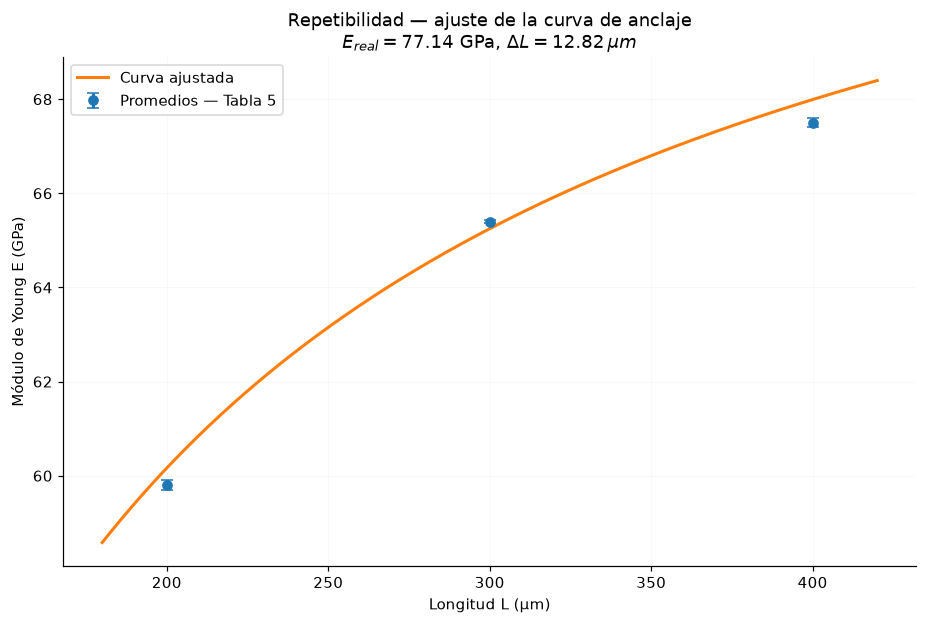

In [37]:
L_curve = np.linspace(180, 420, 400)

plt.figure(figsize=FIGSIZE)
plt.errorbar(
    repeatability["L_um"],
    repeatability["E_mean_GPa"],
    yerr=repeatability["se_GPa"],
    fmt="o",
    capsize=4,
    label="Promedios — Tabla 5",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_repeatability["E_real_GPa"],
        fit_repeatability["delta_L_um"],
    ),
    label="Curva ajustada",
)
plt.title(
    "Repetibilidad — ajuste de la curva de anclaje\n"
    rf"$E_{{real}}={fit_repeatability['E_real_GPa']:.2f}$ GPa, "
    rf"$\Delta L={fit_repeatability['delta_L_um']:.2f}\,\mu m$"
)
plt.xlabel("Longitud L (µm)")
plt.ylabel("Módulo de Young E (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Ajuste — reproducibilidad (Tabla 6)

In [38]:
fit_reproducibility = fit_anchoring_curve(reproducibility, uncertainty="se_GPa")
print_fit_summary("Reproducibilidad — Tabla 6", fit_reproducibility)

Reproducibilidad — Tabla 6
--------------------------
Ponderación = se_GPa
E_real = 74.6107 GPa (IC 95 % aprox.: 68.8670, 80.3545)
Delta L = 12.3252 µm (IC 95 % aprox.: 7.0112, 17.6391)
Grados de libertad = 1
WRSS = 0.1239
WRSS / df = 0.1239


#### Residuos — reproducibilidad

In [39]:
display(fit_reproducibility["residuals"])


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa,E_pred_GPa,residual_GPa,fit_sigma_GPa,standardized_residual
0,200.0000,8,58.7000,4.4000,1.2914,0.4566,58.7375,-0.0375,0.4566,-0.0821
1,300.0000,8,63.7000,5.5000,1.7518,0.6193,63.5124,0.1876,0.6193,0.3030
2,400.0000,8,66.0000,4.4000,1.4520,0.5134,66.0818,-0.0818,0.5134,-0.1593


#### Curva ajustada — reproducibilidad

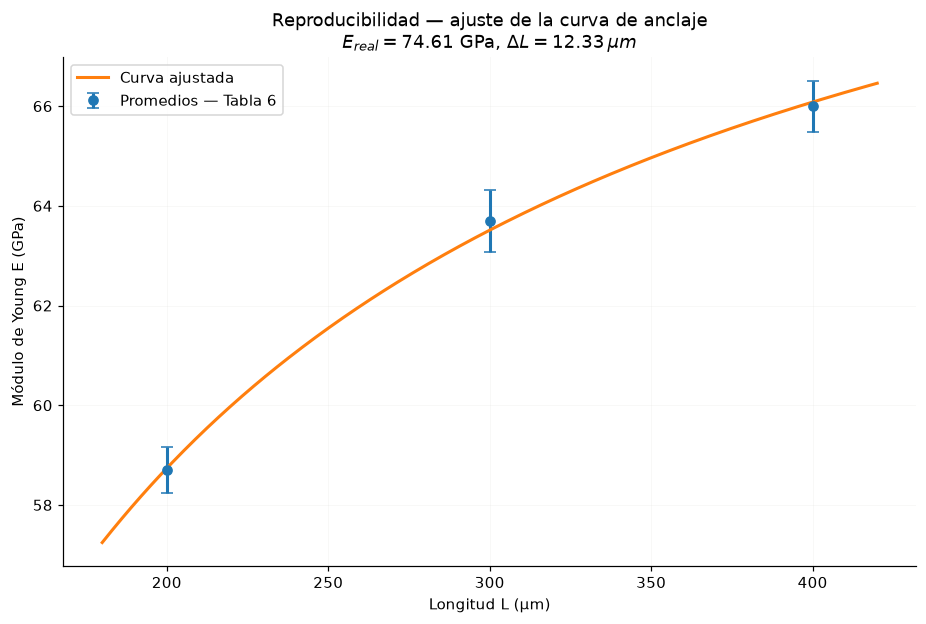

In [40]:
plt.figure(figsize=FIGSIZE)
plt.errorbar(
    reproducibility["L_um"],
    reproducibility["E_mean_GPa"],
    yerr=reproducibility["se_GPa"],
    fmt="o",
    capsize=4,
    label="Promedios — Tabla 6",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_reproducibility["E_real_GPa"],
        fit_reproducibility["delta_L_um"],
    ),
    label="Curva ajustada",
)
plt.title(
    "Reproducibilidad — ajuste de la curva de anclaje\n"
    rf"$E_{{real}}={fit_reproducibility['E_real_GPa']:.2f}$ GPa, "
    rf"$\Delta L={fit_reproducibility['delta_L_um']:.2f}\,\mu m$"
)
plt.xlabel("Longitud L (µm)")
plt.ylabel("Módulo de Young E (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Comparación de los dos ajustes

In [41]:
fit_summary = pd.DataFrame([
    {
        "dataset": "Repetibilidad — Tabla 5",
        "E_real_GPa": fit_repeatability["E_real_GPa"],
        "E_real_CI95_low": fit_repeatability["E_real_ci95"][0],
        "E_real_CI95_high": fit_repeatability["E_real_ci95"][1],
        "delta_L_um": fit_repeatability["delta_L_um"],
        "delta_L_CI95_low": fit_repeatability["delta_L_ci95"][0],
        "delta_L_CI95_high": fit_repeatability["delta_L_ci95"][1],
        "dof": fit_repeatability["dof"],
        "weighted_rss": fit_repeatability["weighted_rss"],
        "weighted_rss_per_df": fit_repeatability["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad — Tabla 6",
        "E_real_GPa": fit_reproducibility["E_real_GPa"],
        "E_real_CI95_low": fit_reproducibility["E_real_ci95"][0],
        "E_real_CI95_high": fit_reproducibility["E_real_ci95"][1],
        "delta_L_um": fit_reproducibility["delta_L_um"],
        "delta_L_CI95_low": fit_reproducibility["delta_L_ci95"][0],
        "delta_L_CI95_high": fit_reproducibility["delta_L_ci95"][1],
        "dof": fit_reproducibility["dof"],
        "weighted_rss": fit_reproducibility["weighted_rss"],
        "weighted_rss_per_df": fit_reproducibility["wrss_per_df"],
    },
])

display(fit_summary)


,dataset,E_real_GPa,E_real_CI95_low,E_real_CI95_high,delta_L_um,delta_L_CI95_low,delta_L_CI95_high,dof,weighted_rss,weighted_rss_per_df
0,Repetibilidad — Tabla 5,77.1358,54.3406,99.9311,12.8180,-9.7856,35.4215,1,53.9593,53.9593
1,Reproducibilidad — Tabla 6,74.6107,68.8670,80.3545,12.3252,7.0112,17.6391,1,0.1239,0.1239


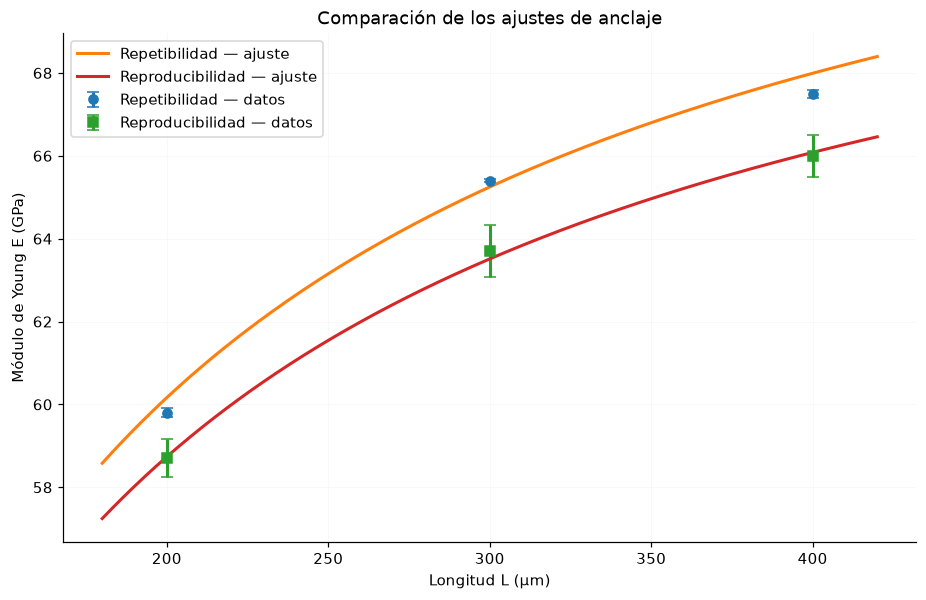

In [42]:
plt.figure(figsize=FIGSIZE)

plt.errorbar(
    repeatability["L_um"],
    repeatability["E_mean_GPa"],
    yerr=repeatability["se_GPa"],
    fmt="o",
    capsize=4,
    label="Repetibilidad — datos",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_repeatability["E_real_GPa"],
        fit_repeatability["delta_L_um"],
    ),
    label="Repetibilidad — ajuste",
)

plt.errorbar(
    reproducibility["L_um"],
    reproducibility["E_mean_GPa"],
    yerr=reproducibility["se_GPa"],
    fmt="s",
    capsize=4,
    label="Reproducibilidad — datos",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_reproducibility["E_real_GPa"],
        fit_reproducibility["delta_L_um"],
    ),
    label="Reproducibilidad — ajuste",
)

plt.title("Comparación de los ajustes de anclaje")
plt.xlabel("Longitud L (µm)")
plt.ylabel("Módulo de Young E (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Interpretación del ajuste

Los dos conjuntos producen estimaciones centrales muy similares de la corrección efectiva de longitud: aproximadamente $12\text{ a }13\,\mu\mathrm{m}$. Como referencia de control, el ajuste exploratorio previo reportó valores del orden de $\Delta L\approx 12\text{ a }13\,\mu\mathrm{m}$ y $E_{\mathrm{real}}\approx75\text{ a }77\,\mathrm{GPa}$. Esa referencia se utiliza únicamente como comparación y **no se impone como restricción al optimizador**.

Sin embargo, la similitud de los parámetros no implica que la calidad del ajuste sea igual en ambos conjuntos. Con la ponderación principal basada en el error estándar, la repetibilidad presenta discrepancias grandes respecto a la pequeña incertidumbre estadística de sus medias, mientras que la reproducibilidad queda mucho más cerca de la curva en unidades de su incertidumbre.

Los intervalos mostrados son **IC 95 % aproximados por linealización local**, obtenidos a partir del Jacobiano y una distribución t de Student. Con solo un grado de libertad, $t_{0.975,1}\approx12.706$, por lo que estos intervalos son muy sensibles y no deben interpretarse como una caracterización precisa de la incertidumbre paramétrica.

> **Sobre el IC negativo de $\Delta L$ en repetibilidad.** El optimizador impone $\Delta L\ge 0$. El límite inferior negativo puede aparecer después porque el IC aproximado se construye de forma simétrica alrededor del estimador y no incorpora el `bound` del optimizador. No significa que el ajuste haya estimado una longitud efectiva negativa.

### Análisis multivariante: longitud, chip e instrumento

Los 24 puntos permiten estudiar a la vez la longitud, el chip y el instrumento. Primero, E contra L para cada participante, coloreado por chip; después, el ajuste de la curva de anclaje con un factor por chip.

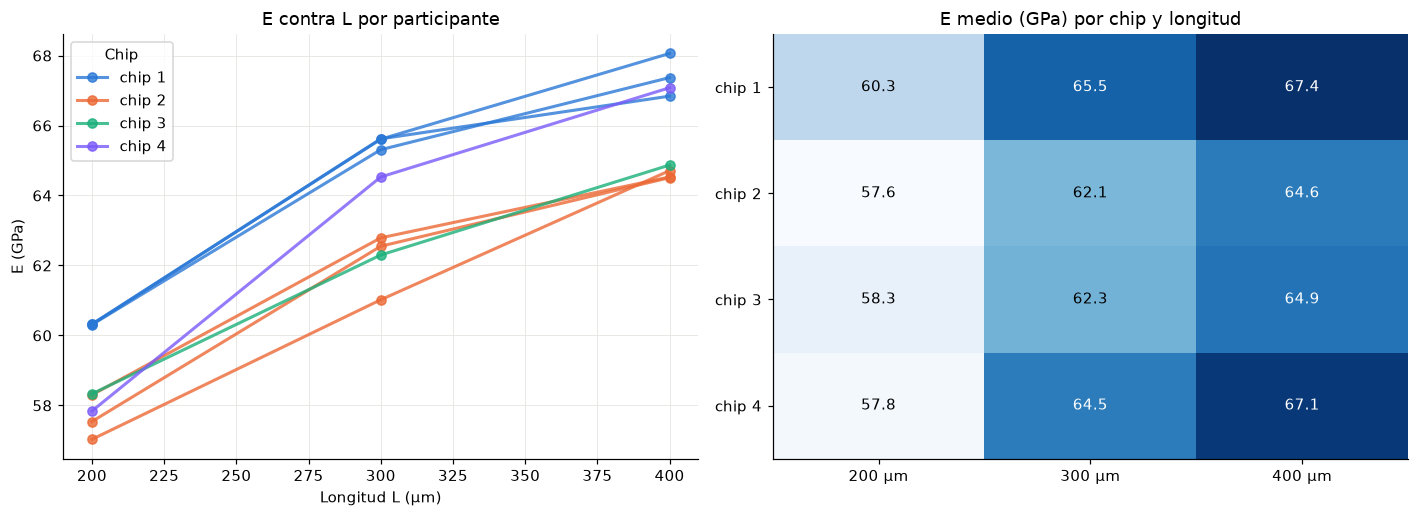

,E_real (GPa),ΔL (µm),IC 95 % de ΔL,grados de libertad
ajuste,,,,
3 promedios (Tabla 6),74.6100,12.3300,7.0 a 17.6,1
24 puntos + factor por chip,74.4400,12.2300,11.1 a 13.3,19


Factor por chip: {'chip 1': 1.027, 'chip 2': 0.98, 'chip 3': 0.986, 'chip 4': 1.008}
Desviación residual: 0.61 GPa


In [43]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.8))
chips = sorted(fig6["chip"].unique())
colores_chip = dict(zip(chips, ["#2a78d6", "#eb6834", "#1baf7a", "#7a5af8"]))
for chip in chips:
    for k, (_, g) in enumerate(fig6[fig6["chip"] == chip].groupby("participant")):
        ejes[0].plot(g["L_um"], g["E_GPa"], "o-", color=colores_chip[chip], alpha=0.8, label=chip if k == 0 else None)
ejes[0].set_xlabel("Longitud L (µm)")
ejes[0].set_ylabel("E (GPa)")
ejes[0].set_title("E contra L por participante")
ejes[0].legend(title="Chip")

pivote = fig6.pivot_table(index="chip", columns="L_um", values="E_GPa", aggfunc="mean")
ejes[1].imshow(pivote.values, cmap="Blues", aspect="auto")
ejes[1].set_xticks(range(3), [f"{L} µm" for L in pivote.columns])
ejes[1].set_yticks(range(len(pivote)), pivote.index)
for (i, j), v in np.ndenumerate(pivote.values):
    ejes[1].text(j, i, f"{v:.1f}", ha="center", va="center", color="white" if v > 63 else "black")
ejes[1].set_title("E medio (GPa) por chip y longitud")
ejes[1].grid(False)
fig.tight_layout()
plt.show()

con_chip = fit_anchoring_curve_with_chip(fig6)
tres = fit_anchoring_curve(reproducibility)
display(pd.DataFrame([
    {"ajuste": "3 promedios (Tabla 6)", "E_real (GPa)": tres["E_real_GPa"], "ΔL (µm)": tres["delta_L_um"],
     "IC 95 % de ΔL": "{:.1f} a {:.1f}".format(*tres["delta_L_ci95"]), "grados de libertad": tres["dof"]},
    {"ajuste": "24 puntos + factor por chip", "E_real (GPa)": con_chip["E_real_GPa"], "ΔL (µm)": con_chip["delta_L_um"],
     "IC 95 % de ΔL": "{:.1f} a {:.1f}".format(*con_chip["delta_L_ci95"]), "grados de libertad": con_chip["dof"]},
]).set_index("ajuste").round(2))
print("Factor por chip:", {k: round(float(v), 3) for k, v in con_chip["chip_factors"].items()})
print(f"Desviación residual: {con_chip['residual_sd_GPa']:.2f} GPa")

- **Los ocho participantes muestran la misma tendencia:** E crece con L. La curva de anclaje no depende de un laboratorio en particular.
- **El chip explica buena parte de la dispersión entre laboratorios:** el chip 1 da valores ≈2.7 % más altos que el promedio y el chip 2, ≈2 % más bajos. Con un factor por chip, la dispersión que queda baja de ≈1.5 a ≈0.6 GPa.
- **ΔL se vuelve mucho más preciso:** con 24 puntos y 19 grados de libertad, ΔL = 12.2 µm con un intervalo del 95 % de 11.1 a 13.3 µm, contra 7.0 a 17.6 µm con los tres promedios. El valor central casi no cambia.

## 2.4 Diagnóstico de residuos

In [44]:
residual_comparison = pd.concat([
    fit_repeatability["residuals"].assign(dataset="Repetibilidad"),
    fit_reproducibility["residuals"].assign(dataset="Reproducibilidad"),
], ignore_index=True)

display(residual_comparison)


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa,E_pred_GPa,residual_GPa,fit_sigma_GPa,standardized_residual,dataset
0,200.0000,16,59.8000,1.4000,0.4186,0.1046,60.1649,-0.3649,0.1046,-3.4868,Repetibilidad
1,300.0000,16,65.4000,0.5000,0.1635,0.0409,65.2491,0.1509,0.0409,3.6917,Repetibilidad
2,400.0000,16,67.5000,1.1000,0.3713,0.0928,67.9926,-0.4926,0.0928,-5.3079,Repetibilidad
3,200.0000,8,58.7000,4.4000,1.2914,0.4566,58.7375,-0.0375,0.4566,-0.0821,Reproducibilidad
4,300.0000,8,63.7000,5.5000,1.7518,0.6193,63.5124,0.1876,0.6193,0.3030,Reproducibilidad
5,400.0000,8,66.0000,4.4000,1.4520,0.5134,66.0818,-0.0818,0.5134,-0.1593,Reproducibilidad


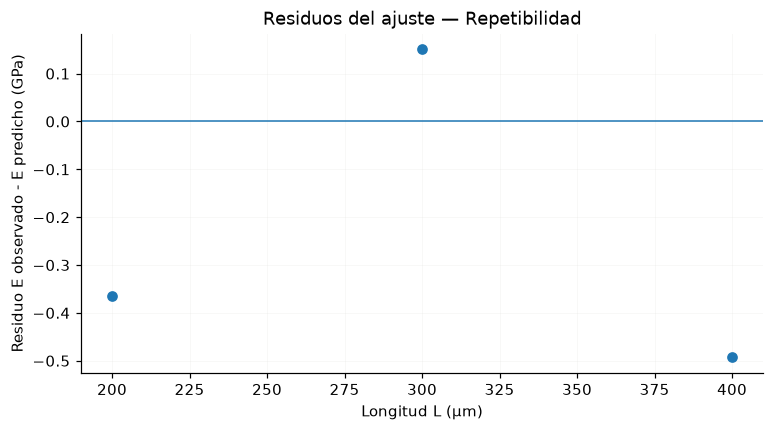

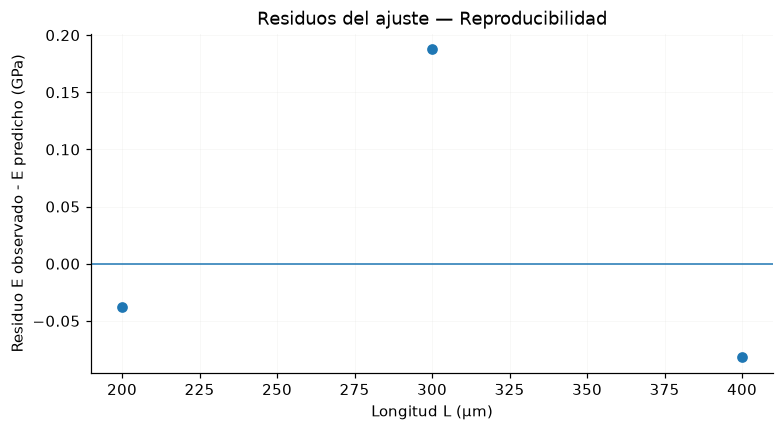

In [45]:
for dataset, group in residual_comparison.groupby("dataset"):
    plt.figure(figsize=(8, 4))
    plt.axhline(0, linewidth=1)
    plt.scatter(group["L_um"], group["residual_GPa"])
    plt.title(f"Residuos del ajuste — {dataset}")
    plt.xlabel("Longitud L (µm)")
    plt.ylabel("Residuo E observado - E predicho (GPa)")
    plt.grid(alpha=0.3)
    plt.show()


### Residuos estandarizados

Además del residuo en GPa, conviene inspeccionar el residuo dividido por la incertidumbre utilizada en el ajuste:

$$
r_i^{*}=\frac{E_{i,\mathrm{obs}}-E_{i,\mathrm{pred}}}{\sigma_i}.
$$

Con la ponderación principal, $\sigma_i=SE_i$. Las líneas $\pm2$ se muestran solo como referencia visual; con tres observaciones y un grado de libertad **no constituyen un test formal de adecuación del modelo**.

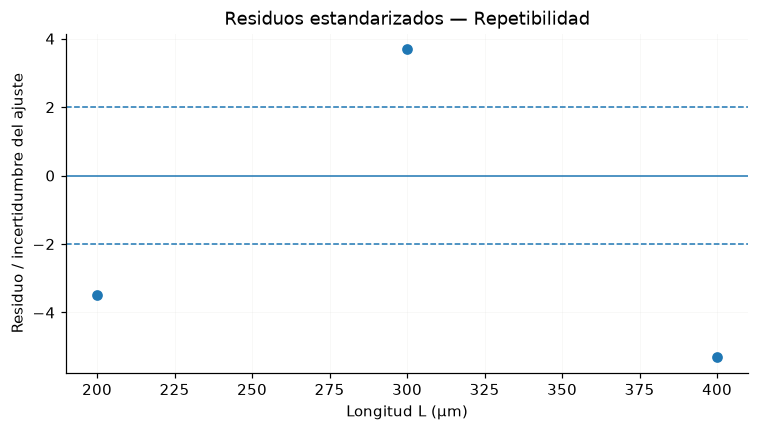

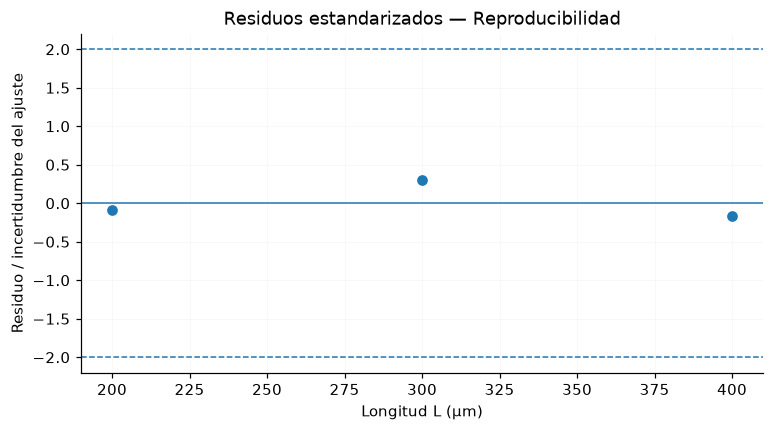

In [46]:
for dataset, group in residual_comparison.groupby("dataset"):
    plt.figure(figsize=(8, 4))
    plt.axhline(0, linewidth=1)
    plt.axhline(2, linestyle="--", linewidth=1)
    plt.axhline(-2, linestyle="--", linewidth=1)
    plt.scatter(group["L_um"], group["standardized_residual"])
    plt.title(f"Residuos estandarizados — {dataset}")
    plt.xlabel("Longitud L (µm)")
    plt.ylabel("Residuo / incertidumbre del ajuste")
    plt.grid(alpha=0.3)
    plt.show()

### Lectura de los residuos

- **Repetibilidad:** la curva captura la tendencia creciente de $E$ con $L$, pero los residuos estandarizados son grandes respecto a los errores estándar de los promedios. Por tanto, el modelo de dos parámetros no reproduce los tres promedios dentro de esa escala de incertidumbre tan pequeña.
- **Reproducibilidad:** los residuos estandarizados son mucho menores; la curva es compatible con los tres promedios a la escala de incertidumbre utilizada.

Esta diferencia es relevante: la estabilidad de $\Delta L$ entre ambos experimentos es una observación útil, pero **no debe confundirse con evidencia de un ajuste igualmente bueno en repetibilidad y reproducibilidad**.

### Limitación del diagnóstico

Con solo tres observaciones por ajuste no es posible realizar un diagnóstico de residuos robusto ni evaluar de forma fiable normalidad, heterocedasticidad o estructura sistemática. Los residuos se reportan porque permiten inspeccionar la discrepancia puntual entre el modelo y cada promedio, no porque constituyan una muestra suficiente para validar estadísticamente el modelo.

## 2.5 Análisis de sensibilidad: ponderación con SE vs. SD

El análisis principal usa $SE=s/\sqrt{n}$, tal como pide la consigna. Como comprobación metodológica, se repite el ajuste usando directamente la desviación estándar $s$.

Esto permite separar dos preguntas:

1. **¿Cambia la estimación de $E_{\mathrm{real}}$ o $\Delta L$?**
2. **¿Cambia la lectura del tamaño de los residuos respecto a la dispersión experimental?**

Como $n$ es constante entre las tres longitudes dentro de cada tabla, cambiar de SE a SD solo reescala todos los pesos de ese ajuste por una misma constante. Por ello, los parámetros óptimos deben permanecer prácticamente iguales; lo que cambia es la escala del WRSS y de los residuos estandarizados.

In [47]:
fit_repeatability_sd = fit_anchoring_curve(repeatability, uncertainty="std_GPa")
fit_reproducibility_sd = fit_anchoring_curve(reproducibility, uncertainty="std_GPa")

sensitivity = pd.DataFrame([
    {
        "dataset": "Repetibilidad",
        "ponderacion": "SE",
        "E_real_GPa": fit_repeatability["E_real_GPa"],
        "delta_L_um": fit_repeatability["delta_L_um"],
        "WRSS": fit_repeatability["weighted_rss"],
        "WRSS_per_df": fit_repeatability["wrss_per_df"],
    },
    {
        "dataset": "Repetibilidad",
        "ponderacion": "SD",
        "E_real_GPa": fit_repeatability_sd["E_real_GPa"],
        "delta_L_um": fit_repeatability_sd["delta_L_um"],
        "WRSS": fit_repeatability_sd["weighted_rss"],
        "WRSS_per_df": fit_repeatability_sd["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad",
        "ponderacion": "SE",
        "E_real_GPa": fit_reproducibility["E_real_GPa"],
        "delta_L_um": fit_reproducibility["delta_L_um"],
        "WRSS": fit_reproducibility["weighted_rss"],
        "WRSS_per_df": fit_reproducibility["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad",
        "ponderacion": "SD",
        "E_real_GPa": fit_reproducibility_sd["E_real_GPa"],
        "delta_L_um": fit_reproducibility_sd["delta_L_um"],
        "WRSS": fit_reproducibility_sd["weighted_rss"],
        "WRSS_per_df": fit_reproducibility_sd["wrss_per_df"],
    },
])

display(sensitivity)

,dataset,ponderacion,E_real_GPa,delta_L_um,WRSS,WRSS_per_df
0,Repetibilidad,SE,77.1358,12.8180,53.9593,53.9593
1,Repetibilidad,SD,77.1358,12.8180,3.3725,3.3725
2,Reproducibilidad,SE,74.6107,12.3252,0.1239,0.1239
3,Reproducibilidad,SD,74.6107,12.3252,0.0155,0.0155


### Interpretación de la sensibilidad

Si los valores de $E_{\mathrm{real}}$ y $\Delta L$ coinciden entre SE y SD, no es una coincidencia: dentro de cada tabla todas las longitudes tienen el mismo $n$, de modo que el cambio de ponderación es un reescalamiento uniforme.

El análisis principal se conserva con **SE**, porque es el procedimiento solicitado. El ajuste con **SD** se reporta únicamente como sensibilidad para mostrar que la estimación central de $\Delta L$ no depende de ese reescalamiento, aunque la interpretación del tamaño de los residuos sí cambia.

## 2.6 Grados de libertad e identificabilidad

In [48]:
n_observations = len(repeatability)
n_parameters = 2
degrees_of_freedom = n_observations - n_parameters

print(f"Observaciones por ajuste: {n_observations}")
print(f"Parámetros estimados: {n_parameters}")
print(f"Grados de libertad: {degrees_of_freedom}")
print(f"t crítico (95 %, df=1): {t.ppf(0.975, df=degrees_of_freedom):.4f}")


Observaciones por ajuste: 3
Parámetros estimados: 2
Grados de libertad: 1
t crítico (95 %, df=1): 12.7062


Cada ajuste utiliza tres longitudes experimentales y estima dos parámetros:

$$
\nu=n-p=3-2=1.
$$

Por tanto, queda **un solo grado de libertad**. Esta es una limitación central del Brazo 1.

El ajuste puede estimar una magnitud efectiva de $\Delta L$ y comprobar si la tendencia observada es compatible con el modelo propuesto. Sin embargo, **no permite demostrar que el anclaje sea la causa única de la dependencia con la longitud ni distinguir de manera sólida esta curva de otras curvas monótonas con dos parámetros**.

## 2.7 Utilidad posterior: reconstrucción de frecuencia a partir de E

Para etapas posteriores puede reconstruirse la frecuencia a partir del módulo de Young utilizando la Ec. 7 de Marshall:

$$
E=\frac{38.330\rho f^2L^4}{t^2},
$$

de donde

$$
f=\sqrt{\frac{Et^2}{38.330\rho L^4}}.
$$

Esta operación **no interviene en la estimación de $\Delta L$ presentada en este notebook**. Se conserva como utilidad para transformar posteriormente el observable $E$ a frecuencia usando la geometría nominal de la Tabla 1 y unidades coherentes.

La función `frequency_from_young_modulus` (en `src/pinn_mems/nist/brazo1.py`) implementa este despeje.

## 2.8 Comparación exploratoria de escala con NIST SP 260-177

La comparación se realiza con la **Tabla 3 de SP 260-177 (RM 8096)**. No se modifica ningún dato de Marshall con `f_correction`.

NIST toma el cantilever de **300 µm como referencia**, por lo que `f_correction = 0` en esa longitud. Para poner nuestro parámetro $\Delta L$ en una escala comparable, se construye un **desplazamiento equivalente de frecuencia relativo a 300 µm**.

De la Ec. 7 de Marshall, $E\propto f^2L^4$. Bajo el modelo de longitud efectiva, el factor asociado es

$$
g(L;\Delta L)=\left(\frac{L+\Delta L}{L}\right)^2.
$$

Tomando 300 µm como referencia:

$$
R(L)=\frac{g(L;\Delta L)}{g(300;\Delta L)},
$$

y usando la frecuencia de diseño de la Tabla 2 **solo como escala**:

$$
\Delta f_{\mathrm{eq}}(L)=f_{\mathrm{design}}(L)[R(L)-1].
$$

Esta transformación es una **comprobación exploratoria de escala y tendencia**. No constituye una validación independiente del modelo: $\Delta L$ fue estimado precisamente a partir de la dependencia de $E$ con $L$, y la conversión posterior usa la misma relación física entre $E$, $f$ y $L$. Además, las frecuencias de diseño se emplean como escala y no como frecuencias medidas del *round robin*.

Por tanto, la comparación permite preguntar si el signo y el orden de magnitud son compatibles con `f_correction`, pero **no demuestra que el anclaje sea el mecanismo causal**.

In [49]:
# Frecuencias de diseño para las tres longitudes usadas por SP 260-177.
f_design = (
    table2.rename(columns={"L µm": "L_um", "f inicial kHz": "f_design_kHz"})
    [["L_um", "f_design_kHz"]]
    .query("L_um in [200, 300, 400]")
    .copy()
)

sp_compare = (
    sp260_table3.rename(columns={
        "L (µm)": "L_um",
        "f_correction (kHz)": "f_correction_NIST_kHz",
        "sigma_support (kHz)": "sigma_support_NIST_kHz",
        "sigma_cantilever (kHz)": "sigma_cantilever_NIST_kHz",
    })
    .merge(f_design, on="L_um", how="left")
)

for label, fit in [
    ("repeatability", fit_repeatability),
    ("reproducibility", fit_reproducibility),
]:
    sp_compare[f"f_equiv_{label}_kHz"] = equivalent_frequency_correction(
        sp_compare["L_um"],
        sp_compare["f_design_kHz"],
        fit["delta_L_um"],
    )
    sp_compare[f"error_{label}_kHz"] = (
        sp_compare[f"f_equiv_{label}_kHz"]
        - sp_compare["f_correction_NIST_kHz"]
    )

display(sp_compare.round(4))

,L_um,f_correction_NIST_kHz,sigma_support_NIST_kHz,sigma_cantilever_NIST_kHz,f_design_kHz,f_equiv_repeatability_kHz,error_repeatability_kHz,f_equiv_reproducibility_kHz,error_reproducibility_kHz
0,200,2.6700,0.6300,0.6300,62.5000,2.5872,-0.0828,2.4907,-0.1793
1,300,0.0000,0.0000,0.0000,27.8000,0.0000,0.0000,0.0000,0.0000
2,400,-0.2400,0.0570,0.0570,15.6000,-0.3180,-0.0780,-0.3063,-0.0663


### Lectura de la comparación

La comparación relevante es el **patrón por longitud** y el orden de magnitud. No se compara directamente $\Delta L$ (µm) con `sigma_support` (kHz), porque son magnitudes físicas diferentes.

Con 300 µm como referencia, se espera observar:

1. una corrección positiva y mayor para 200 µm;
2. cero por construcción en 300 µm;
3. una corrección pequeña y negativa para 400 µm.

La proximidad entre $\Delta f_{\mathrm{eq}}$ y `f_correction` se interpreta únicamente como **consistencia exploratoria de escala y tendencia**. No es evidencia independiente ni permite identificar causalmente el anclaje.

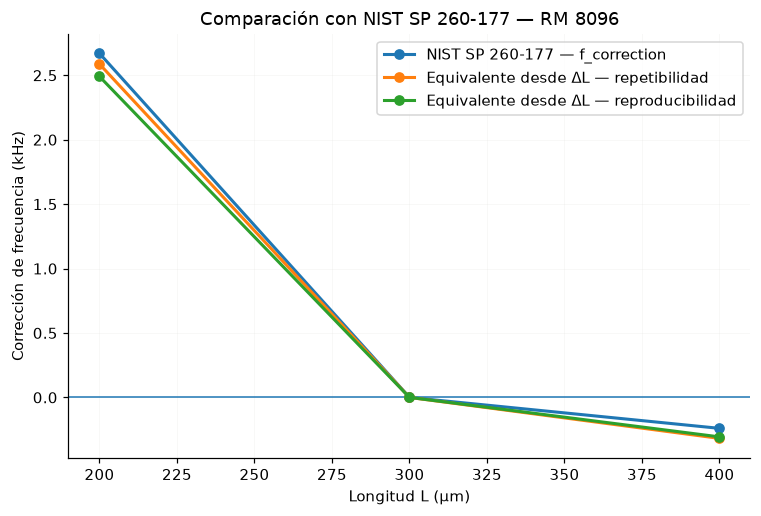

In [50]:
plt.figure(figsize=(8, 5))
plt.axhline(0, linewidth=1)
plt.plot(
    sp_compare["L_um"], sp_compare["f_correction_NIST_kHz"],
    marker="o", label="NIST SP 260-177 — f_correction"
)
plt.plot(
    sp_compare["L_um"], sp_compare["f_equiv_repeatability_kHz"],
    marker="o", label="Equivalente desde ΔL — repetibilidad"
)
plt.plot(
    sp_compare["L_um"], sp_compare["f_equiv_reproducibility_kHz"],
    marker="o", label="Equivalente desde ΔL — reproducibilidad"
)
plt.xlabel("Longitud L (µm)")
plt.ylabel("Corrección de frecuencia (kHz)")
plt.title("Comparación con NIST SP 260-177 — RM 8096")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [51]:
# Métrica descriptiva de proximidad; no es una prueba de validación estadística.
for label in ["repeatability", "reproducibility"]:
    error = sp_compare[f"error_{label}_kHz"].to_numpy(dtype=float)
    rmse = np.sqrt(np.mean(error**2))
    print(f"{label}: RMSE descriptivo frente a f_correction = {rmse:.4f} kHz")


repeatability: RMSE descriptivo frente a f_correction = 0.0657 kHz
reproducibility: RMSE descriptivo frente a f_correction = 0.1103 kHz


### `sigma_support`

`sigma_support` se conserva como referencia del presupuesto de incertidumbre asociado a soporte no ideal. En la Tabla 3 satisface aproximadamente

$$
\sigma_{\mathrm{support}}=\frac{|f_{\mathrm{correction}}|}{3\sqrt{2}}.
$$

Conviene mantener separados los conceptos:

$$
\sigma_{\mathrm{support}}\neq \Delta L,
\qquad
\sigma_{\mathrm{support}}\neq f_{\mathrm{correction}}.
$$

`f_correction` es una corrección empírica de frecuencia; `sigma_support` es una componente de incertidumbre en frecuencia asociada al soporte. Por ello **no se ajusta $\Delta L$ contra `sigma_support` ni se interpreta que $\Delta L$ la prediga**.

La Tabla 4 de SP 260-177 no se incorpora al análisis cuantitativo porque corresponde a RM 8097 (poly1/poly2), mientras que esta comparación se limita al sistema RM 8096 de óxido.

### Comparación con el ajuste exploratorio

Como control de consistencia, el análisis exploratorio esperaba aproximadamente $\Delta L\approx12\text{ a }13\,\mu\mathrm{m}$ y $E_{\mathrm{real}}\approx75\text{ a }77\,\mathrm{GPa}$. Los dos ajustes independientes quedan en ese entorno. La diferencia entre sus estimaciones de $\Delta L$ se cuantifica a continuación.

In [52]:
delta_difference = abs(
    fit_repeatability["delta_L_um"] - fit_reproducibility["delta_L_um"]
)
delta_mean = np.mean([
    fit_repeatability["delta_L_um"], fit_reproducibility["delta_L_um"]
])
relative_difference = 100 * delta_difference / delta_mean

exploratory_comparison = pd.DataFrame([
    {"resultado": "Exploratorio", "delta_L_um": "~12–13", "E_real_GPa": "~75–77"},
    {"resultado": "Repetibilidad", "delta_L_um": fit_repeatability["delta_L_um"], "E_real_GPa": fit_repeatability["E_real_GPa"]},
    {"resultado": "Reproducibilidad", "delta_L_um": fit_reproducibility["delta_L_um"], "E_real_GPa": fit_reproducibility["E_real_GPa"]},
])
display(exploratory_comparison)
print(f"Diferencia absoluta entre ΔL: {delta_difference:.3f} µm")
print(f"Diferencia relativa entre ΔL: {relative_difference:.2f} %")

,resultado,delta_L_um,E_real_GPa
0,Exploratorio,~12–13,~75–77
1,Repetibilidad,12.8180,77.1358
2,Reproducibilidad,12.3252,74.6107


Diferencia absoluta entre ΔL: 0.493 µm
Diferencia relativa entre ΔL: 3.92 %


### Comparación con Kobrinsky et al. (2000)

El plan identifica a Kobrinsky, Deutsch y Senturia (2000) como una fuente independiente para obtener rigideces rotacional y traslacional del soporte ($k_\theta$ y $k_u$) y, posteriormente, convertirlas a una longitud efectiva equivalente.

La documentación disponible del proyecto contiene la referencia y el procedimiento propuesto, pero **no contiene los valores numéricos** de esas rigideces. Como la fuente primaria no está disponible en este análisis, no se infieren ni reconstruyen valores de Kobrinsky.

Esta comparación queda, por tanto, **no evaluada por falta de datos verificables**. Si la fuente primaria se obtiene posteriormente, la comparación deberá hacerse por **orden de magnitud**, no por igualdad directa, porque Kobrinsky et al. estudian polisilicio y una geometría distinta del sistema de óxido de Marshall/NIST.

## 2.9 Aspectos que no aplican o no son identificables con estas tablas

### Digitalización de los 48 puntos de repetibilidad

No es necesaria para el ajuste principal. Si el modelo depende únicamente de la longitud, los promedios y las desviaciones por longitud contienen la información necesaria para el ajuste solicitado.

### Efecto individual del chip

No puede separarse con las Tablas 5 y 6 agregadas. Para estudiarlo se requeriría el paso opcional de digitalizar los 24 puntos de reproducibilidad de la Fig. 6 e incorporar participante, chip e instrumento.

### Selección entre múltiples formas funcionales

Con tres longitudes y dos parámetros no existe información suficiente para realizar una selección convincente entre el modelo de anclaje propuesto y otras curvas monótonas flexibles.

### Naturaleza débilmente supervisada del Brazo 1

Cada voladizo aporta únicamente una frecuencia fundamental ($\omega_1$); no se dispone de múltiples modos por estructura ni de información espacial de deformación. Por ello, el Brazo 1 debe considerarse **débilmente supervisado**. El ajuste cuantifica una magnitud efectiva de discrepancia dependiente de la longitud, pero por sí solo no identifica de forma única el mecanismo físico.

## 2.10 Veredicto para la bitácora de decisiones

In [53]:
verdict = pd.DataFrame([
    {
        "dataset": "Repetibilidad — Tabla 5",
        "delta_L_um": fit_repeatability["delta_L_um"],
        "delta_L_CI95": fit_repeatability["delta_L_ci95"],
        "E_real_GPa": fit_repeatability["E_real_GPa"],
        "E_real_CI95": fit_repeatability["E_real_ci95"],
        "degrees_of_freedom": fit_repeatability["dof"],
        "WRSS_per_df": fit_repeatability["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad — Tabla 6",
        "delta_L_um": fit_reproducibility["delta_L_um"],
        "delta_L_CI95": fit_reproducibility["delta_L_ci95"],
        "E_real_GPa": fit_reproducibility["E_real_GPa"],
        "E_real_CI95": fit_reproducibility["E_real_ci95"],
        "degrees_of_freedom": fit_reproducibility["dof"],
        "WRSS_per_df": fit_reproducibility["wrss_per_df"],
    },
])

display(verdict)


,dataset,delta_L_um,delta_L_CI95,E_real_GPa,E_real_CI95,degrees_of_freedom,WRSS_per_df
0,Repetibilidad — Tabla 5,12.8180,"(-9.785561141511376, 35.421486872169595)",77.1358,"(54.34064388534072, 99.9310537396768)",1,53.9593
1,Reproducibilidad — Tabla 6,12.3252,"(7.011230508852696, 17.639083159244663)",74.6107,"(68.86695511303014, 80.35445346822544)",1,0.1239


### Interpretación final del ajuste

Los datos de repetibilidad y reproducibilidad muestran una dependencia monótona del módulo de Young efectivo con la longitud. Los ajustes independientes producen $\Delta L$ del orden de 12–13 µm y $E_{\mathrm{real}}$ del orden de 75–77 GPa.

La transformación exploratoria de $\Delta L$ a una escala equivalente de frecuencia, tomando 300 µm como referencia, reproduce el signo y un orden de magnitud similar al `f_correction` de la Tabla 3 de RM 8096. Esta comparación se interpreta como una **comprobación de consistencia de escala y tendencia**, no como validación independiente ni como identificación causal del mecanismo de anclaje. `sigma_support` se conserva únicamente como referencia de incertidumbre y `f_correction` no se aplica a los datos de Marshall.

La tendencia es **consistente** con una interpretación basada en condiciones de anclaje, pero no constituye identificación causal. Cada ajuste utiliza tres longitudes y dos parámetros, por lo que dispone de **un solo grado de libertad**. Los IC del 95 % son aproximaciones por linealización local y deben interpretarse con cautela. Además, repetibilidad presenta residuos grandes respecto a su pequeño error estándar, mientras que reproducibilidad queda mucho más cerca de la curva.

La comparación cuantitativa con Kobrinsky et al. (2000) **no se realiza** porque la documentación disponible no contiene los valores numéricos de rigidez del soporte y la fuente primaria no está disponible. No se introducen valores secundarios no verificados.

## 2.11 Conclusiones

El análisis deja reproducible el flujo principal del Brazo 1 a partir de las transcripciones de Marshall y la Tabla 3 de SP 260-177. Las transcripciones permanecen sin modificar y las transformaciones —selección de longitudes, reconstrucción de desviaciones estándar, cálculo de errores estándar y ajuste no lineal— se realizan dentro del notebook.

Las Tablas 5 y 6 presentan la misma tendencia cualitativa: los cantilevers más cortos producen valores efectivos menores de $E$. Los dos ajustes producen estimaciones notablemente consistentes de la corrección efectiva de longitud, alrededor de **12–13 µm**, y valores de $E_{\mathrm{real}}$ alrededor de **75–77 GPa**. Esta estabilidad es consistente con una dependencia sistemática con la longitud. La estabilidad del valor central de $\Delta L$ entre ambos experimentos no implica, sin embargo, una calidad de ajuste equivalente: la repetibilidad presenta discrepancias considerablemente mayores respecto a sus errores estándar que la reproducibilidad.

El ajuste de repetibilidad presenta residuos grandes cuando se comparan con los errores estándar de los promedios; por ello, la curva captura la tendencia global pero no toda la estructura de los datos a esa escala de incertidumbre. El ajuste de reproducibilidad muestra discrepancias mucho menores. `WRSS / df` se utiliza únicamente como diagnóstico descriptivo del ajuste ponderado, no como una prueba formal de bondad de ajuste.

La comparación con SP 260-177 muestra consistencia exploratoria en signo y escala al expresar $\Delta L$ como una corrección equivalente de frecuencia. Esta transformación no es una validación independiente, porque deriva de la misma dependencia $E(L)$ y utiliza frecuencias de diseño como escala. `sigma_support`, `f_correction` y $\Delta L$ se mantienen conceptualmente separados.

La principal restricción interpretativa es estructural: solo existen tres longitudes para estimar dos parámetros. Cada ajuste tiene un único grado de libertad, los intervalos de confianza son frágiles y los datos no permiten identificar causalmente el mecanismo de anclaje ni discriminarlo de manera sólida frente a otras curvas monótonas. Además, al disponer de una sola frecuencia fundamental por voladizo, el Brazo 1 es **débilmente supervisado**.

En consecuencia, el resultado debe presentarse como evidencia de **consistencia con una discrepancia dependiente de la longitud compatible con la hipótesis de anclaje**, no como demostración de que el anclaje sea el único mecanismo responsable. La comparación con Kobrinsky queda no evaluada por ausencia de valores primarios verificables.

Con los 24 valores individuales de la Fig. 6 la conclusión se refuerza: los ocho participantes muestran la misma tendencia, el chip explica buena parte de la dispersión entre laboratorios y, al separarlo, ΔL = 12.2 µm con un intervalo del 95 % de 11.1 a 13.3 µm, con 19 grados de libertad en lugar de 1.

# 3. Brazo 2 — Forma: trazas de deformación del NIST

## Avance 1 — Análisis exploratorio de datos

Esta parte analiza el segundo conjunto de **datos reales** del proyecto: perfiles de altura medidos con un interferómetro a lo largo de cuatro estructuras de los chips de referencia del NIST (RM 8096 de óxido y RM 8097 de polisilicio). Lee los archivos originales de `datos/nist/crudos/` y usa las funciones de `src/pinn_mems/nist/brazo2.py`.

**En tres frases:**
1. El NIST publica las trazas originales de dos vigas biempotradas (para medir la **deformación residual**) y dos voladizos curvados (para medir el **gradiente de deformación**).
2. Aquí se cargan y calibran esas trazas, se describen sus características con un análisis exploratorio y después se compara cada perfil con el modelo que ajusta el propio NIST.
3. Los residuos resultan **mayores que el ruido de medición y con estructura**: es el tipo de discrepancia entre modelo y medición que el proyecto quiere tratar con datos reales.

### Objetivos del análisis

Los objetivos principales son:

- describir la estructura y características de los datos;
- identificar valores faltantes y posibles valores atípicos;
- analizar las distribuciones de las variables;
- estudiar la relación entre posición y deflexión;
- comparar comportamientos entre materiales y tipos de ensayo;
- justificar las operaciones de preprocesamiento aplicadas;
- establecer conclusiones relevantes derivadas del EDA.

## Preparación (Brazo 2)

El notebook lee las trazas desde la carpeta `datos/nist/crudos/` del propio repositorio, así que debe abrirse desde el repositorio. Las funciones de carga y de detección de atípicos están en `src/pinn_mems/nist/brazo2.py`, con pruebas en `tests/test_brazo2.py`.

In [54]:
import sys
from pathlib import Path

# Busca la raíz del repositorio subiendo desde la carpeta actual
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "pinn_mems").is_dir())
sys.path.insert(0, str(RAIZ / "src"))

### Librerías

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems.nist.archivos import verificar_integridad
from pinn_mems.nist.brazo2 import DATA_DIR, detect_iqr_outliers, load_all_traces

### Estandarización de formatos

In [56]:
# Evita repetir tamaños y formatos por todo el notebook.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

FIGSIZE = (10, 6)

### Extracción de archivos

In [57]:
excel_files = sorted(DATA_DIR.glob("*STRAIN*.xlsx"))

print(f"Archivos encontrados: {len(excel_files)}")
for file_path in excel_files:
    print(file_path.name)

# Los archivos crudos no deben haberse modificado desde su descarga
integridad = verificar_integridad(DATA_DIR)
print(f"\nArchivos que coinciden con SHA256SUMS: {sum(integridad.values())} de {len(integridad)}")

Archivos encontrados: 10
RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0009.L200.Ins3.y.126.72.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8097.0108.P2.0deg.L500.Ins3.y.239.421.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8096.0009.L200.Ins3.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8097.0108.P2.0deg.L500.Ins3.xlsx
RESIDUAL.STRAIN.Sample.Data.Trace.e.RM.8097.0108.P2.0deg.L500.Ins3.y.174.659.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.a.RM.8097.0103.P2.180deg.L650.Ins3.y.818.347.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.c.RM.8097.0103.P2.180deg.L650.Ins3.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.d.RM.8096.0001.L200.Ins3.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8096.0001.L200.Ins3.y.16.58.xlsx
STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8097.0103.P2.180deg.L650.Ins3.y.757.511.xlsx

Archivos que coinciden con SHA256SUMS: 10 de 10


### Funciones para cargar las trazas

Las funciones están en `src/pinn_mems/nist/brazo2.py`:

- `get_trace_metadata` obtiene del nombre del archivo el tipo de ensayo, la estructura (viga biempotrada para *Residual Strain* y voladizo para *Strain Gradient*), el material, el chip, la longitud y la traza.
- `load_trace` lee una traza en micrómetros: cuando la hoja trae una columna de x en mm y otra en µm, usa la de µm. Si la hoja incluye los **factores de calibración** del instrumento (`calx` y `calz`, presentes en las trazas b, c y d), devuelve x·calx y z·calz y marca la traza como calibrada. Las trazas transversales (a, a', e) no traen esos factores y se conservan sin calibrar.
- `load_all_traces` construye el dataset maestro con todas las trazas.

In [58]:
def get_trace_metadata(file_path):
    """Extract metadata from a NIST trace filename."""
    filename = file_path.name
    filename_upper = filename.upper()

    test_type = (
        "Residual Strain"
        if "RESIDUAL.STRAIN" in filename_upper
        else "Strain Gradient"
    )

    material = "RM 8096" if "RM.8096" in filename_upper else "RM 8097"

    trace_section = filename.split("Trace.")[1]
    trace = trace_section.split(".RM.")[0]

    return {
        "test_type": test_type,
        "material": material,
        "trace": trace,
        "file": filename,
    }


def load_trace(file_path):
    """Load x and z measurements from a NIST Excel trace in micrometers."""
    df = pd.read_excel(file_path)
    metadata = get_trace_metadata(file_path)

    x_columns = [
        column
        for column in df.columns
        if isinstance(column, str)
        and column.strip().startswith(("x-uncal", "x (uncal)"))
    ]

    z_columns = [
        column
        for column in df.columns
        if isinstance(column, str)
        and column.strip().startswith(("z-uncal", "z (uncal)"))
    ]

    x_column = None

    for column in x_columns:
        units = str(df[column].iloc[1]).strip().lower()

        if units == "um":
            x_column = column
            break

    if x_column is None and x_columns:
        x_column = x_columns[0]

    z_column = z_columns[0] if z_columns else None

    if x_column is None or z_column is None:
        raise ValueError(
            f"No se encontraron columnas x/z válidas en {file_path.name}"
        )

    trace_df = df[[x_column, z_column]].copy()
    trace_df.columns = ["x", "z"]

    trace_df["x"] = pd.to_numeric(trace_df["x"], errors="coerce")
    trace_df["z"] = pd.to_numeric(trace_df["z"], errors="coerce")

    trace_df = trace_df.dropna(subset=["x", "z"]).reset_index(drop=True)

    for column, value in metadata.items():
        trace_df[column] = value

    return trace_df

### Construir Dataset Maestro

In [59]:
df_master = load_all_traces()

> Observaciones aportadas por cada archivo

In [60]:
trace_summary = (
    df_master
    .groupby(
        ["test_type", "material", "trace", "file"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "observations"})
)

display(trace_summary)

,test_type,material,trace,file,observations
0,Residual Strain,RM 8096,ap,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...,144
1,Residual Strain,RM 8096,b,RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8096.00...,640
2,Residual Strain,RM 8097,ap,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8097.0...,413
3,Residual Strain,RM 8097,b,RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8097.01...,640
4,Residual Strain,RM 8097,e,RESIDUAL.STRAIN.Sample.Data.Trace.e.RM.8097.01...,412
5,Strain Gradient,RM 8096,d,STRAIN.GRADIENT.Sample.Data.Trace.d.RM.8096.00...,427
6,Strain Gradient,RM 8096,e,STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8096.00...,56
7,Strain Gradient,RM 8097,a,STRAIN.GRADIENT.Sample.Data.Trace.a.RM.8097.01...,304
8,Strain Gradient,RM 8097,c,STRAIN.GRADIENT.Sample.Data.Trace.c.RM.8097.01...,623
9,Strain Gradient,RM 8097,e,STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8097.01...,303


## 3.1 Estructura y comprensión de los datos

En esta sección se analiza la estructura general del conjunto de datos, incluyendo
el número de observaciones y variables, los tipos de datos, las variables
categóricas y numéricas, así como la presencia de valores faltantes.

El conjunto de datos se construyó a partir de las trazas experimentales de
Residual Strain y Strain Gradient correspondientes a los materiales de referencia
RM 8096 y RM 8097.

### Dimensiones y tipos de variables

In [61]:
print(f"Número de observaciones: {df_master.shape[0]:,}")
print(f"Número de variables: {df_master.shape[1]}")

display(
    pd.DataFrame({
        "data_type": df_master.dtypes,
        "non_null": df_master.notna().sum(),
        "null": df_master.isna().sum(),
        "unique": df_master.nunique(),
    })
)

Número de observaciones: 3,962
Número de variables: 10


,data_type,non_null,null,unique
test_type,str,3962,0,2
structure,str,3962,0,2
material,str,3962,0,2
chip,str,3962,0,4
length_um,int64,3962,0,3
trace,str,3962,0,6
x,float64,3962,0,2759
z,float64,3962,0,3958
calibrated,bool,3962,0,2
file,str,3962,0,10


#### Descripción de las variables

El conjunto de datos consolidado contiene las siguientes variables:

- **test_type:** tipo de análisis realizado sobre la muestra, correspondiente a
  `Residual Strain` o `Strain Gradient`.
- **structure:** tipo de estructura medida: `fixed-fixed` (viga biempotrada,
  en Residual Strain) o `cantilever` (voladizo, en Strain Gradient).
- **material:** material de referencia analizado (`RM 8096` o `RM 8097`).
- **chip:** identificador del chip dentro del material de referencia.
- **length_um:** longitud nominal de la estructura en micrómetros (µm).
- **trace:** identificador de la traza de medición.
- **x:** posición horizontal de la medición en micrómetros (µm).
- **z:** desplazamiento o perfil vertical medido en micrómetros (µm).
- **calibrated:** indica si a x y z se les aplicaron los factores de
  calibración incluidos en el archivo.
- **file:** archivo de origen de cada observación.

Las variables `x`, `z` y `length_um` son cuantitativas, `calibrated` es booleana
y `test_type`, `structure`, `material`, `chip`, `trace` y `file` son categóricas.

### Estadística descriptiva

In [62]:
numeric_summary = (
    df_master[["x", "z"]]
    .describe()
    .T
)

numeric_summary["range"] = (
    numeric_summary["max"] - numeric_summary["min"]
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,range
x,3962.0000,94.4052,611.0064,-1265.0001,-156.0540,97.5971,310.0690,1265.0001,2530.0003
z,3962.0000,0.7195,2.2311,-5.8574,-0.6462,-0.0479,1.7240,19.0176,24.8749


### Cardinalidad de las categóricas

In [63]:
categorical_columns = [
    "test_type",
    "material",
    "trace",
]

for column in categorical_columns:
    print(f"\n{column}")
    display(
        df_master[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="count")
    )


test_type


,test_type,count
0,Residual Strain,2249
1,Strain Gradient,1713



material


,material,count
0,RM 8097,2695
1,RM 8096,1267



trace


,trace,count
0,b,1280
1,e,771
2,c,623
3,ap,557
4,d,427
5,a,304


### Estadísticas por traza

In [64]:
trace_statistics = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
        as_index=False,
    )
    .agg(
        observations=("z", "size"),
        x_min=("x", "min"),
        x_max=("x", "max"),
        z_mean=("z", "mean"),
        z_std=("z", "std"),
        z_min=("z", "min"),
        z_max=("z", "max"),
    )
)

display(trace_statistics)

,test_type,material,trace,observations,x_min,x_max,z_mean,z_std,z_min,z_max
0,Residual Strain,RM 8096,ap,144,0.0000,252.2610,-0.5635,0.7809,-2.9809,0.1456
1,Residual Strain,RM 8096,b,640,0.0000,253.0001,1.6543,2.3432,-2.1788,5.3275
2,Residual Strain,RM 8097,ap,413,0.0000,1254.0100,0.0979,1.3635,-0.7730,3.0006
3,Residual Strain,RM 8097,b,640,0.0000,1265.0001,0.4780,1.3613,-0.7727,4.7550
4,Residual Strain,RM 8097,e,412,0.0000,1254.0100,0.2117,1.6208,-0.7961,4.2236
5,Strain Gradient,RM 8096,d,427,0.0000,252.2078,2.8374,4.0507,-4.1210,19.0176
6,Strain Gradient,RM 8096,e,56,0.0000,252.2610,-1.1525,2.0418,-5.8574,0.0713
7,Strain Gradient,RM 8097,a,304,-1254.0100,0.0000,0.0634,1.1048,-0.7511,2.9656
8,Strain Gradient,RM 8097,c,623,-1265.0001,0.0000,0.3093,1.3869,-2.6045,4.7425
9,Strain Gradient,RM 8097,e,303,-1254.0100,0.0000,0.2658,1.6243,-0.7034,4.8358


### Validación de la carga de datos

Antes de realizar el análisis exploratorio, se verifica que las variables
numéricas hayan sido interpretadas correctamente desde los archivos originales.
Esta validación es especialmente importante debido a que los archivos Excel
contienen información adicional, fórmulas y estructuras que no corresponden
exclusivamente a las mediciones experimentales.

In [65]:
for file_path in excel_files:
    df_raw = pd.read_excel(file_path)

    print("\n" + "=" * 80)
    print(file_path.name)
    print("Shape original:", df_raw.shape)
    print("Columnas:", list(df_raw.columns))

    display(df_raw.iloc[:8, :3])


RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0009.L200.Ins3.y.126.72.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'z-uncal', 'z-uncal.1', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 4, 30, 0, 0)]


,x-uncal,z-uncal,z-uncal.1
0,NaN,,
1,um,um,um
2,0,-0.0041,-0.0041
3,0.3948,-0.0110,-0.0110
4,0.7895,-0.0085,-0.0085
5,1.1843,0.0038,0.0038
6,1.5791,0.0044,0.0044
7,1.9739,-0.0068,-0.0068



RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8097.0108.P2.0deg.L500.Ins3.y.239.421.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'x-uncal.1', 'z-uncal', 'z-uncal.1', 'Unnamed: 4', "RM 8097 - RESIDUAL STRAIN (Trace a', a, e, or e')", 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 4, 30, 0, 0)]


,x-uncal,x-uncal.1,z-uncal
0,NaN,NaN,
1,mm,um,um
2,0,0,-0.6271
3,0.0020,1.9625,-0.6336
4,0.0039,3.9249,-0.6296
5,0.0059,5.8874,-0.6277
6,0.0078,7.8498,-0.6304
7,0.0098,9.8123,-0.6325



RESIDUAL.STRAIN.Sample.Data.Trace.b.RM.8096.0009.L200.Ins3.xlsx
Shape original: (642, 16)
Columnas: ['x (uncal)', 'z (uncal)', 'z (uncal).1', 'calx =', 'calz =', 'Unnamed: 5', 'Unnamed: 6', 'AF =', 2.91104, 'x1F =', 30.0029, 30.090808497000005, 30.090760467934043, 'Unnamed: 13', 'Unnamed: 14', datetime.datetime(2012, 4, 30, 0, 0)]


...

,x (uncal),z (uncal),calx =
0,NaN,,1.0029
1,um,um,f=
2,0,-1.3407,α (in radians)=
3,0.3948,-1.3038,NaN
4,0.7895,-1.2002,NaN
5,1.1843,-1.1324,NaN
6,1.5791,-1.2259,v-axis data
7,1.9739,-1.1029,NaN



STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8096.0001.L200.Ins3.y.16.58.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'z-uncal', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 5, 14, 0, 0)]


,x-uncal,z-uncal,Unnamed: 2
0,NaN,,NaN
1,um,um,NaN
2,0,0.0713,NaN
3,0.3948,0.0589,NaN
4,0.7895,0.0420,NaN
5,1.1843,0.0217,NaN
6,1.5791,0.0060,NaN
7,1.9739,-0.0043,NaN



STRAIN.GRADIENT.Sample.Data.Trace.e.RM.8097.0103.P2.180deg.L650.Ins3.y.757.511.xlsx
Shape original: (642, 13)
Columnas: ['x-uncal', 'x-uncal.1', 'z-uncal', 'z-uncal.1', 'Unnamed: 4', 'RM  8097 - STRAIN GRADIENT (Trace a or e, another possibility)', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', datetime.datetime(2012, 5, 14, 0, 0)]


,x-uncal,x-uncal.1,z-uncal
0,NaN,NaN,
1,mm,um,um
2,0,0,0.0802
3,0.0020,-1.9625,0.0800
4,0.0039,-3.9249,0.0816
5,0.0059,-5.8874,0.0850
6,0.0078,-7.8498,0.0870
7,0.0098,-9.8123,0.0869


## 3.2 Análisis univariante

En esta sección se estudia individualmente la distribución de las variables
cuantitativas `x` y `z`, así como la frecuencia de las variables categóricas.

Se utilizan estadísticas descriptivas, histogramas y diagramas de caja para
identificar características de las distribuciones, dispersión, asimetría y
posibles valores atípicos.

### Asimetria

In [66]:
skewness = (
    df_master[["x", "z"]]
    .skew()
    .rename("skewness")
    .to_frame()
)

display(skewness)

,skewness
x,-0.2301
z,2.3442


### Histogramas de x y z

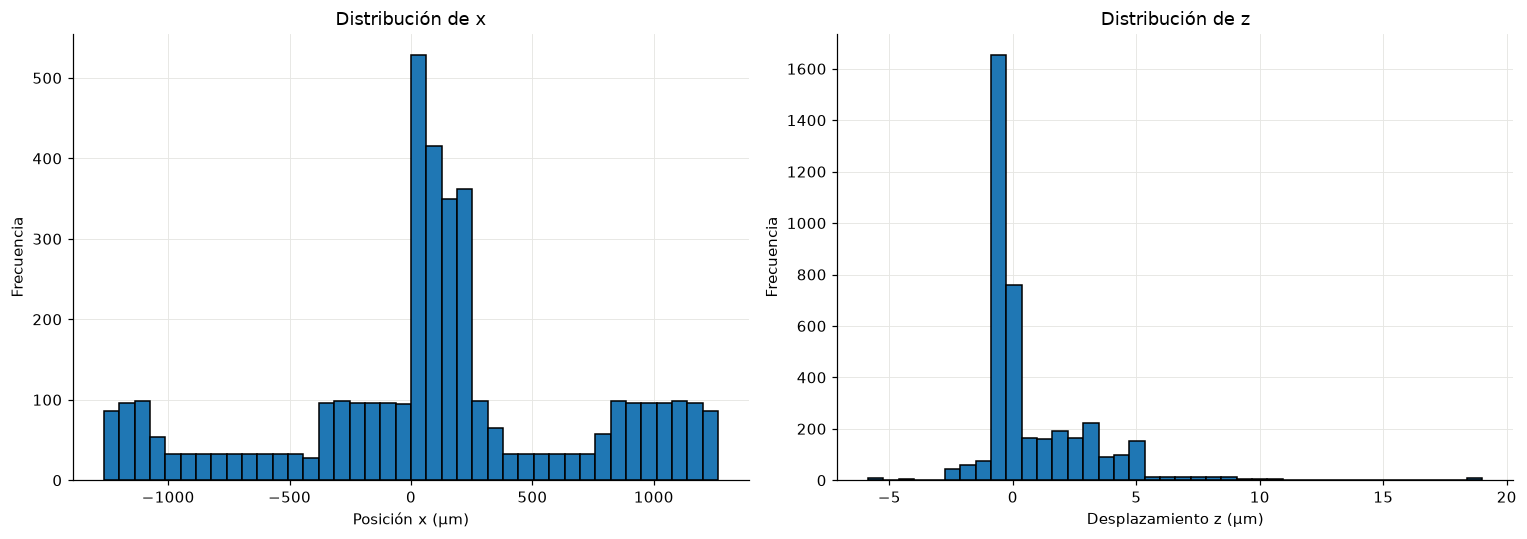

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df_master["x"],
    bins=40,
    edgecolor="black",
)
axes[0].set_title("Distribución de x")
axes[0].set_xlabel("Posición x (µm)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(
    df_master["z"],
    bins=40,
    edgecolor="black",
)
axes[1].set_title("Distribución de z")
axes[1].set_xlabel("Desplazamiento z (µm)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Boxplot

/tmp/ipykernel_107412/1266320552.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(
/tmp/ipykernel_107412/1266320552.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


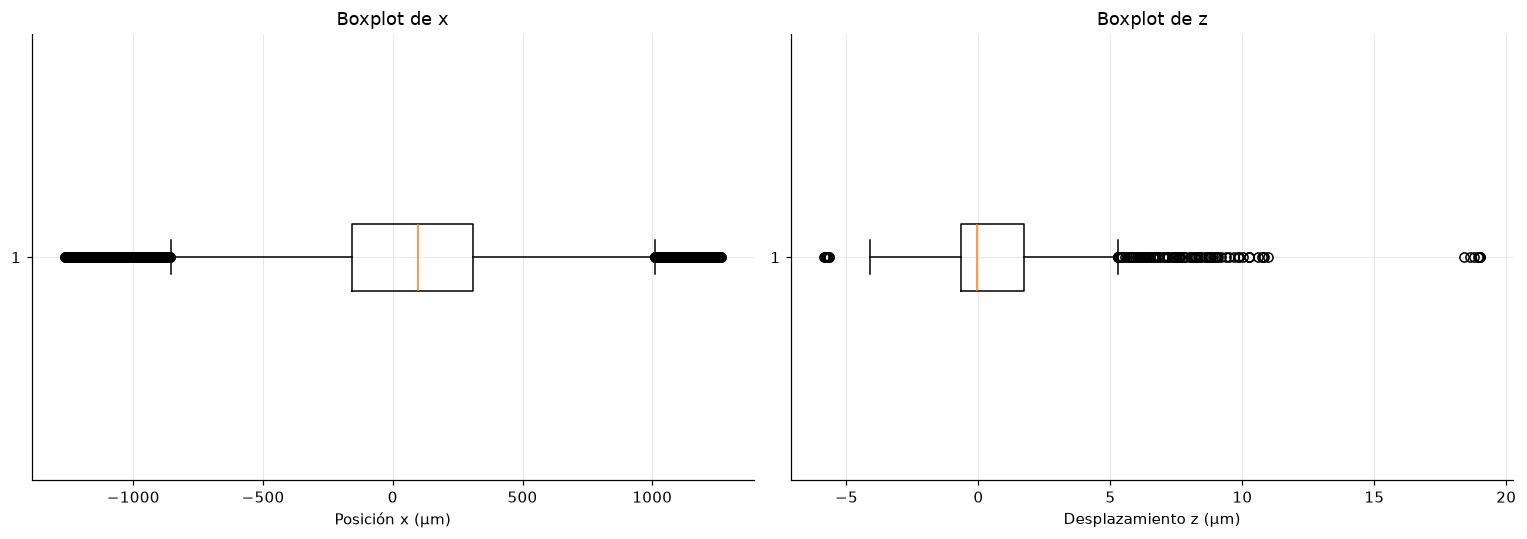

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    df_master["x"],
    vert=False,
)
axes[0].set_title("Boxplot de x")
axes[0].set_xlabel("Posición x (µm)")

axes[1].boxplot(
    df_master["z"],
    vert=False,
)
axes[1].set_title("Boxplot de z")
axes[1].set_xlabel("Desplazamiento z (µm)")

plt.tight_layout()
plt.show()

### Interpretación del análisis univariante

La variable `x` presenta una asimetría global de -0.2301, lo que indica una
asimetría negativa ligera. Sin embargo, su distribución global es multimodal
debido a que el conjunto consolida trazas con diferentes rangos espaciales y
orientaciones. Por esta razón, la distribución global de `x` no debe
interpretarse como una única población ni requiere una transformación para
aproximarla a una distribución normal.

La variable `z` presenta una asimetría positiva considerable (2.3442). El
histograma y el diagrama de caja muestran una concentración importante de
observaciones alrededor de valores cercanos a cero y una cola hacia valores
positivos elevados.

Los diagramas de caja identifican observaciones potencialmente atípicas,
especialmente en `z`. No obstante, estas observaciones no se eliminan
automáticamente, ya que pueden corresponder a características reales de las
trazas experimentales. Su comportamiento se analizará por traza antes de
determinar si requieren algún tratamiento.

### Detección formal de atípicos

In [69]:
outlier_summary = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
    )
    .apply(
        detect_iqr_outliers,
        include_groups=False,
    )
    .reset_index()
)

display(outlier_summary)

,test_type,material,trace,q1,q3,iqr,lower_bound,upper_bound,outliers,outlier_percentage
0,Residual Strain,RM 8096,ap,-0.8579,-0.0046,0.8534,-2.1380,1.2755,16.0000,11.1111
1,Residual Strain,RM 8096,b,-0.5173,3.9624,4.4796,-7.2367,10.6818,0.0000,0.0000
2,Residual Strain,RM 8097,ap,-0.7119,0.0014,0.7133,-1.7818,1.0713,77.0000,18.6441
3,Residual Strain,RM 8097,b,-0.6647,1.3346,1.9993,-3.6637,4.3335,10.0000,1.5625
4,Residual Strain,RM 8097,e,-0.7168,0.0039,0.7208,-1.7980,1.0851,78.0000,18.9320
5,Strain Gradient,RM 8096,d,-0.3505,5.1356,5.4861,-8.5797,13.3647,9.0000,2.1077
6,Strain Gradient,RM 8096,e,-0.6626,-0.0272,0.6354,-1.6157,0.9260,9.0000,16.0714
7,Strain Gradient,RM 8097,a,-0.5038,-0.0059,0.4980,-1.2508,0.7411,39.0000,12.8289
8,Strain Gradient,RM 8097,c,-0.5191,1.4621,1.9812,-3.4909,4.4339,4.0000,0.6421
9,Strain Gradient,RM 8097,e,-0.5170,0.0147,0.5317,-1.3145,0.8121,41.0000,13.5314


In [70]:
outlier_records = []

for group_keys, group in df_master.groupby(
    ["test_type", "material", "trace"]
):
    q1 = group["z"].quantile(0.25)
    q3 = group["z"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (group["z"] < lower_bound)
        | (group["z"] > upper_bound)
    )

    group_outliers = group.loc[mask].copy()

    if not group_outliers.empty:
        outlier_records.append(group_outliers)

if outlier_records:
    df_outliers = pd.concat(outlier_records, ignore_index=True)
else:
    df_outliers = pd.DataFrame(columns=df_master.columns)

print(f"Posibles valores atípicos: {len(df_outliers)}")
display(df_outliers.head(20))

Posibles valores atípicos: 283


,test_type,structure,material,chip,length_um,trace,x,z,calibrated,file
0,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,218.7050,-2.9809,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
1,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,219.1000,-2.8454,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
2,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,219.4950,-2.6947,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
3,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,219.8890,-2.5287,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
4,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,220.2840,-2.3968,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
5,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,220.6790,-2.3214,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
6,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,221.0740,-2.2847,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
7,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,221.4690,-2.2669,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
8,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,221.8630,-2.2687,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...
9,Residual Strain,fixed-fixed,RM 8096,0009,200,ap,222.2580,-2.2911,False,RESIDUAL.STRAIN.Sample.Data.Trace.ap.RM.8096.0...


### Resumen por trazas

In [71]:
outlier_counts = (
    df_outliers
    .groupby(
        ["test_type", "material", "trace"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "outliers"})
)

trace_sizes = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "observations"})
)

outlier_summary = trace_sizes.merge(
    outlier_counts,
    on=["test_type", "material", "trace"],
    how="left",
)

outlier_summary["outliers"] = (
    outlier_summary["outliers"]
    .fillna(0)
    .astype(int)
)

outlier_summary["outlier_percentage"] = (
    100
    * outlier_summary["outliers"]
    / outlier_summary["observations"]
)

display(outlier_summary)

,test_type,material,trace,observations,outliers,outlier_percentage
0,Residual Strain,RM 8096,ap,144,16,11.1111
1,Residual Strain,RM 8096,b,640,0,0.0000
2,Residual Strain,RM 8097,ap,413,77,18.6441
3,Residual Strain,RM 8097,b,640,10,1.5625
4,Residual Strain,RM 8097,e,412,78,18.9320
5,Strain Gradient,RM 8096,d,427,9,2.1077
6,Strain Gradient,RM 8096,e,56,9,16.0714
7,Strain Gradient,RM 8097,a,304,39,12.8289
8,Strain Gradient,RM 8097,c,623,4,0.6421
9,Strain Gradient,RM 8097,e,303,41,13.5314


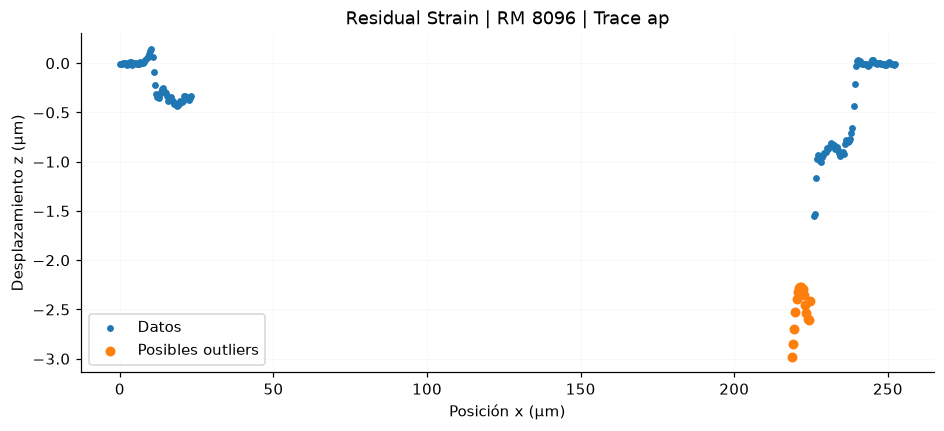

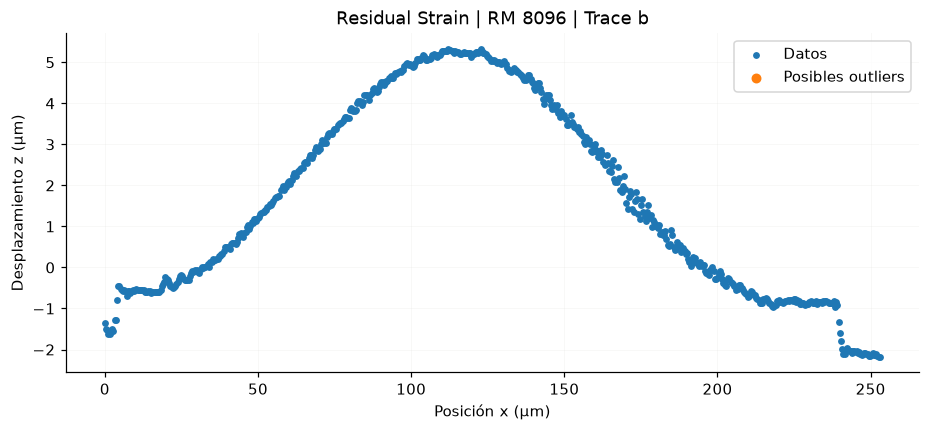

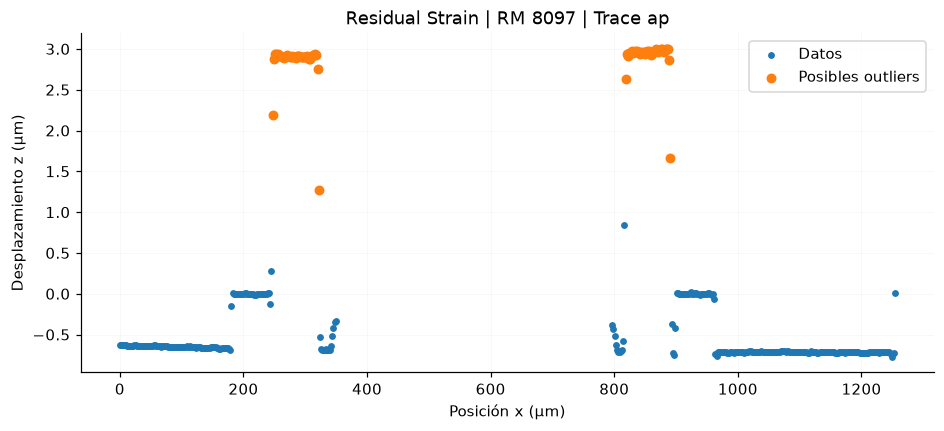

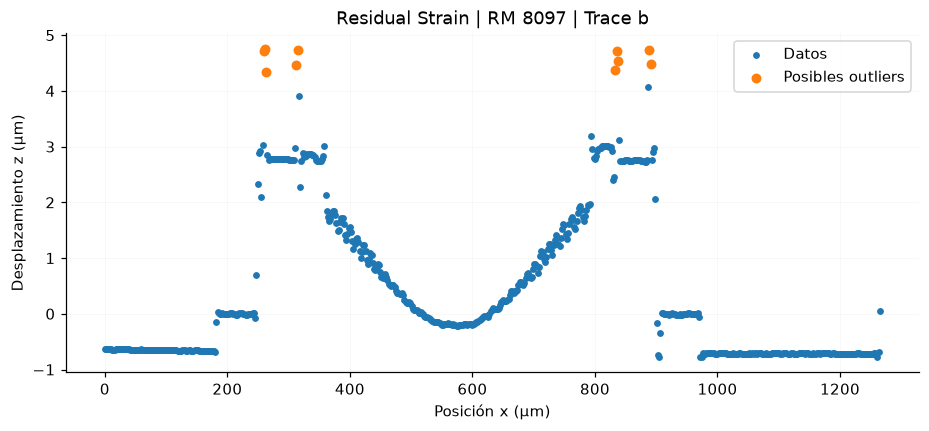

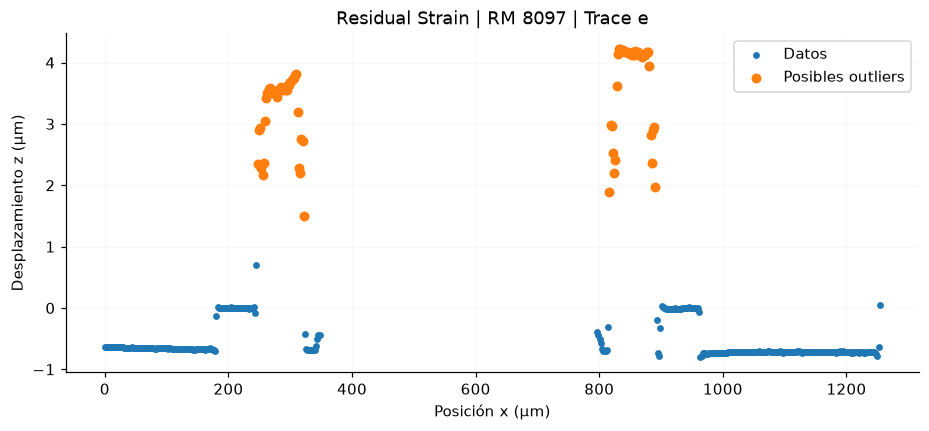

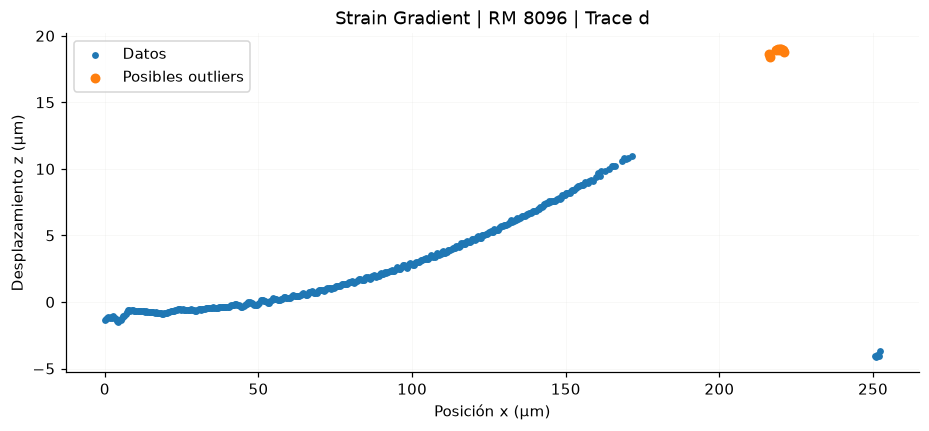

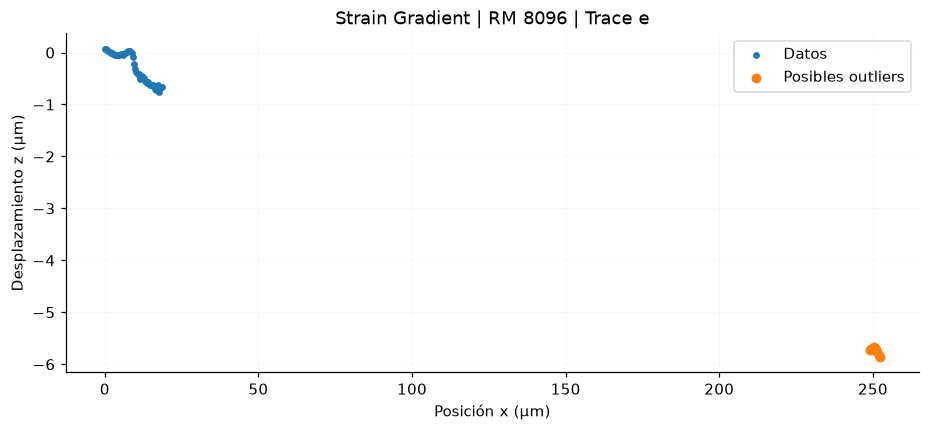

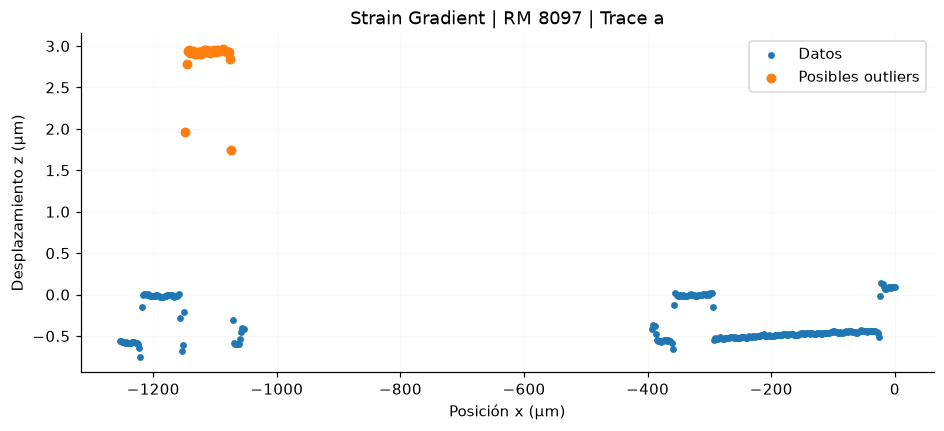

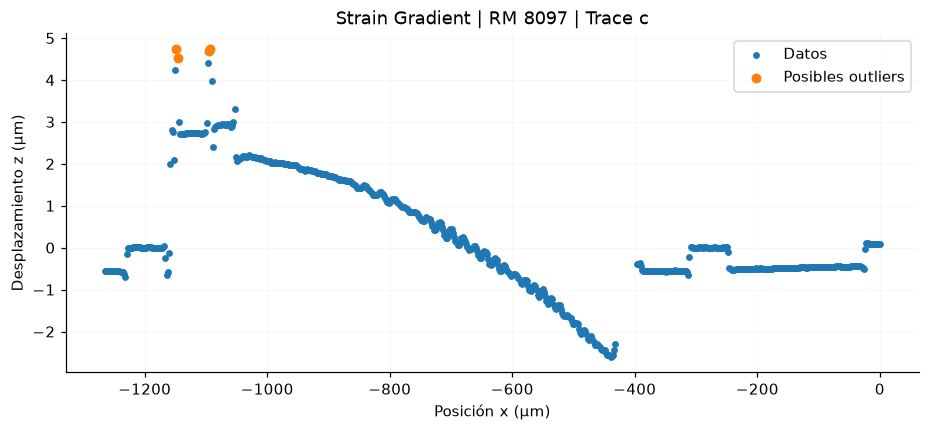

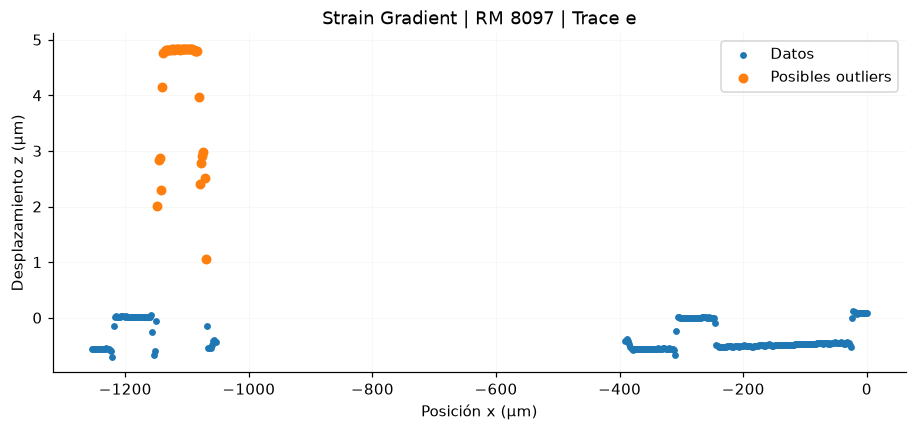

In [72]:
for keys, group in df_master.groupby(
    ["test_type", "material", "trace"]
):
    test_type, material, trace = keys

    q1 = group["z"].quantile(0.25)
    q3 = group["z"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (group["z"] < lower_bound)
        | (group["z"] > upper_bound)
    )

    plt.figure(figsize=(10, 4))

    plt.scatter(
        group["x"],
        group["z"],
        s=12,
        label="Datos",
    )

    plt.scatter(
        group.loc[mask, "x"],
        group.loc[mask, "z"],
        s=30,
        label="Posibles outliers",
    )

    plt.title(f"{test_type} | {material} | Trace {trace}")
    plt.xlabel("Posición x (µm)")
    plt.ylabel("Desplazamiento z (µm)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

### Tratamiento de valores atípicos

La regla del rango intercuartílico (IQR) identificó 283 observaciones como
potencialmente atípicas. Sin embargo, la inspección gráfica por traza muestra
que una parte importante de estas observaciones pertenece a segmentos
estructurados y continuos de los perfiles experimentales, en lugar de
corresponder a valores aislados.

El método IQR analiza únicamente la distribución de `z` y no considera la
posición espacial `x` ni la continuidad de cada perfil. Por ello, una
observación estadísticamente extrema no implica necesariamente un error de
medición en este conjunto de datos.

En consecuencia, los valores identificados mediante IQR se conservan para el
análisis. Eliminarlos podría remover características físicamente relevantes
de las trazas. El IQR se utiliza en este análisis como herramienta de
detección y no como criterio automático de eliminación.

### Valores faltantes

In [73]:
missing_summary = pd.DataFrame({
    "missing_values": df_master.isna().sum(),
    "missing_percentage": (
        df_master.isna().mean() * 100
    ),
})

display(missing_summary)

,missing_values,missing_percentage
test_type,0,0.0000
structure,0,0.0000
material,0,0.0000
chip,0,0.0000
length_um,0,0.0000
trace,0,0.0000
x,0,0.0000
z,0,0.0000
calibrated,0,0.0000
file,0,0.0000


### Tratamiento de valores faltantes

Los archivos originales de NIST contienen, además de las mediciones,
encabezados, fórmulas, instrucciones y otras celdas auxiliares. Durante la
construcción del conjunto de datos se convirtieron las columnas de medición
a valores numéricos y se conservaron únicamente las filas que contienen un
par válido de coordenadas `(x, z)`.

Por esta razón, el conjunto consolidado utilizado para el EDA no presenta
valores faltantes en las variables analizadas. No se realizó imputación, ya
que las filas descartadas no corresponden necesariamente a mediciones
experimentales ausentes, sino principalmente a la estructura adicional de
los archivos Excel.

### Alta cardinalidad

In [74]:
cardinality = (
    df_master[
        ["test_type", "material", "trace", "file"]
    ]
    .nunique()
    .rename("unique_values")
    .to_frame()
)

display(cardinality)

,unique_values
test_type,2
material,2
trace,6
file,10


No se identificó un problema de alta cardinalidad en las variables
categóricas. `test_type` y `material` contienen 2 categorías cada una,
mientras que `trace` contiene 6 categorías.

La variable `file` presenta 10 valores únicos, correspondientes a los 10
archivos de origen, y se conserva únicamente con fines de trazabilidad.

Por lo tanto, no es necesario aplicar técnicas de agrupamiento, reducción
de categorías o codificación especial para mitigar alta cardinalidad.

## 3.3 Análisis bi/multivariante

En esta sección se analiza la relación entre la posición `x` y el
desplazamiento `z`. Debido a que las observaciones pertenecen a diferentes
materiales, tipos de ensayo y trazas, la relación se estudia tanto de forma
global como por grupo.

Se emplean visualizaciones de los perfiles experimentales y coeficientes de
correlación para evaluar las relaciones entre las variables cuantitativas.

### Visual de las trazas de forma individual

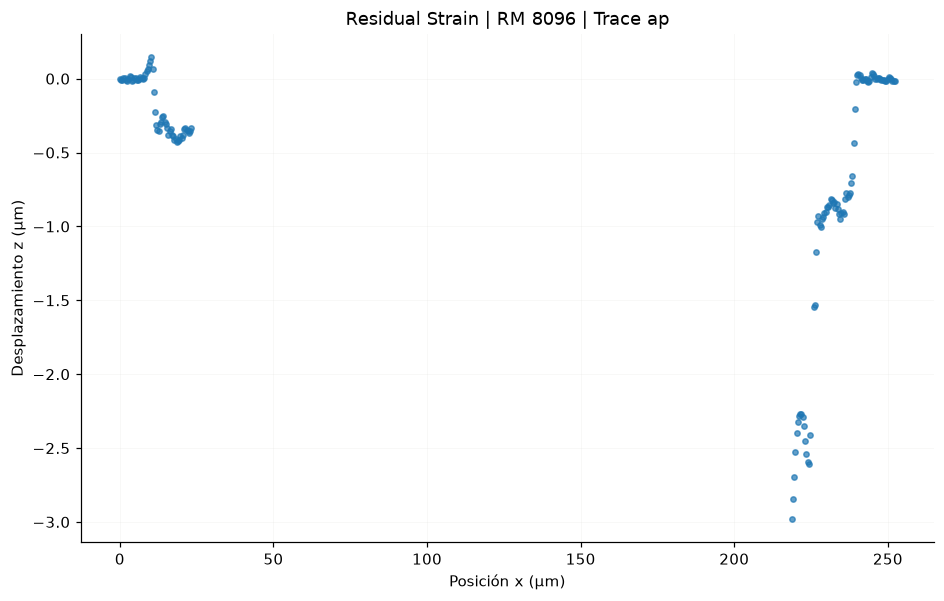

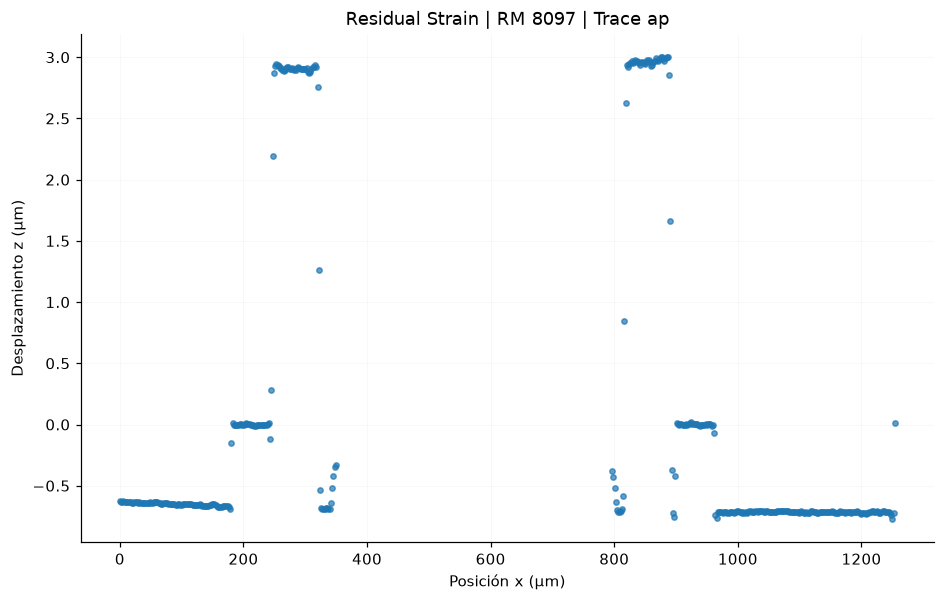

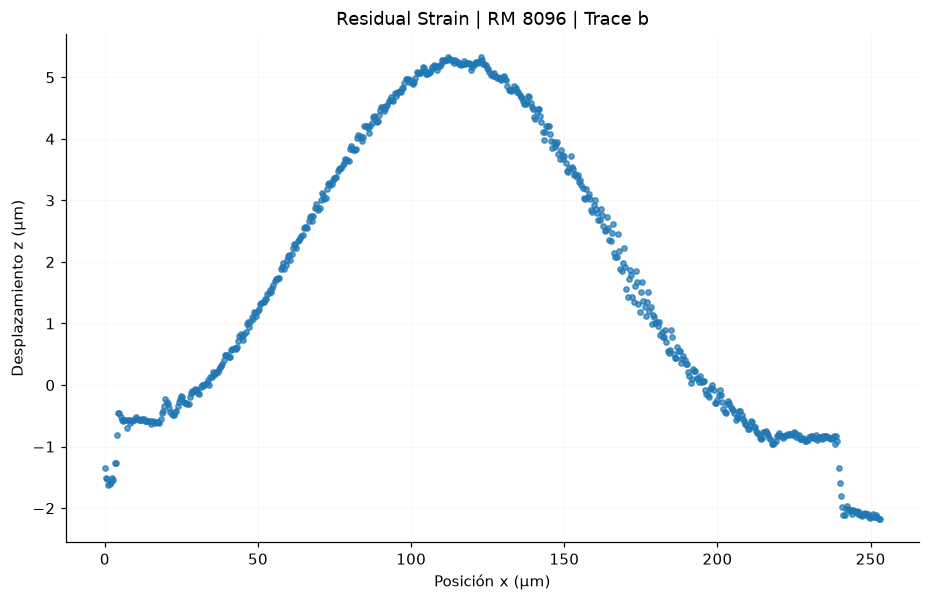

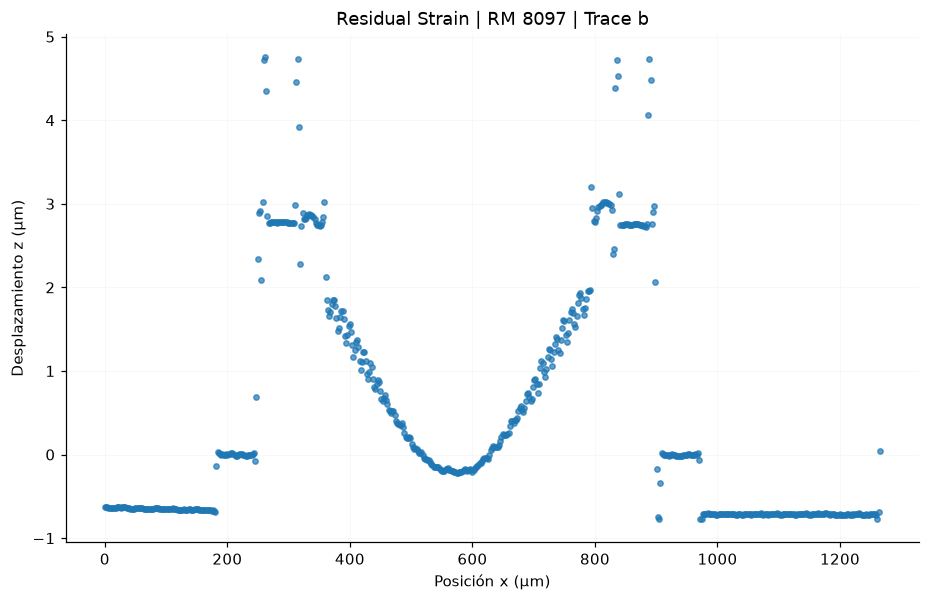

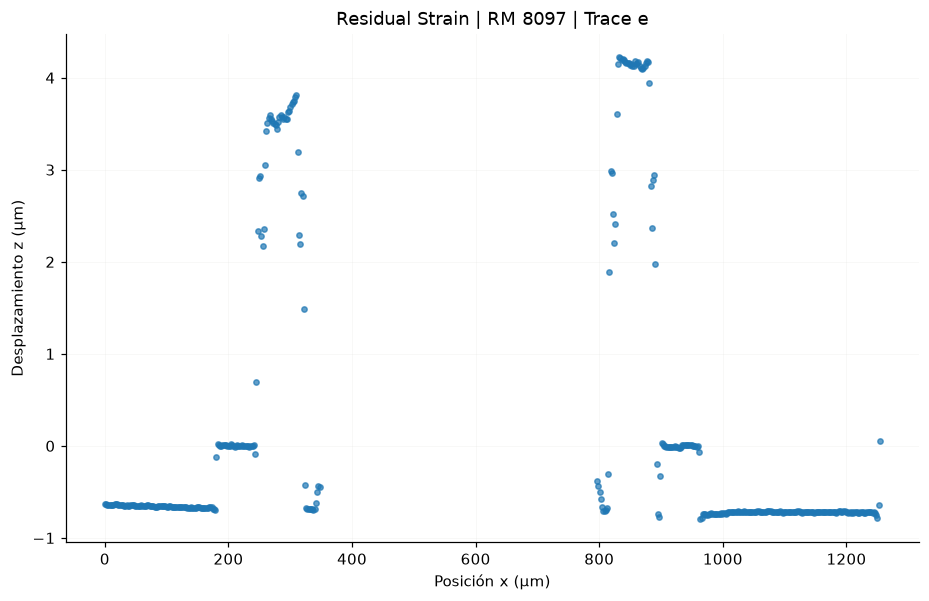

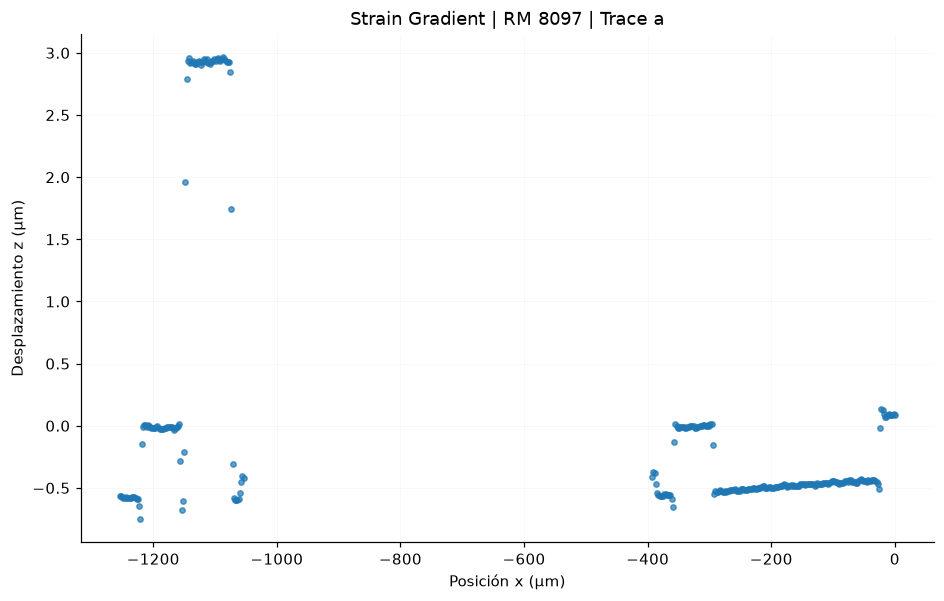

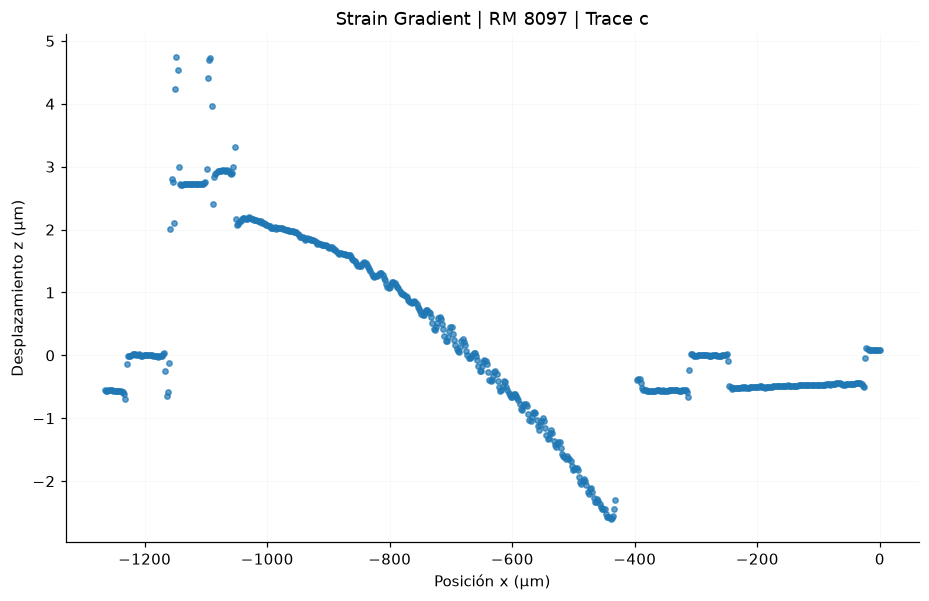

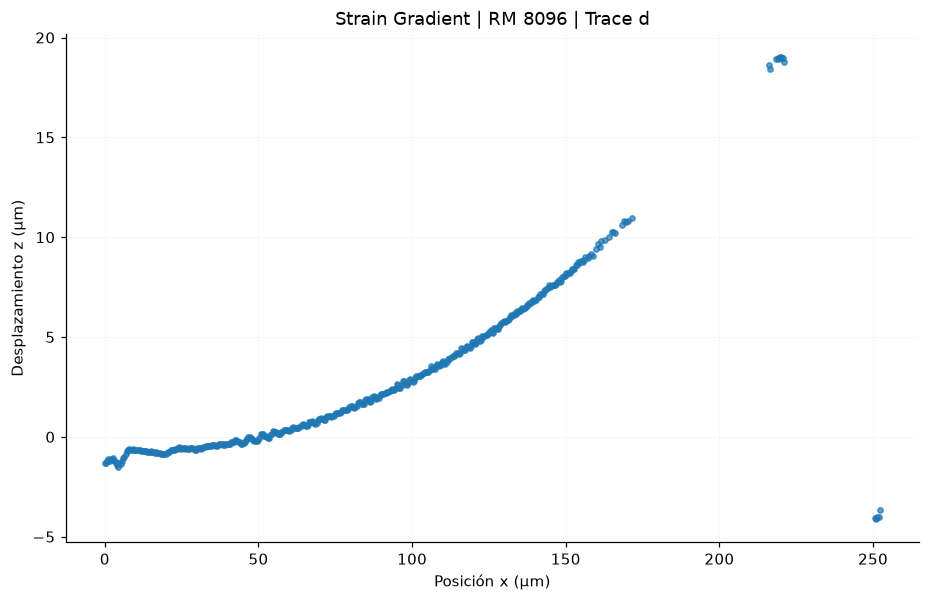

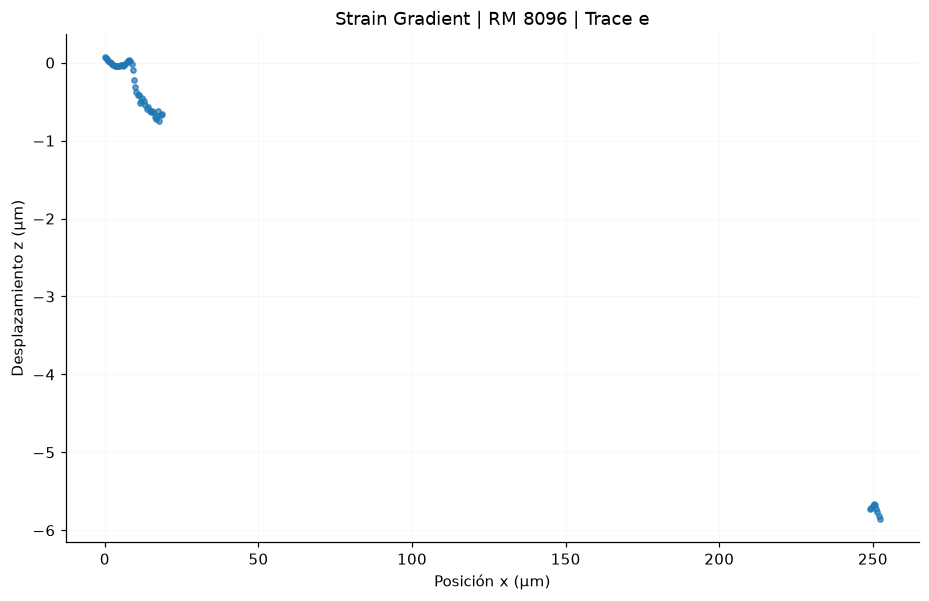

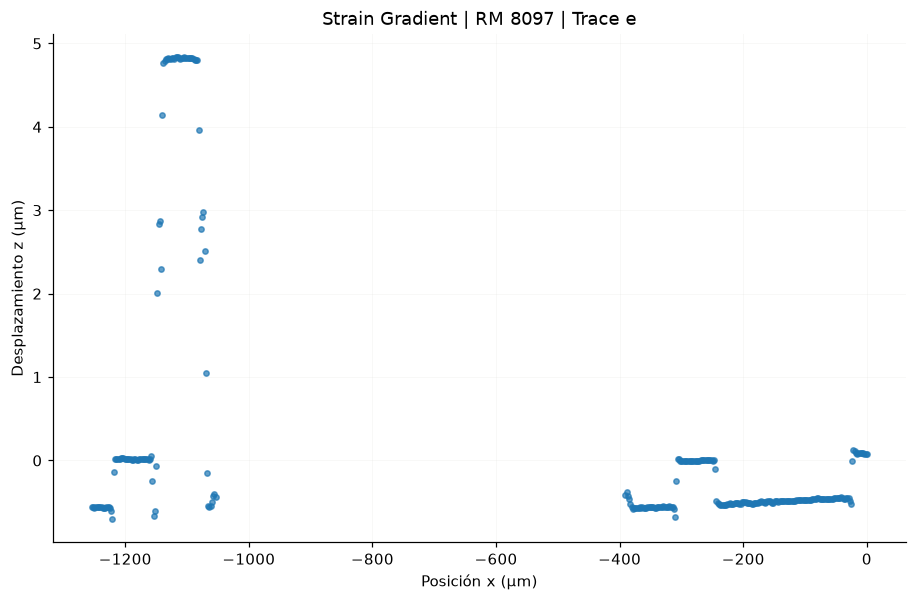

In [75]:
groups = df_master.groupby(
    ["test_type", "material", "trace"],
    sort=False,
)

for keys, group in groups:
    test_type, material, trace = keys

    group = group.sort_values("x")

    plt.figure(figsize=FIGSIZE)

    plt.scatter(
        group["x"],
        group["z"],
        s=12,
        alpha=0.7,
    )

    plt.title(f"{test_type} | {material} | Trace {trace}")
    plt.xlabel("Posición x (µm)")
    plt.ylabel("Desplazamiento z (µm)")
    plt.grid(alpha=0.3)

    plt.show()

### Correlación global y por traza

In [76]:
global_correlation = df_master["x"].corr(df_master["z"])

print(
    "Correlación global de Pearson entre x y z: "
    f"{global_correlation:.4f}"
)

correlation_by_trace = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
    )
    .apply(
        lambda group: group["x"].corr(group["z"]),
        include_groups=False,
    )
    .rename("pearson_correlation")
    .reset_index()
)

display(correlation_by_trace)

Correlación global de Pearson entre x y z: -0.0752


,test_type,material,trace,pearson_correlation
0,Residual Strain,RM 8096,ap,-0.3734
1,Residual Strain,RM 8096,b,-0.2350
2,Residual Strain,RM 8097,ap,-0.1298
3,Residual Strain,RM 8097,b,-0.1472
4,Residual Strain,RM 8097,e,-0.1077
5,Strain Gradient,RM 8096,d,0.8139
6,Strain Gradient,RM 8096,e,-0.9967
7,Strain Gradient,RM 8097,a,-0.5060
8,Strain Gradient,RM 8097,c,-0.6086
9,Strain Gradient,RM 8097,e,-0.5080


#### Interpretación de la correlación

La correlación global de Pearson entre `x` y `z` es -0.0752, lo que sugiere
una relación lineal prácticamente nula al considerar todas las observaciones
como un único conjunto.

Sin embargo, este resultado global oculta diferencias importantes entre las
trazas. Al calcular la correlación de manera independiente, se observan
relaciones de distinta magnitud y dirección. Por ejemplo, Strain Gradient
RM 8096, traza d, presenta una correlación positiva fuerte (0.8139), mientras
que la traza e del mismo material presenta una correlación negativa muy fuerte
(-0.9967).

Las trazas de Residual Strain presentan coeficientes de Pearson de menor
magnitud. No obstante, las visualizaciones muestran perfiles curvos, por lo
que un coeficiente lineal bajo no implica necesariamente ausencia de relación
entre la posición y el desplazamiento.

Por esta razón, la relación entre `x` y `z` debe interpretarse conjuntamente
mediante los coeficientes de correlación y la inspección gráfica de cada
traza, evitando conclusiones basadas únicamente en la correlación global.

In [77]:
correlation_comparison = (
    df_master
    .groupby(
        ["test_type", "material", "trace"],
    )
    .apply(
        lambda group: pd.Series({
            "pearson": group["x"].corr(
                group["z"],
                method="pearson",
            ),
            "spearman": group["x"].corr(
                group["z"],
                method="spearman",
            ),
        }),
        include_groups=False,
    )
    .reset_index()
)

display(correlation_comparison)

,test_type,material,trace,pearson,spearman
0,Residual Strain,RM 8096,ap,-0.3734,-0.0984
1,Residual Strain,RM 8096,b,-0.2350,-0.2767
2,Residual Strain,RM 8097,ap,-0.1298,-0.5371
3,Residual Strain,RM 8097,b,-0.1472,-0.3411
4,Residual Strain,RM 8097,e,-0.1077,-0.5307
5,Strain Gradient,RM 8096,d,0.8139,0.9287
6,Strain Gradient,RM 8096,e,-0.9967,-0.9336
7,Strain Gradient,RM 8097,a,-0.5060,-0.0917
8,Strain Gradient,RM 8097,c,-0.6086,-0.5643
9,Strain Gradient,RM 8097,e,-0.5080,-0.1076


#### Comparación entre Pearson y Spearman

La comparación entre los coeficientes de Pearson y Spearman confirma que la
relación entre posición y desplazamiento depende de la traza y no siempre
puede describirse adecuadamente mediante una relación lineal.

En Strain Gradient RM 8096, las trazas d y e presentan asociaciones fuertes
con ambos coeficientes. La traza d muestra una relación positiva fuerte
(Pearson = 0.8139; Spearman = 0.9287), mientras que la traza e presenta una
relación negativa muy fuerte (Pearson = -0.9967; Spearman = -0.9336).

En otras trazas existen diferencias importantes entre ambos coeficientes. Por
ejemplo, Residual Strain RM 8097, traza ap, presenta Pearson = -0.1298 y
Spearman = -0.5371. Esto indica que una relación poco lineal puede presentar
una asociación monotónica de mayor magnitud.

También existen perfiles en los que ninguno de los coeficientes resume por
completo la geometría observada. Por ello, los coeficientes se interpretan
como medidas complementarias a las visualizaciones de las trazas y no como
evidencia suficiente, por sí solos, de ausencia o presencia de una relación
entre `x` y `z`.

### Comparación de categorías

In [78]:
category_summary = (
    df_master
    .groupby(
        ["test_type", "material"],
        as_index=False,
    )
    .agg(
        observations=("z", "size"),
        z_mean=("z", "mean"),
        z_median=("z", "median"),
        z_std=("z", "std"),
        z_min=("z", "min"),
        z_max=("z", "max"),
    )
)

display(category_summary)

,test_type,material,observations,z_mean,z_median,z_std,z_min,z_max
0,Residual Strain,RM 8096,784,1.2469,0.2079,2.3088,-2.9809,5.3275
1,Residual Strain,RM 8097,1465,0.2959,-0.6334,1.4481,-0.7961,4.7550
2,Strain Gradient,RM 8096,483,2.3748,0.9182,4.0758,-5.8574,19.0176
3,Strain Gradient,RM 8097,1230,0.2378,-0.4388,1.3903,-2.6045,4.8358


### Distribución de z por tipo de ensayo

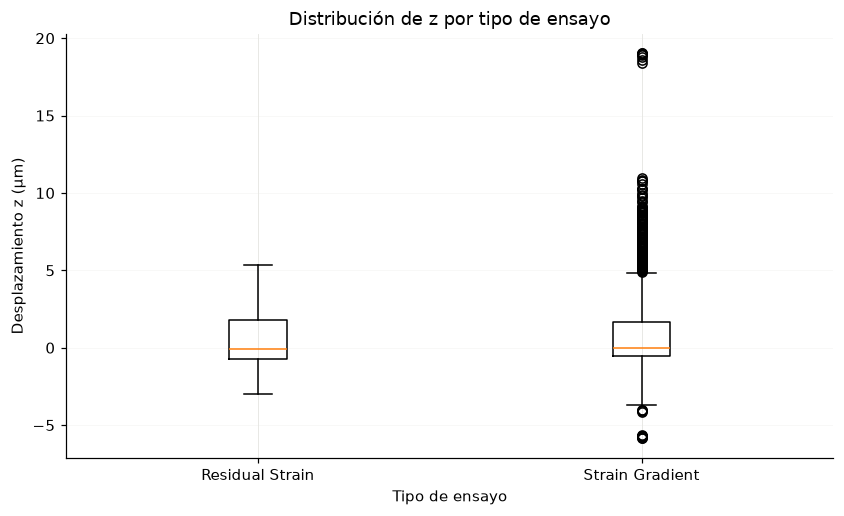

In [79]:
test_types = df_master["test_type"].unique()

data_by_test = [
    df_master.loc[
        df_master["test_type"] == test_type,
        "z",
    ]
    for test_type in test_types
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data_by_test,
    tick_labels=test_types,
)

plt.title("Distribución de z por tipo de ensayo")
plt.xlabel("Tipo de ensayo")
plt.ylabel("Desplazamiento z (µm)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Por material

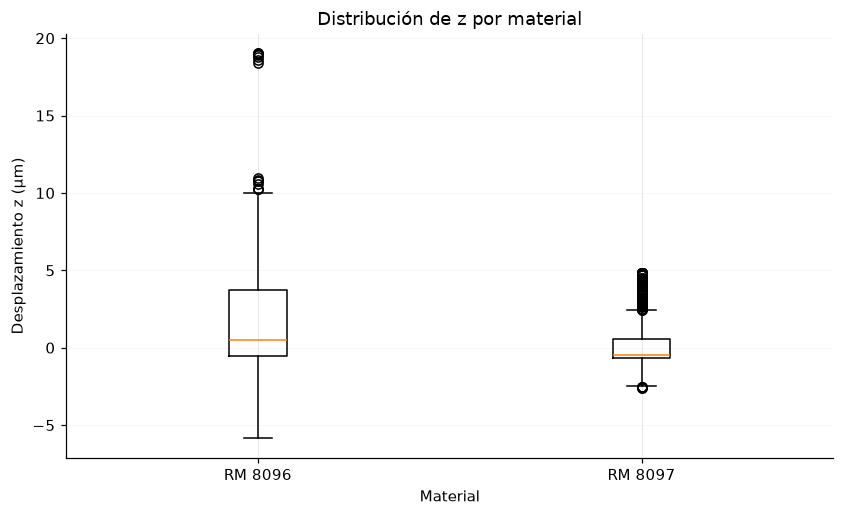

In [80]:
materials = df_master["material"].unique()

data_by_material = [
    df_master.loc[
        df_master["material"] == material,
        "z",
    ]
    for material in materials
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data_by_material,
    tick_labels=materials,
)

plt.title("Distribución de z por material")
plt.xlabel("Material")
plt.ylabel("Desplazamiento z (µm)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Comparación por tipo de ensayo y material

La distribución del desplazamiento `z` presenta diferencias importantes entre
los grupos analizados. RM 8096 muestra, en general, una mayor dispersión que
RM 8097.

Esta diferencia es especialmente evidente en Strain Gradient. Para RM 8096,
`z` presenta una media de 2.3748 µm, una desviación estándar de 4.0758 µm y
valores entre -5.8574 y 19.0176 µm. Para RM 8097, la media es de 0.2378 µm,
la desviación estándar de 1.3903 µm y el intervalo observado se encuentra
entre -2.6045 y 4.8358 µm.

En Residual Strain también se observa mayor variabilidad en RM 8096
(desviación estándar de 2.3088 µm) que en RM 8097 (1.4481 µm).

Los diagramas de caja confirman estas diferencias y muestran nuevamente
observaciones estadísticamente extremas. Como se discutió previamente, estos
valores se conservan debido a que pueden formar parte de la estructura de los
perfiles experimentales.

Estas comparaciones son descriptivas y no se interpretan como evidencia de
que un material presente un comportamiento superior a otro, ya que las
observaciones provienen de diferentes trazas y condiciones experimentales.

Además, estas comparaciones mezclan varios factores a la vez: el material (óxido en RM 8096 y polisilicio en RM 8097), la longitud de la estructura (200 µm contra 500–650 µm), el tipo de estructura (viga biempotrada o voladizo) y el tipo de traza (a lo largo de la viga o transversal). Por eso no se usan para sacar conclusiones físicas. El análisis físico, estructura por estructura, está en la sección 3.5.

## 3.4 Aspectos del EDA que no aplican al conjunto de datos

### Tendencias temporales

No aplica un análisis de tendencias temporales. Las variables principales
representan posición (`x`) y desplazamiento (`z`) a lo largo de perfiles
espaciales. Aunque los archivos puedan contener metadatos relacionados con
su adquisición, el conjunto consolidado utilizado en este análisis no
representa una serie temporal.

### Desbalance de clases

No aplica un análisis de desbalance de la variable objetivo, ya que este
avance corresponde a un análisis exploratorio de mediciones continuas y no
se ha definido una variable objetivo categórica para un problema de
clasificación.

### Normalización de imágenes

No aplica normalización de imágenes, debido a que el conjunto analizado está
compuesto por mediciones numéricas obtenidas de archivos Excel y no contiene
datos de imagen.

### Transformaciones no lineales

Aunque la variable `z` presenta asimetría positiva, no se aplica una
transformación no lineal en este avance. Los valores representan
desplazamientos físicos y pueden incluir valores positivos, negativos y
cercanos a cero. Además, las diferencias en la distribución están asociadas
a la geometría de las distintas trazas. Una transformación podría dificultar
su interpretación física sin aportar un beneficio claro para los objetivos
del EDA.

## 3.5 Análisis por perfil para el Brazo 2

Las secciones anteriores siguen el formato del EDA del curso y analizan `x` y `z` con todas las trazas juntas. Para el proyecto, el Brazo 2 necesita otra cosa: estimar la **deformación residual** en las vigas biempotradas y el **gradiente de deformación** en los voladizos, y revisar si los residuos del modelo tienen **estructura espacial**, en particular cerca del anclaje (guía `datos/02-datos-reales-nist-sp260-177.md`, §6).

Esta sección analiza por separado las cuatro estructuras que tienen una traza a lo largo de la viga (trazas b, c y d). Usa el tramo de la viga y el modelo que calcula la propia hoja del NIST: dos cosenos para la viga biempotrada y un círculo para el voladizo. La conversión de las trazas está validada contra esas mismas hojas (`tests/test_brazo2.py`). Las trazas transversales (a, a', e) sirven para ubicar los bordes de la estructura y no se modelan.

In [81]:
from pinn_mems.nist.brazo2 import beam_profile, read_sheet_parameters, residual_by_zone, strain_gradient
from pinn_mems.nist.ruido import noise_table

beam_files = [f for f in excel_files if f.name.split(".Trace.")[1].split(".")[0] in {"b", "c", "d"}]
profiles = {f.name: beam_profile(f) for f in beam_files}

structures = []
for f in beam_files:
    profile = profiles[f.name]
    params = read_sheet_parameters(f)
    structures.append({
        "structure": profile["structure"].iloc[0],
        "material": profile["material"].iloc[0],
        "length_um": profile["length_um"].iloc[0],
        "trace": profile["trace"].iloc[0],
        "modeled_points": len(profile),
        "v_start_um": profile["v_um"].iloc[0],
        "v_end_um": profile["v_um"].iloc[-1],
        "Rint_um": params.get("Rint", np.nan),
        "strain_gradient_1_per_m": strain_gradient(params["Rint"], params["s"]) if "Rint" in params else np.nan,
    })

structures = pd.DataFrame(structures)
display(structures)

,structure,material,length_um,trace,modeled_points,v_start_um,v_end_um,Rint_um,strain_gradient_1_per_m
0,fixed-fixed,RM 8096,200,b,492,26.1314,220.5319,NaN,NaN
1,fixed-fixed,RM 8097,500,b,252,320.7052,817.6002,NaN,NaN
2,cantilever,RM 8097,650,c,322,-439.8196,-1074.9637,47523.6500,-21.0422
3,cantilever,RM 8096,200,d,342,21.3802,157.1842,1171.9800,853.2569


### 3.5.1 Las cuatro estructuras

- En los **voladizos**, el NIST describe el perfil con un círculo de radio `Rint`; el gradiente de deformación es `1/Rint` (con el signo de la curvatura). Para el voladizo de RM 8096 se obtiene el mismo valor que el ejemplo resuelto del SP 260-177 (853 m⁻¹, p. 190).
- En las **vigas biempotradas**, la deformación residual requiere el procedimiento completo de la norma ASTM E2245 (longitud curva de los dos cosenos y longitud en el plano a partir de los bordes). El cálculo ya está implementado y validado con el ejemplo resuelto del NIST (`brazo2.residual_strain`), pero aplicarlo a estas trazas requiere elegir los cinco puntos y los bordes de cada viga; por eso aquí solo se analiza la forma del perfil.
- `v` es la posición a lo largo de la viga corregida por la desalineación α; en los voladizos con orientación de 180° es negativa.

### 3.5.2 Perfil medido contra el modelo del NIST

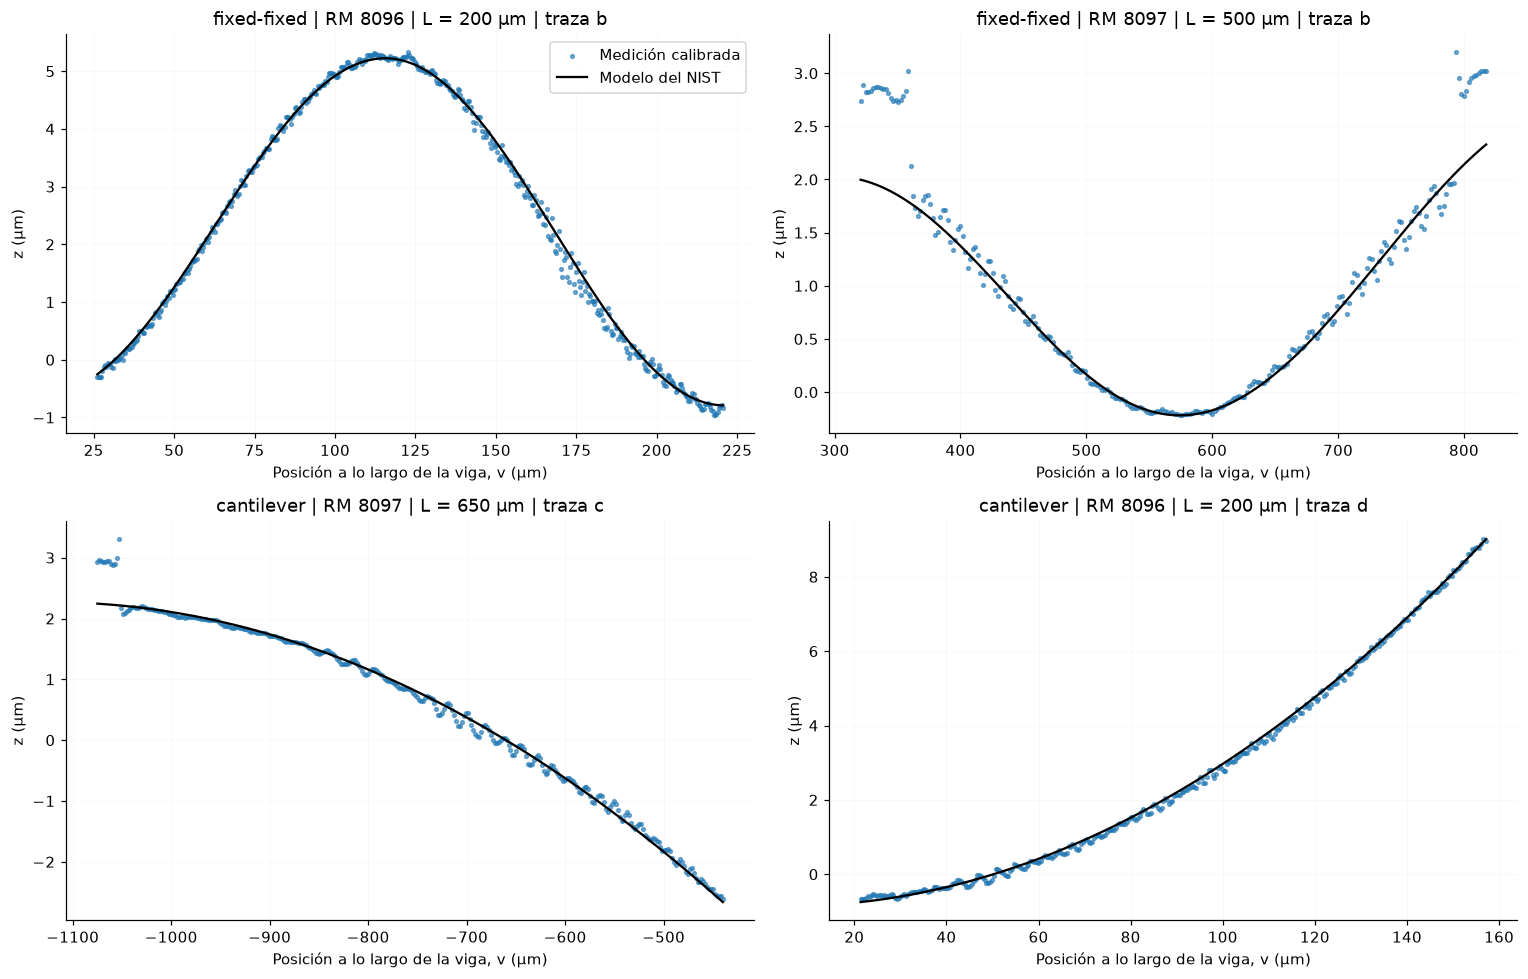

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, f in zip(axes.flat, beam_files):
    profile = profiles[f.name]
    ax.scatter(profile["v_um"], profile["z_um"], s=6, alpha=0.6, label="Medición calibrada")
    ax.plot(profile["v_um"], profile["z_model_um"], color="black", linewidth=1.5, label="Modelo del NIST")
    ax.set_title(f"{profile['structure'].iloc[0]} | {profile['material'].iloc[0]} | "
                 f"L = {profile['length_um'].iloc[0]} µm | traza {profile['trace'].iloc[0]}")
    ax.set_xlabel("Posición a lo largo de la viga, v (µm)")
    ax.set_ylabel("z (µm)")
    ax.grid(alpha=0.3)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

A simple vista el modelo describe bien la forma de cada estructura: el arco de las vigas biempotradas y la curvatura de los voladizos. Para ver dónde falla hay que mirar los residuos.

### 3.5.3 Residuos y ruido de medición

El residuo es la medición menos el modelo. La franja gris marca ±2σ del ruido de medición, estimado en cada traza con segundas diferencias (`src/pinn_mems/nist/ruido.py`). La posición se normaliza con `xi`, que va de 0 en el borde del anclaje (el offset `f` de la hoja) a 1 a lo largo del tramo que modela el NIST.

En las estructuras de RM 8097, el tramo del NIST incluye en sus extremos algunos puntos sobre la **meseta del soporte**, casi 1 µm por encima de la viga. Ahí el modelo de la viga no aplica, así que esos puntos (en gris claro) se excluyen de los cálculos de residuos (`on_beam = False`).

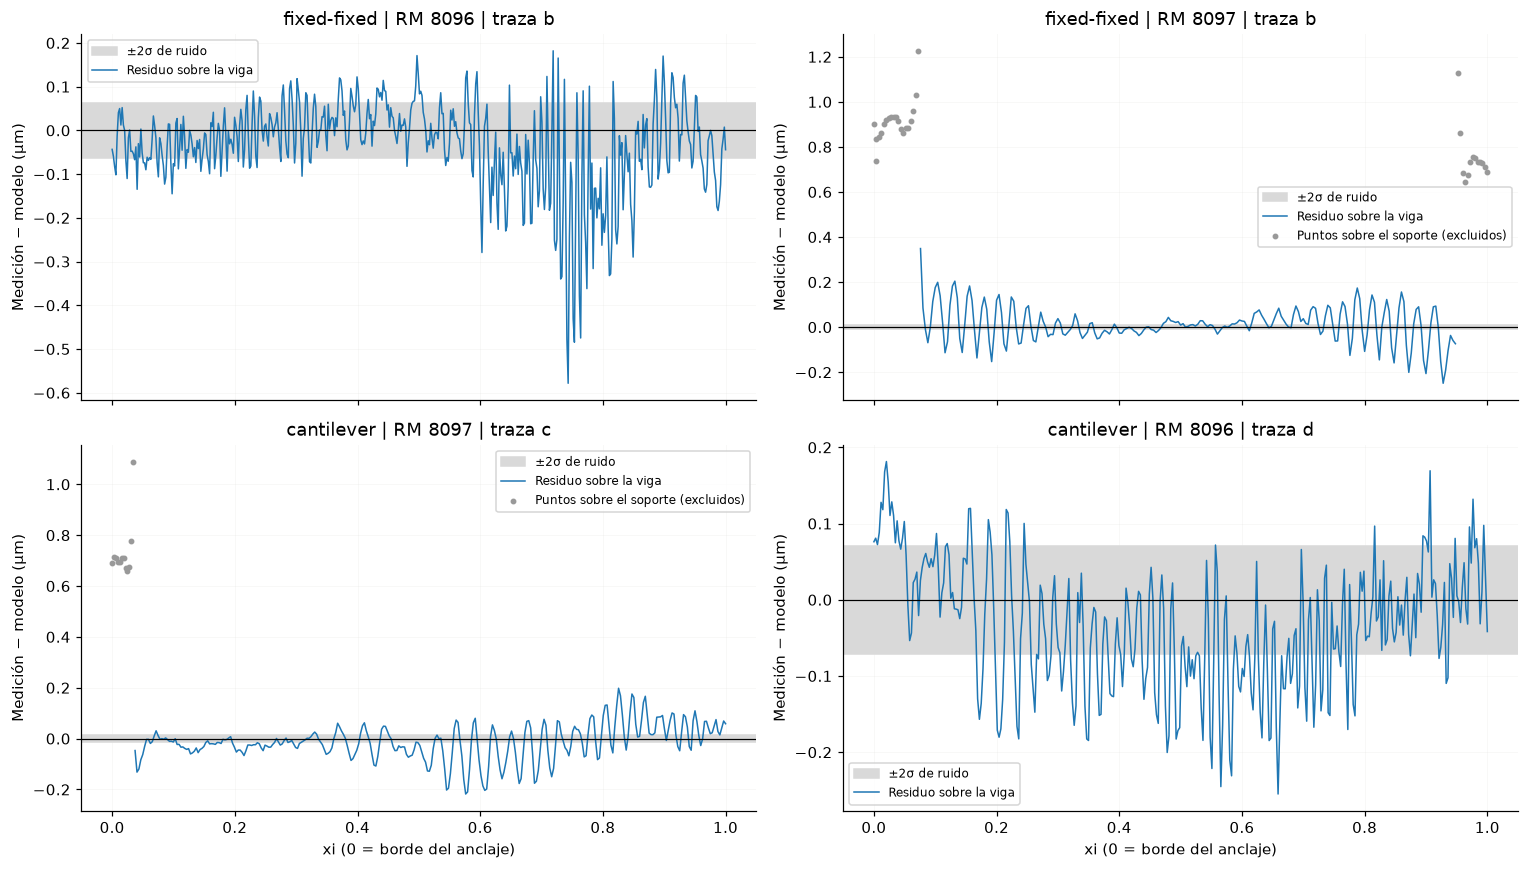

In [83]:
noise = noise_table().set_index("file")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, f in zip(axes.flat, beam_files):
    profile = profiles[f.name]
    beam = profile[profile["on_beam"]]
    support = profile[~profile["on_beam"]]
    sigma = noise.loc[f.name, "sigma_second_diff_um"]
    ax.axhspan(-2 * sigma, 2 * sigma, color="0.85", label="±2σ de ruido")
    ax.plot(beam["xi"], beam["residual_um"], linewidth=1, label="Residuo sobre la viga")
    if len(support):
        ax.scatter(support["xi"], support["residual_um"], s=8, color="0.6", label="Puntos sobre el soporte (excluidos)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{profile['structure'].iloc[0]} | {profile['material'].iloc[0]} | traza {profile['trace'].iloc[0]}")
    ax.set_ylabel("Medición − modelo (µm)")
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("xi (0 = borde del anclaje)")
for ax in axes.flat:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [84]:
zones = []
for f in beam_files:
    profile = profiles[f.name]
    sigma = noise.loc[f.name, "sigma_second_diff_um"]
    summary = residual_by_zone(profile)
    zones.append({
        "structure": profile["structure"].iloc[0],
        "material": profile["material"].iloc[0],
        "trace": profile["trace"].iloc[0],
        "noise_sigma_um": sigma,
        **summary,
        "excluded_points": int((~profile["on_beam"]).sum()),
        "rms_total_over_noise": np.sqrt(np.mean(profile.loc[profile["on_beam"], "residual_um"] ** 2)) / sigma,
    })

zones = pd.DataFrame(zones)
display(zones)

,structure,material,trace,noise_sigma_um,rms_start_um,rms_center_um,rms_end_um,lag1_autocorrelation,excluded_points,rms_total_over_noise
0,fixed-fixed,RM 8096,b,0.0318,0.0608,0.1230,0.0864,0.6152,0,3.4793
1,fixed-fixed,RM 8097,b,0.0048,0.1397,0.0612,0.1193,0.5982,33,16.4525
2,cantilever,RM 8097,c,0.0063,0.0447,0.0740,0.0684,0.8156,12,11.1318
3,cantilever,RM 8096,d,0.0355,0.0746,0.0992,0.0592,0.6799,0,2.5627


### 3.5.4 Lectura de los residuos

Los números de esta sección se calculan solo con los puntos sobre la viga.

- **Los residuos tienen estructura, no son ruido.** En las cuatro estructuras el residuo es entre 2.6 y 16.5 veces el ruido de medición (`rms_total_over_noise`) y está correlacionado entre puntos vecinos (`lag1_autocorrelation` entre 0.6 y 0.8; con ruido blanco sería cercana a 0). El modelo del NIST deja una parte sistemática sin explicar: exactamente el tipo de discrepancia que estudia el proyecto.
- **Viga biempotrada de RM 8097:** cerca de los dos soportes el residuo es unas dos veces el del centro (`rms_start_um` y `rms_end_um` contra `rms_center_um`). Es una firma "cerca del anclaje" como la que busca el Brazo 2. Pero el SP 260-177 advierte que en RM 8097 hay transiciones verticales de la geometría cerca de los soportes, así que no se puede atribuir solo a la flexibilidad del anclaje.
- **Voladizo de RM 8097 y estructuras de RM 8096 (óxido):** no muestran una firma cerca del anclaje; en RM 8096 el residuo es algo mayor en el centro de la viga.
- **Oscilación regular en RM 8097:** en las dos estructuras de polisilicio el residuo oscila con un periodo casi constante (unos pocos puntos de muestreo) y su amplitud crece hacia los extremos. Podría ser un artefacto del interferómetro más que una propiedad de la viga; conviene revisarlo antes de usar estos residuos para comparar métodos.
- **Ojo con el tramo de la hoja:** en RM 8097 el tramo que modela el NIST incluye puntos sobre el soporte. Si no se excluyen, aparentan un residuo diez veces mayor cerca de los extremos.
- **Consecuencia para el modelado:** como los residuos están correlacionados, una verosimilitud que trate cada punto como independiente subestimaría la incertidumbre. Conviene un modelo de discrepancia o de ruido correlacionado (niveles L2 y L3 de la escalera).

### 3.5.5 Tendencias con la longitud y alcance del Brazo 2

El SP 260-177 resume la dependencia con la longitud en dos figuras que no forman parte de estos archivos:

- **Fig. RS10 (deformación residual):** "reveals no obvious length dependence" [SP 260-177, p. 72]. Es un resultado nulo.
- **Fig. SG10 (gradiente de deformación):** el gradiente baja al aumentar la longitud de 400 a 600 µm y luego se estabiliza entre 600 y 750 µm [SP 260-177, p. 92]. Es una tendencia, pero no necesariamente causada por el anclaje.

Alcance de estos datos:

- Son **cuatro estructuras de ejemplo**, de dos materiales (óxido y polisilicio) y con **una sola traza a lo largo de cada una**. No forman un barrido de longitudes.
- Los brazos **no miden los mismos chips**: no se compara el ΔL del Brazo 1 con estos datos.
- Sí permiten lo que el Brazo 1 no puede: probar los métodos con **residuos espaciales reales**, medidos a lo largo de la viga.

## 3.6 Conclusiones

El análisis exploratorio permitió caracterizar las mediciones de Residual
Strain y Strain Gradient correspondientes a los materiales de referencia
RM 8096 y RM 8097. El conjunto consolidado contiene 3,962 observaciones
provenientes de 10 trazas experimentales.

La exploración mostró que las trazas presentan comportamientos heterogéneos,
por lo que analizarlas únicamente como un conjunto agregado puede ocultar
información relevante. Esto se observa especialmente en la relación entre
posición (`x`) y desplazamiento (`z`): la correlación global de Pearson fue
de -0.0752, lo que inicialmente sugeriría una relación lineal prácticamente
nula. Sin embargo, el análisis individual reveló relaciones considerablemente
más fuertes. Por ejemplo, Strain Gradient RM 8096, traza d, presentó una
correlación de Pearson de 0.8139, mientras que la traza e alcanzó -0.9967.

La comparación entre Pearson y Spearman también mostró que algunas relaciones
no pueden describirse adecuadamente mediante una asociación lineal. Los
perfiles experimentales presentan formas y cambios de dirección que hacen
necesario complementar las métricas de correlación con la inspección gráfica
de cada traza.

En el análisis univariante, `z` presentó una asimetría positiva considerable
(skewness = 2.3442), mientras que `x` mostró una asimetría global ligera
(skewness = -0.2301). La distribución de `x` es multimodal debido a la
combinación de perfiles con diferentes rangos espaciales y orientaciones,
por lo que no se consideró apropiado tratarla como una única distribución.

Mediante la regla del rango intercuartílico (IQR) se identificaron 283
observaciones potencialmente atípicas. La inspección de las trazas mostró
que una parte importante de estos valores pertenece a regiones continuas de
los perfiles y no corresponde a observaciones aisladas. Por esta razón, se
decidió conservarlos, ya que su eliminación podría remover información
físicamente relevante de las mediciones.

También se observaron diferencias entre los materiales y tipos de ensayo.
RM 8096 presentó una mayor variabilidad de `z` que RM 8097. Esta diferencia
fue especialmente evidente en Strain Gradient, donde RM 8096 presentó una
desviación estándar de 4.0758 µm frente a 1.3903 µm para RM 8097. Estas
diferencias se consideran descriptivas y no implican por sí mismas un mejor
o peor comportamiento de alguno de los materiales.

Durante el preprocesamiento se aplicaron los factores de calibración del
instrumento a las trazas que los incluyen (b, c y d), se homogeneizaron las
mediciones de posición en micrómetros y se conservaron únicamente pares numéricos válidos de `(x, z)`.
El conjunto consolidado resultante no presenta valores faltantes en las
variables analizadas. Tampoco se identificó un problema de alta cardinalidad
en las variables categóricas.

En conjunto, el EDA muestra que la estructura espacial y la pertenencia a
cada traza son fundamentales para interpretar correctamente las mediciones.
Por ello, análisis posteriores deberían conservar la separación entre tipos
de ensayo, materiales y trazas, evitando depender únicamente de estadísticas
globales que pueden ocultar patrones locales relevantes.

El análisis por perfil de la sección 3.5 agrega lo que el Brazo 2 necesita para el proyecto. Al comparar cada estructura con el modelo que ajusta el propio NIST, los residuos resultan mayores que el ruido de medición y fuertemente correlacionados: el modelo deja una parte sistemática sin explicar. En la viga biempotrada de RM 8097 la discrepancia es mayor cerca de los soportes, aunque ahí también hay transiciones de geometría; además, el tramo de la hoja incluye puntos sobre el soporte que deben excluirse. Estos datos no sirven para un barrido de longitudes ni para comparar el ΔL con el Brazo 1, pero sí para probar los métodos con residuos espaciales reales.

# 4. Conclusión general

- **Los tres conjuntos están listos y son confiables:** los datos sintéticos se regeneran idénticos desde sus recetas, las tablas del Brazo 1 están copiadas sin modificar y revisadas contra los artículos, y las trazas del Brazo 2 están intactas y su conversión reproduce los valores de las propias hojas del NIST.
- **Los tres muestran el mismo fenómeno:** cuando el modelo supone una viga perfecta, el error es **sistemático**, no aleatorio. En el Brazo 1 el E medido sube con la longitud en los ocho participantes, lo que equivale a un anclaje imperfecto con ΔL ≈ 12 µm; en el Brazo 2 los residuos contra el modelo del NIST son mayores que el ruido y tienen estructura; y en los datos sintéticos el mismo anclaje imperfecto reproduce la tendencia del Brazo 1.
- **Lo que esto implica:** extraer E con un modelo imperfecto produce un sesgo real y medible, que es justo la pregunta del proyecto. Con solo la frecuencia fundamental no se distingue si el anclaje gira o se desplaza, así que medir varios modos o la forma de la viga ayuda. El siguiente paso es comparar, sobre la matriz de datos sintéticos, los métodos de tratamiento de la discrepancia (L0 a L3) y comprobar con los datos reales si el resultado se sostiene.